# Integrating retreat, terrain and field evidence

This notebook compares Brown and Stephenson glaciers using their mapped retreat histories, geology, terrain, contemporary velocity and historical field measurements. It examines whether differences in landscape setting are consistent with their contrasting retreat patterns.

The analysis is descriptive. Observation dates, sampling footprints and coverage remain explicit, and modelled bed elevations are interpreted alongside their field validation. Fixed-elevation comparisons explore changes in the area occupying low terrain; they do not reconstruct historical glacier surfaces or measure accumulation–ablation area ratios.

## 1. Assemble the existing results

Load the exported results from the preceding notebooks and join glacier summaries using their inventory identifiers. Velocity uses the 2014 sampling footprint, while thickness summaries use the 2019 reporting footprint. Figures inherit the book’s saved style.

In [1]:
## Capture a traceback if the kernel crashes ##

import faulthandler
from datetime import datetime
from pathlib import Path

crash_log_path = Path.cwd() / (
    f"field_crash_{datetime.now():%Y%m%d_%H%M%S}.log")

crash_log_handle = crash_log_path.open("w", buffering = 1)
faulthandler.enable(file = crash_log_handle, all_threads = True)

print(f"Crash logging enabled:\n{crash_log_path}")

Crash logging enabled:
c:\Users\harry\OneDrive\Desktop\UNI\UTAS\2026\KGG375_Geospatial_Data_Analytics\AT3\AT3_Group2_2026\field_crash_20261010_224450.log


In [2]:
## Load the existing analysis outputs ##

from pathlib import Path
import json
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from shapely.ops import unary_union
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

import rasterio
from rasterio.mask import mask
from rasterio.features import geometry_mask
from shapely.geometry import Point, LineString
from shapely.ops import linemerge
from scipy.signal import find_peaks

project_dir = next(p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "Output_Data" / "processed").is_dir())

processed_dir = project_dir / "Output_Data" / "processed"
synthesis_dir = processed_dir / "synthesis"
figure_dir = project_dir / "Figures" / "09_Synthesis"

for folder in [synthesis_dir, figure_dir]:
    folder.mkdir(parents = True, exist_ok = True)

names = ["Brown", "Stephenson"]
years = [1947, 1988, 2014, 2019, 2026]
colours = {"Brown": "#FFB36B", "Stephenson": "#69D5FF"}

plt.rcParams.update(json.loads(
    (processed_dir / "book_figure_style.json").read_text()))


def load_table(relative_path):
    """Read a processed CSV and retain the two accepted study glaciers."""
    table = pd.read_csv(processed_dir / relative_path)
    return table.loc[table.name_1.isin(names)].copy()


def save_figure(fig, name):
    """Save a book-style figure and display it in the notebook."""
    fig.savefig(figure_dir / f"{name}.png", dpi = 200, bbox_inches = "tight")
    plt.show()


history = load_table("glacier_history/Heard_glacier_area_history.csv")
retreat = load_table("glacier_history/glacier_retreat_intervals.csv")
velocity = load_table("velocity/Heard_glacier_velocity_summary.csv")
terrain = load_table("velocity/Heard_velocity_terrain_summary.csv")
errors = load_table("velocity/Heard_velocity_error_summary.csv")
thickness = load_table(
    "geomorphology/Heard_glacier_thickness_summary_2019_mask.csv")

field_dir = processed_dir / "geomorphology/field_surveys/reconstruction"
radar = pd.read_csv(field_dir / "Brown_interpreted_bed_metrics_primary.csv")
bathy_validation = pd.read_csv(
    field_dir / "Brown_lagoon_2004_support_sensitivity.csv")

extents = gpd.read_file(
    processed_dir / "glacier_history/Heard_glacier_extents_1947_2026.gpkg")
extents = extents.loc[extents.name_1.isin(names)].to_crs(32743).copy()
extents.geometry = extents.geometry.make_valid()

assert not extents.duplicated(["RGIId", "year"]).any()
assert set(history.groupby("name_1").year.apply(
    lambda x: tuple(sorted(x)))) == {tuple(years)}

comparison = velocity.set_index("RGIId").join(
    thickness.set_index("RGIId").drop(columns = "name_1"),
    lsuffix = "_velocity", rsuffix = "_model", validate = "one_to_one")

comparison["velocity_footprint_year"] = 2014
comparison["terrain_reference_year"] = 2002
comparison["model_reporting_footprint_year"] = 2019
comparison.to_csv(synthesis_dir / "glacier_comparison.csv")

display(comparison[["name_1", "median_speed_m_yr", "coverage_percent",
    "thickness_median_m", "mask_year"]].round(2))

,name_1,median_speed_m_yr,coverage_percent,thickness_median_m,mask_year
RGIId,,,,,
RGI60-19.00005,Stephenson,281.75,91.51,116.47,2019
RGI60-19.00023,Brown,207.68,64.71,127.02,2019


### Results and interpretation

The joined records provide complementary evidence for both glaciers, although their sampling footprints differ. Velocity represents the 2014 glacier footprints, modelled thickness uses the 2019 reporting footprints, and terrain measurements reference the 2002 DEM. These are therefore comparisons of different aspects of glacier behaviour rather than simultaneous observations.

Velocity coverage is substantially higher for Stephenson (91.5%) than Brown (64.7%), which must be considered when interpreting their speed differences.

## 2. Compare retreat timing and magnitude

Compare remaining area, absolute annual loss and annual proportional loss. Proportional rates use each interval’s starting area. An additional rate normalised to the fixed 1947 area helps distinguish changes in loss magnitude from changes in the denominator.

These are interval-average area changes, not terminus velocities. Recent outlines impose no advance and retain the 2014 ice footprint above 1,000 m, so apparent stability there is not an independent observation.

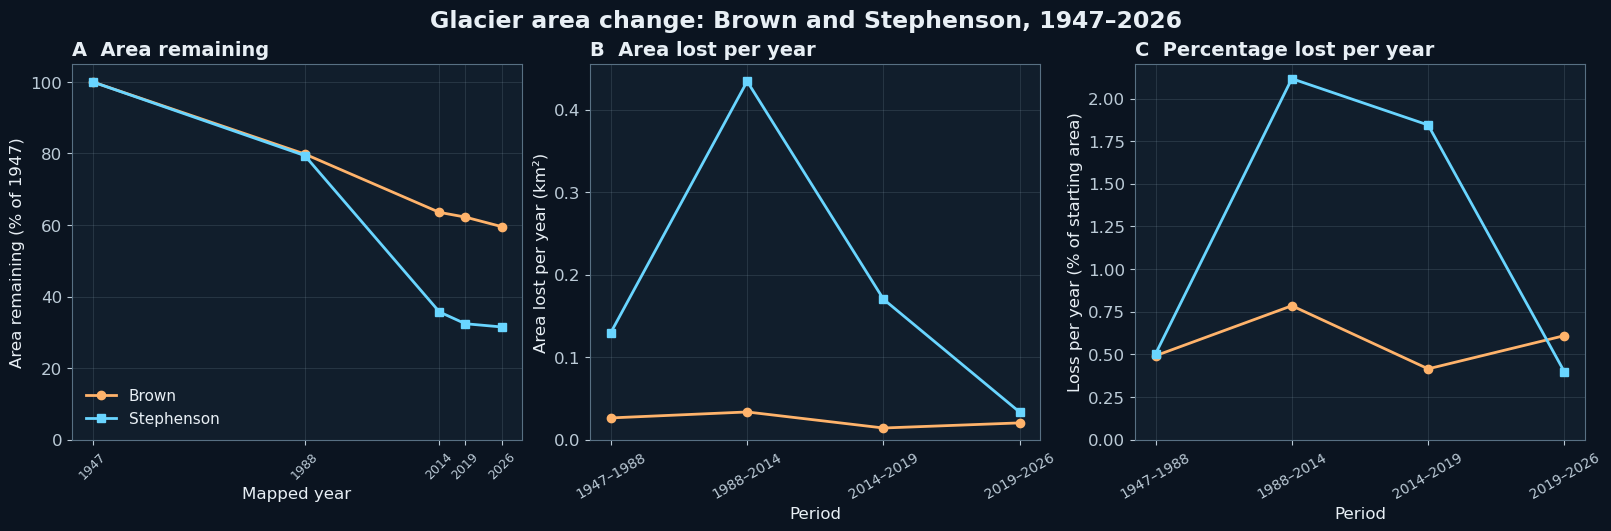

In [3]:
## Compare total loss and annualised retreat ##

area = history.pivot(
    index = "year", columns = "name_1", values = "area_km2").loc[years, names]

remaining = 100 * area.div(area.loc[1947])
retreat = retreat.sort_values(["start_year", "name_1"])

retreat["annual_loss_pct_1947_area"] = [
    100 * row.annual_loss_km2 / area.loc[1947, row.name_1]
    for row in retreat.itertuples()]

periods = retreat.drop_duplicates("start_year").period.tolist()
markers = {"Brown": "o", "Stephenson": "s"}

fig, axes = plt.subplots(
    1, 3, figsize = (16, 5.2), layout = "constrained")
fig.suptitle("Glacier area change: Brown and Stephenson, 1947–2026",
    fontsize = 17, fontweight = "semibold")

for name in names:
    axes[0].plot(years, remaining[name], marker = markers[name],
        color = colours[name], linewidth = 2, label = name)

    part = retreat.loc[retreat.name_1.eq(name)]
    axes[1].plot(part.period, part.annual_loss_km2,
        marker = markers[name], color = colours[name], linewidth = 2)
    axes[2].plot(part.period, part.annual_loss_percent,
        marker = markers[name], color = colours[name], linewidth = 2)

axes[0].set_title("A  Area remaining", loc = "left")
axes[0].set(ylabel = "Area remaining (% of 1947)",
    xlabel = "Mapped year", ylim = (0, 105))
axes[0].set_xticks(years)
axes[0].tick_params(axis = "x", rotation = 45, labelsize = 9)
axes[0].legend(loc = "lower left", fontsize = 11)

axes[1].set_title("B  Area lost per year", loc = "left")
axes[1].set(ylabel = "Area lost per year (km²)", xlabel = "Period")
axes[2].set_title("C  Percentage lost per year", loc = "left")
axes[2].set(ylabel = "Loss per year (% of starting area)", xlabel = "Period")

for ax in axes:
    ax.grid(alpha = 0.15)
for ax in axes[1:]:
    ax.set_ylim(bottom = 0)
    ax.tick_params(axis = "x", rotation = 30, labelsize = 10)

save_figure(fig, "01_retreat_timing")
retreat.to_csv(synthesis_dir / "retreat_comparison.csv", index = False)

Figure. Changes in mapped glacier area at Brown and Stephenson between 1947 and 2026. A: the percentage of each glacier’s 1947 area remaining at each mapped date. B: the average area lost per year between consecutive outlines, in square kilometres. C: the average percentage lost per year, calculated relative to the glacier’s area at the start of each period. Annualising the losses allows periods of different lengths to be compared. Points represent mapped dates or averages between dates; connecting lines do not represent separately observed annual changes.

### Results and interpretation

#### Stephenson has lost substantially more area overall

Between 1947 and 2026, Brown lost **40.44%** of its mapped area, compared with **68.49%** at Stephenson. Approximately 60% of Brown’s original area therefore remains, compared with 32% of Stephenson’s.

Both glaciers lost about 20% of their original area during 1947–1988. Their histories diverged more strongly after 1988, when Stephenson underwent much greater contraction.

#### The timing of area loss differs between the glaciers

Both glaciers had their greatest average annual area-loss rate during **1988–2014**. Stephenson lost approximately **0.434 km² per year**, compared with **0.034 km² per year** at Brown.

Brown’s largest total loss within a single interval occurred during 1947–1988. However, that interval lasted 41 years, compared with 26 years for 1988–2014. A larger total loss over a longer period does not necessarily mean a higher annual loss rate.

The recent pattern differs from the long-term contrast. Brown’s average proportional loss increased from **0.42% per year during 2014–2019** to **0.61% per year during 2019–2026**. Stephenson’s decreased from **1.84% to 0.40% per year**.

Brown therefore lost a greater percentage of its starting area during the most recent period. Stephenson still lost more square kilometres each year: approximately **0.033 km²**, compared with **0.020 km²** at Brown. These statements describe different aspects of the same change.

A separate calculation using each glacier’s 1947 area also gives Brown the higher recent proportional rate. The crossover is therefore not solely a consequence of changing the starting-area baseline between periods.

#### What the comparison tells us

Stephenson’s greater cumulative contraction is consistent with the broad historical contrast reported by Tielidze et al. (2025), who documented exceptionally large retreat at Stephenson. Their inventory dates and outline methods differ from those used here, so this agreement concerns the overall pattern rather than exact numerical agreement.

This figure measures changes in the area covered by ice. Glacier thinning, volume loss and movement of the glacier front require additional measurements. For example, Thost and Truffer (2008) combined field surface surveys and ground-penetrating radar to estimate Brown’s surface lowering and volume loss. A decrease in area-loss rate alone therefore does not establish that thinning or front retreat has also slowed.

The recent differences remain subject to the outline constraints and mapping uncertainty described in the methods.

### References for this section

Thost, D. E., and Truffer, M. (2008). Glacier recession on Heard Island, southern Indian Ocean. *Arctic, Antarctic, and Alpine Research*, **40**(1), 199–214. [https://doi.org/10.1657/1523-0430(06-084)[THOST]2.0.CO;2](https://www.tandfonline.com/doi/full/10.1657/1523-0430%2806-084%29%5BTHOST%5D2.0.CO%3B2?)

Tielidze, L. G., Mackintosh, A. N., and Yang, W. (2025). Glacier inventories reveal an acceleration of Heard Island glacier loss over recent decades. *The Cryosphere*, **19**, 2677–2694. [https://doi.org/10.5194/tc-19-2677-2025](https://doi.org/10.5194/tc-19-2677-2025)

## 3. Locate retreat within the mapped geological setting

Construct the area lost between consecutive inventories and intersect it with the geology map. Gross spatial loss and mapped gain are recorded separately; their difference gives net area loss.

Retain the source map’s classes. Moraine and other deposits describe mapped surface materials, while Snow/Ice does not identify underlying lithology. Unmapped area remains explicit. The overlay describes where retreat occurred relative to the geological map, not the material exposed at each historical date.

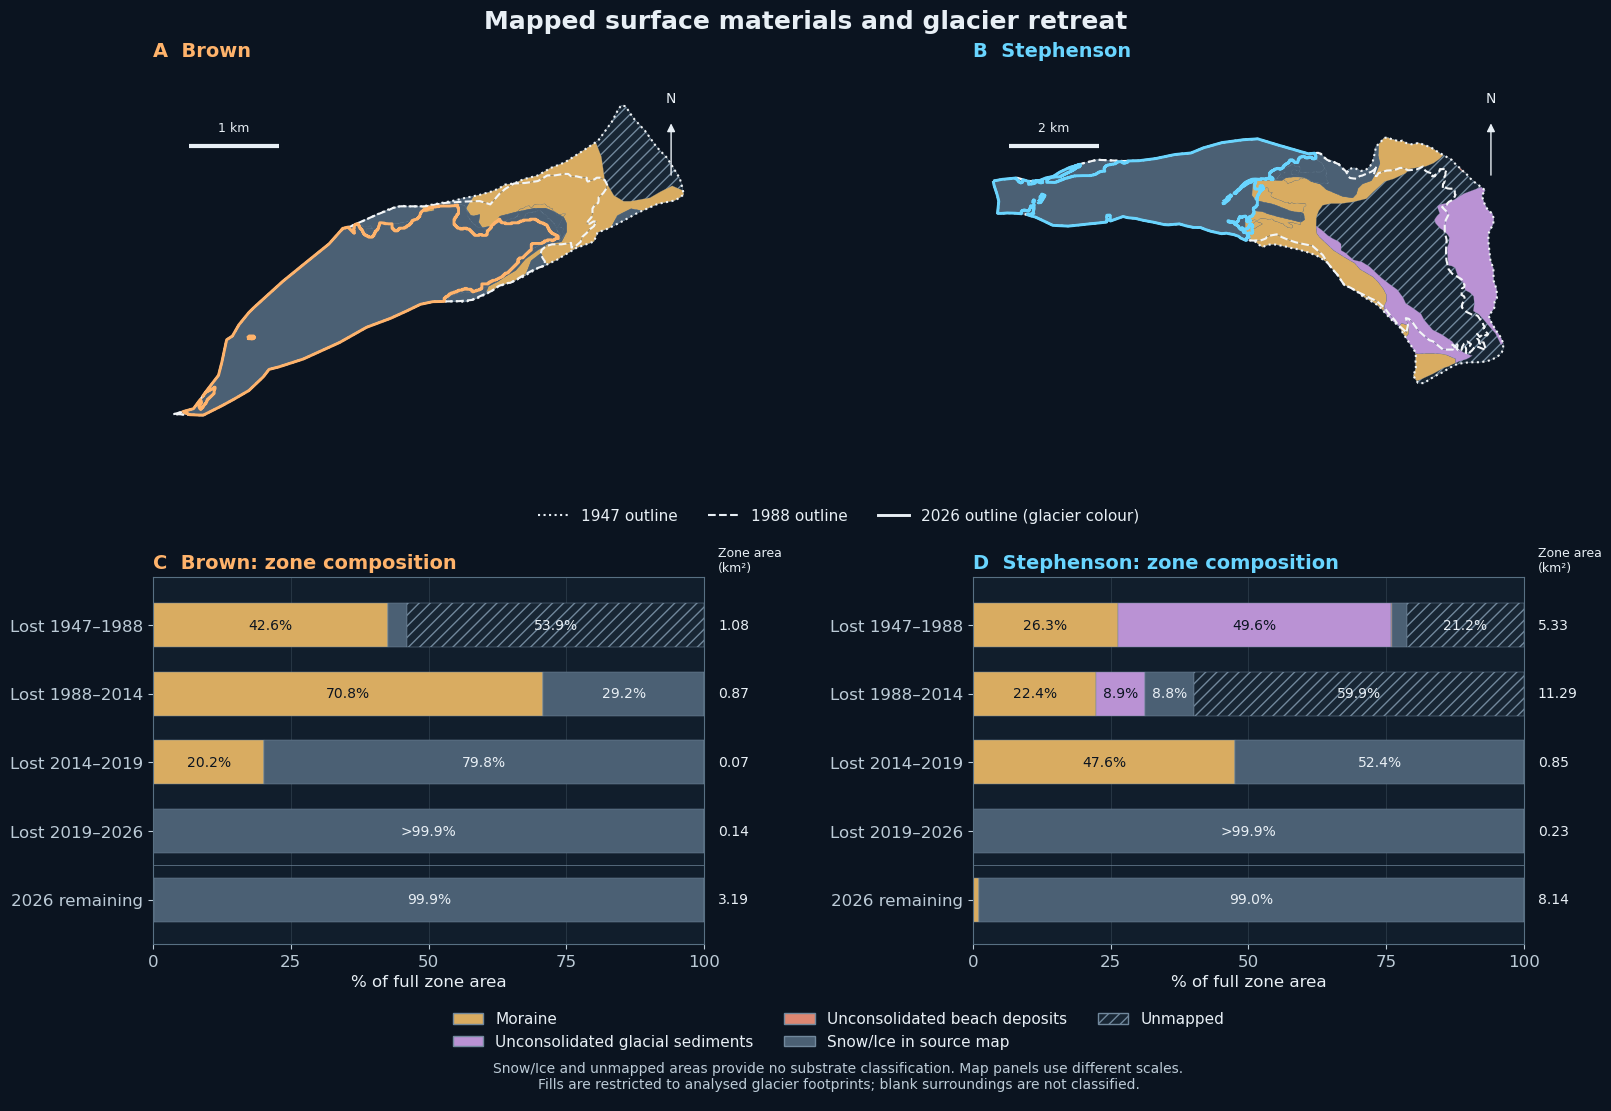

In [4]:
## Intersect mapped geology with retreat zones ##

def get_outline(name, year):
    """Return one accepted glacier outline in the project CRS."""
    return extents.loc[
        extents.name_1.eq(name) & extents.year.eq(year), "geometry"].iloc[0]


zone_rows = []
change_rows = []

for name in names:
    for start, end in zip(years[:-1], years[1:]):
        before = get_outline(name, start)
        after = get_outline(name, end)
        lost = before.difference(after)
        gained = after.difference(before)
        period = f"{start}–{end}"

        zone_rows.append(dict(
            name_1 = name, zone = period, geometry = lost))

        change_rows.append(dict(
            name_1 = name, period = period,
            gross_loss_km2 = lost.area / 1e6,
            mapped_gain_km2 = gained.area / 1e6,
            net_loss_km2 = (before.area - after.area) / 1e6))

    zone_rows.append(dict(name_1 = name, zone = "2026 remaining",
        geometry = get_outline(name, 2026)))

zones = gpd.GeoDataFrame(zone_rows, crs = extents.crs)
changes = pd.DataFrame(change_rows)

changes.to_csv(synthesis_dir / "spatial_area_changes.csv", index = False)
zones.to_file(synthesis_dir / "retreat_zones.gpkg",
    layer = "zones", driver = "GPKG")

geology = gpd.read_file(
    project_dir / "Output_Data/geology_clipped.shp").to_crs(extents.crs)
geology = geology.loc[
    geology.geometry.notna() & ~geology.geometry.is_empty].copy()
geology.geometry = geology.geometry.make_valid()
geology["Rock_Type"] = geology.Rock_Type.fillna("Unknown")

hits = gpd.overlay(zones, geology[["Rock_Type", "geometry"]],
    how = "intersection", keep_geom_type = True)
hits["area_km2"] = hits.area / 1e6

geology_rows = []

for zone in zones.itertuples():
    part = hits.loc[
        hits.name_1.eq(zone.name_1) & hits.zone.eq(zone.zone)]
    covered = unary_union(part.geometry.tolist()).area / 1e6
    overlap = part.area_km2.sum() - covered

    # Stop overlapping source classes from silently inflating percentages.
    if overlap > 0.000001:
        raise ValueError(
            f"Overlapping geology classes in {zone.name_1}, "
            f"{zone.zone}: {overlap:.6f} km²")

    amounts = part.groupby("Rock_Type").area_km2.sum().to_dict()
    zone_area = zone.geometry.area / 1e6
    amounts["Unmapped"] = max(0, zone_area - covered)

    for rock, amount in amounts.items():
        geology_rows.append(dict(
            name_1 = zone.name_1, zone = zone.zone, Rock_Type = rock,
            area_km2 = amount, zone_percent = 100 * amount / zone_area))

geology_summary = pd.DataFrame(geology_rows)
geology_summary.to_csv(
    synthesis_dir / "geology_by_retreat_zone.csv", index = False)

class_labels = {
    "Moraine": "Moraine",
    "Uncosolidated Glacial Sediments": "Unconsolidated glacial sediments",
    "Uncosolidated Beach Deposit": "Unconsolidated beach deposits",
    "Snow/Ice": "Snow/Ice in source map",
    "Unknown": "Unknown source class",
    "Unmapped": "Unmapped"}

class_styles = {
    "Moraine": ("#D9AC61", ""),
    "Uncosolidated Glacial Sediments": ("#BA92D4", ""),
    "Uncosolidated Beach Deposit": ("#DD8772", ""),
    "Snow/Ice": ("#4B6074", ""),
    "Unknown": ("#87939C", "xx"),
    "Unmapped": ("#182634", "///")}

class_order = [rock for rock in class_labels
    if rock in geology_summary.Rock_Type.unique()]
class_order += sorted(set(geology_summary.Rock_Type) - set(class_order))
zone_order = periods + ["2026 remaining"]
outline_styles = {1947: (":", 1.5), 1988: ("--", 1.5), 2026: ("-", 2.1)}

fig = plt.figure(figsize = (16, 11), layout = "constrained")
grid = fig.add_gridspec(4, 2, height_ratios = [1.1, 0.12, 1, 0.28])
fig.suptitle("Mapped surface materials and glacier retreat",
    fontsize = 18, fontweight = "semibold")

for column, name in enumerate(names):
    map_ax = fig.add_subplot(grid[0, column])
    bar_ax = fig.add_subplot(grid[2, column])
    part = hits.loc[hits.name_1.eq(name)]
    footprint = unary_union(zones.loc[zones.name_1.eq(name)].geometry)

    # Hatch uncovered areas within the analysed glacier footprints.
    gpd.GeoSeries([footprint], crs = extents.crs).plot(ax = map_ax,
        color = class_styles["Unmapped"][0], edgecolor = "#71889C",
        hatch = "///", linewidth = 0.3)

    for rock in class_order:
        mapped = part.loc[part.Rock_Type.eq(rock)]
        if mapped.empty:
            continue
        colour, hatch = class_styles.get(rock, ("#87939C", ""))
        mapped.plot(ax = map_ax, color = colour, edgecolor = "#71889C",
            hatch = hatch, linewidth = 0.15)

    for year, (linestyle, linewidth) in outline_styles.items():
        outline_colour = colours[name] if year == 2026 else "#F2F5F7"
        gpd.GeoSeries([get_outline(name, year)], crs = extents.crs).boundary.plot(
            ax = map_ax, color = outline_colour, linestyle = linestyle,
            linewidth = linewidth, zorder = 5)

    xmin, ymin, xmax, ymax = footprint.bounds
    padding = 0.04 * max(xmax - xmin, ymax - ymin)
    map_width = xmax - xmin + 2 * padding
    map_height = max(ymax - ymin + 2 * padding, 0.65 * map_width)
    middle_y = (ymin + ymax) / 2

    map_ax.set_xlim(xmin - padding, xmax + padding)
    map_ax.set_ylim(middle_y - map_height / 2, middle_y + map_height / 2)
    map_ax.set_aspect("equal")
    map_ax.set_anchor("N")
    map_ax.set_axis_off()
    map_ax.set_title(f"{'AB'[column]}  {name}", loc = "left",
        color = colours[name])

    map_ax.annotate("", xy = (0.94, 0.89), xytext = (0.94, 0.73),
        xycoords = "axes fraction", textcoords = "axes fraction",
        arrowprops = dict(arrowstyle = "-|>", color = "#E8EFF5"))
    map_ax.text(0.94, 0.94, "N", transform = map_ax.transAxes,
        ha = "center", fontsize = 10)

    scale_m = 1000 if name == "Brown" else 2000
    scale_x = xmin + 0.03 * (xmax - xmin)
    scale_y = middle_y + map_height / 2 - 0.18 * map_height
    map_ax.plot([scale_x, scale_x + scale_m], [scale_y, scale_y],
        color = "#E8EFF5", linewidth = 3, solid_capstyle = "butt")
    map_ax.text(scale_x + scale_m / 2, scale_y + 0.04 * map_height,
        f"{scale_m / 1000:g} km", ha = "center", fontsize = 9)

    values = geology_summary.loc[geology_summary.name_1.eq(name)]
    table = values.pivot(index = "zone", columns = "Rock_Type",
        values = "zone_percent").reindex(index = zone_order,
        columns = class_order).fillna(0)
    zone_areas = values.groupby("zone").area_km2.sum().reindex(zone_order)
    positions = np.arange(len(zone_order))
    left = np.zeros(len(zone_order))

    for rock in class_order:
        widths = table[rock].to_numpy()
        colour, hatch = class_styles.get(rock, ("#87939C", ""))
        bar_ax.barh(positions, widths, left = left, height = 0.64,
            color = colour, edgecolor = "#71889C", hatch = hatch,
            linewidth = 0.35)

        text_colour = "#E8EFF5" if rock in ["Snow/Ice", "Unmapped"] else "#0B1420"
        for row, value in enumerate(widths):
            if value >= 8:
                label = ">99.9%" if value > 99.9 else f"{value:.1f}%"
                bar_ax.text(left[row] + value / 2, row, label,
                    ha = "center", va = "center", color = text_colour,
                    fontsize = 10)
        left += widths

    for row, amount in enumerate(zone_areas):
        bar_ax.text(1.025, row, f"{amount:.2f}",
            transform = bar_ax.get_yaxis_transform(), va = "center",
            fontsize = 10, clip_on = False)

    bar_ax.text(1.025, 1.015, "Zone area\n(km²)",
        transform = bar_ax.transAxes, ha = "left", fontsize = 9)
    bar_ax.set_yticks(positions, [f"Lost {p}" for p in periods]
        + ["2026 remaining"])
    bar_ax.set(xlim = (0, 100), ylim = (4.65, -0.7),
        xlabel = "% of full zone area", ylabel = "")
    bar_ax.set_xticks([0, 25, 50, 75, 100])
    bar_ax.axhline(3.5, color = "#71889C", linewidth = 0.7, alpha = 0.7)
    bar_ax.grid(axis = "x")
    bar_ax.set_axisbelow(True)
    bar_ax.set_title(f"{'CD'[column]}  {name}: zone composition",
        loc = "left", color = colours[name])

outline_ax = fig.add_subplot(grid[1, :])
outline_ax.set_axis_off()
outline_handles = [Line2D([0], [0], color = "#E8EFF5",
    linestyle = style[0], linewidth = style[1],
    label = f"{year} outline" if year != 2026 else "2026 outline (glacier colour)")
    for year, style in outline_styles.items()]
outline_ax.legend(handles = outline_handles, loc = "center", ncol = 3)

legend_ax = fig.add_subplot(grid[3, :])
legend_ax.set_axis_off()
material_handles = [Patch(facecolor = class_styles.get(rock, ("#87939C", ""))[0],
    edgecolor = "#71889C", hatch = class_styles.get(rock, ("#87939C", ""))[1],
    label = class_labels.get(rock, rock)) for rock in class_order]
legend_ax.legend(handles = material_handles, loc = "upper center", ncol = 3)
legend_ax.text(0.5, 0.12,
    "Snow/Ice and unmapped areas provide no substrate classification. "
    "Map panels use different scales.\n"
    "Fills are restricted to analysed glacier footprints; blank surroundings are not classified.",
    transform = legend_ax.transAxes, ha = "center", fontsize = 10,
    color = "#BCCBD7")

save_figure(fig, "02_geology_by_retreat_zone")

Figure. Mapped surface materials within the analysed Brown and Stephenson glacier footprints. Panels A–B show source-map classes with selected glacier outlines; panels C–D show their proportions within each retreat zone and the 2026 remaining footprint. Percentages use the full zone area, including Snow/Ice and unmapped locations. Areas beside the bars represent gross spatial loss for each interval, or remaining area for 2026. Map panels use different scales. The fills describe the geological source map, not reconstructed surface conditions at each inventory date.

## Results and interpretation

### Deposits within the retreat zones

Both glacier forelands contain mapped glacial deposits, but their composition and mapping coverage differ. In the 1947–1988 retreat zone, moraine occupies 42.6% of Brown’s lost area, while 53.9% is unmapped. Stephenson’s corresponding zone contains 26.3% moraine and 49.6% unconsolidated glacial sediments, with 21.2% unmapped.

Moraine dominates the mapped composition of Brown’s 1988–2014 retreat zone, occupying 70.8% of its full area. Stephenson’s equivalent zone contains 22.4% moraine and 8.9% unconsolidated glacial sediments, but 59.9% is unmapped. These proportions also describe very different amounts of retreat: the zones cover approximately 0.87 km² and 11.29 km², respectively. Despite its smaller moraine proportion, Stephenson’s zone contains approximately 2.53 km² of mapped moraine, compared with 0.62 km² at Brown.

### Surface mapping and substrate uncertainty

More than 99.9% of both glaciers’ 2019–2026 retreat zones is classified as Snow/Ice in the geological source map. This records the source map’s representation of those locations rather than the material exposed after retreat. Snow/Ice therefore provides no classification of underlying sediment or bedrock. Unmapped locations likewise cannot automatically be assigned to lagoon, sediment or a particular lithology.

Moraine describes a glacial depositional landform and its associated material. Its presence records glacial sediment deposition, but does not establish the material beneath the former glacier or the lagoon floor. Mapped deposits may also be a product of earlier glacier activity, so their association with retreat cannot independently establish a causal geological control.

### Sediment behaviour and lagoon-basin interpretation

A sediment substrate provides a physically plausible mechanism for deformation and redistribution beneath ice. Field experiments show that subglacial till can deform, with its behaviour linked to stress and effective pressure (Boulton and Hindmarsh, 1987). However, the foreland map does not establish the thickness, strength, consolidation or water-pressure conditions of any sediment beneath these glaciers. It therefore cannot demonstrate that one glacier occupied a more readily deformable bed.

Basin excavation and water retention are also distinct processes. Glacial erosion can create depressions in bedrock or sediment, while a terminal or lateral moraine can retain water after retreat exposes a basin (Rick et al., 2022). The presence of mapped moraine does not establish that it excavated the depression, formed a continuous retaining barrier or subsequently failed.

Brown’s surveyed lagoon depression and its overlap with historical ice are consistent with retreat exposing a glacial basin. The bathymetry establishes the supported basin geometry, but does not identify whether excavation occurred predominantly in bedrock or sediment, or whether a moraine controls the present outlet.

The geological contribution is therefore evidence of contrasting mapped deposits and foreland settings. Sediment deformation, erosion and moraine influence on drainage remain plausible mechanisms for further investigation. The present overlay does not establish contrasting substrate erodibility as the explanation for Brown and Stephenson’s retreat differences.

### References cited in this section

Boulton, G. S., and Hindmarsh, R. C. A. (1987). Sediment deformation beneath glaciers: Rheology and geological consequences. Journal of Geophysical Research: Solid Earth, 92(B9), 9059–9082. https://doi.org/10.1029/JB092iB09p09059

Rick, B., McGrath, D., Armstrong, W., and McCoy, S. W. (2022). Dam type and lake location characterize ice-marginal lake area change in Alaska and NW Canada between 1984 and 2019. The Cryosphere, 16, 297–314. https://doi.org/10.5194/tc-16-297-2022

## 4. Track glacier footprint area below 300, 600 and 900 m

This comparison asks how much of each glacier’s mapped footprint occupies low-elevation locations, and how that area changes as the glacier retreats.

For each dated outline, count the area with valid elevations below 300, 600 and 900 m using the 2002 RADARSAT elevation map. The same elevation map is used for every outline, so the comparison tracks changes in the locations occupied by ice. It does not reconstruct glacier surface heights in each historical year.

Each panel shows glacier footprint area below one elevation cut-off. A falling line means that less of the mapped glacier occupies locations below that elevation. The thresholds are cumulative: the area below 300 m is included in the areas below 600 and 900 m.

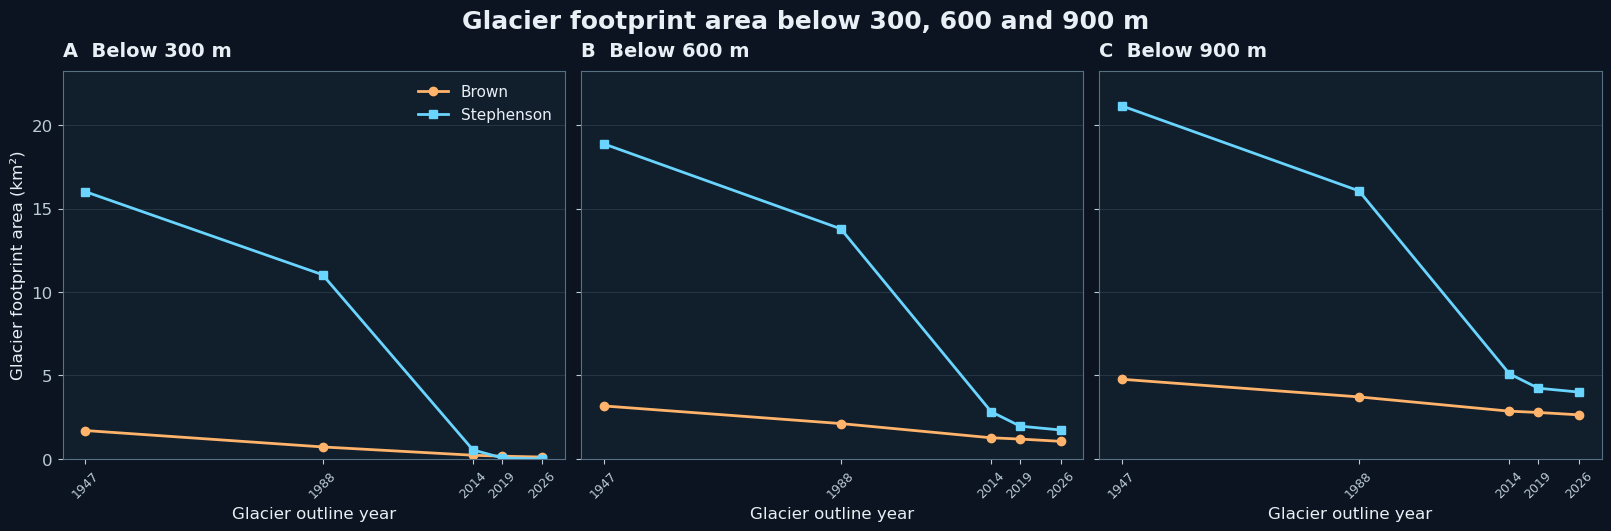

In [5]:
## Compare low-elevation area using one fixed reference surface ##


reference_path = (
    processed_dir / "geomorphology/Heard_surface_DEM_2002_50m.tif")

thresholds = [300, 600, 900]
low_rows = []

if reference_path.exists():
    with rasterio.open(reference_path) as src:
        pixel_km2 = abs(
            src.transform.a * src.transform.e
            - src.transform.b * src.transform.d) / 1e6

        for row in extents.to_crs(src.crs).itertuples():
            data, _ = mask(src, [row.geometry],
                crop = True, filled = False, indexes = 1)

            values = data.compressed()
            values = values[np.isfinite(values)]
            supported_area = len(values) * pixel_km2

            for threshold in thresholds:
                low_area = (
                    np.count_nonzero(values < threshold) * pixel_km2
                    if len(values) else np.nan)

                low_rows.append(dict(
                    name_1 = row.name_1,
                    year = row.year,
                    threshold_m = threshold,
                    below_threshold_km2 = low_area,
                    below_threshold_pct_supported = (
                        100 * low_area / supported_area
                        if supported_area else np.nan),
                    dem_supported_km2 = supported_area,
                    dem_area_coverage_percent = (
                        100 * supported_area / row.geometry.area * 1e6)))

    low_area_history = pd.DataFrame(low_rows)
    low_area_history.to_csv(
        synthesis_dir / "fixed_surface_low_elevation_area.csv",
        index = False)

    fig, axes = plt.subplots(
        1, 3, figsize = (16, 5.2), sharey = True, layout = "constrained")

    fig.suptitle(
        "Glacier footprint area below 300, 600 and 900 m",
        fontsize = 18, fontweight = "semibold")

    markers = {"Brown": "o", "Stephenson": "s"}
    area_max = low_area_history.below_threshold_km2.max()

    for ax, threshold, letter in zip(axes, thresholds, "ABC"):
        for name in names:
            part = low_area_history.loc[
                low_area_history.name_1.eq(name)
                & low_area_history.threshold_m.eq(threshold)
            ].sort_values("year")

            ax.plot(
                part.year, part.below_threshold_km2,
                color = colours[name], marker = markers[name],
                linewidth = 2, markersize = 6, label = name)

        ax.set_title(f"{letter}  Below {threshold} m", loc = "left", pad = 10)
        ax.set_xlabel("Glacier outline year")
        ax.set_xticks(years)
        ax.tick_params(axis = "x", labelrotation = 45, labelsize = 9)
        ax.set_ylim(0, area_max * 1.10)
        ax.grid(axis = "y", alpha = 0.15)

    axes[0].set_ylabel("Glacier footprint area (km²)")
    axes[0].legend(loc = "upper right", fontsize = 11)
    save_figure(fig, "03_low_elevation_area")

else:
    low_area_history = pd.DataFrame()
    print(f"Run this cell locally with the existing raster: {reference_path}")

**Figure. Changes in glacier footprint area below three elevation cut-offs, 1947–2026.** Panels show the area inside each dated glacier outline at locations below **(A)** 300 m, **(B)** 600 m and **(C)** 900 m. Elevations come from the 2002 RADARSAT DEM for every outline, and only cells with valid elevations are counted. The thresholds overlap: area below 300 m is also included below 600 and 900 m. All panels use the same vertical scale. Points represent mapped dates; connecting lines guide the eye between observations.

### Results and interpretation

#### Stephenson lost a much larger low-elevation footprint

The strongest contrast occurs below 300 m. Stephenson’s mapped area below this cut-off decreased from **16.01 km² in 1947** to **11.04 km² in 1988** and **0.54 km² in 2014**. No cells below 300 m were counted within its 2026 outline.

Brown’s corresponding area decreased from **1.70 km² in 1947** to **0.72 km² in 1988**, **0.22 km² in 2014** and **0.11 km² in 2026**. Both glaciers therefore lost most of their earlier footprint at the lowest elevations, but Stephenson’s initial footprint was far more extensive.

This pattern is consistent with Tielidze et al. (2025), who describe Stephenson’s historical glacier tongue as long, gently sloping and largely situated near sea level.

#### Contraction continued above the lowest elevation cut-off

The 600 and 900 m panels show that footprint contraction extended beyond the locations below 300 m. By 2026, Stephenson retained **1.73 km² below 600 m** and **4.00 km² below 900 m**, compared with **1.05 km²** and **2.64 km²**, respectively, at Brown.

Although Stephenson retained more area below 600 m in absolute terms, this represented only **21.4%** of its footprint with valid elevation data, compared with **33.0%** at Brown. Stephenson’s much larger former low-elevation tongue had already been largely removed.

That loss provides a plausible contribution to its lower recent rate of area loss: the remaining glacier has a different shape and elevation distribution from its earlier footprint. A lower area-loss rate does not, by itself, demonstrate slower terminus retreat or reduced thinning.

#### What this comparison establishes

Glacier area distributed across different elevations can influence the response to climate forcing, as demonstrated by McGrath et al. (2017). Here, however, the three cut-offs describe where mapped ice footprints have contracted. They are not measured boundaries between snow accumulation and melting.

Because all elevations come from the 2002 DEM, these results do not measure historical surface lowering or the current height of the remaining ice. Valid elevation data cover approximately 99–100% of each outline; minor differences around 100% reflect counting whole raster cells along polygon boundaries. Recent retention of ice above 1,000 m is also partly imposed by the outline method and cannot be interpreted as independently observed stability.

### References for this section

McGrath, D., Sass, L., O’Neel, S., Arendt, A. A., & Kienholz, C. (2017). Hypsometric control on glacier mass balance sensitivity in Alaska and northwest Canada. *Earth’s Future, 5*(3), 324–336. https://doi.org/10.1002/2016EF000479

Tielidze, L. G., Mackintosh, A. N., & Yang, W. (2025). Glacier inventories reveal an acceleration of Heard Island glacier loss over recent decades. *The Cryosphere, 19*, 2677–2694. https://doi.org/10.5194/tc-19-2677-2025

## 5. Investigate geomorphological influences on retreat and flow

This section compares glacier geometry, flow and surface exposure to investigate possible explanations for the contrasting behaviour of Brown and Stephenson.

Two fixed analysis transects connect the former coastal tongues with the surviving inland glaciers. Brown’s route passes through its surveyed lagoon and continues inland. Stephenson’s route curves from its former southern tongue towards the surviving northern tongue. Distances increase inland from zero at the seaward end of each route.

The following profiles compare surface elevation, modelled bed elevation, ice speed and glacier width at positions along these routes. They are analysis transects chosen for these comparisons, rather than reconstructed historical flowlines.

The modelled bed estimates the terrain beneath the ice by subtracting modelled ice thickness from the 2002 DEM elevations. Because these inputs represent different dates and thickness is modelled, apparent bed features are treated as possibilities to investigate rather than confirmed subglacial landforms.

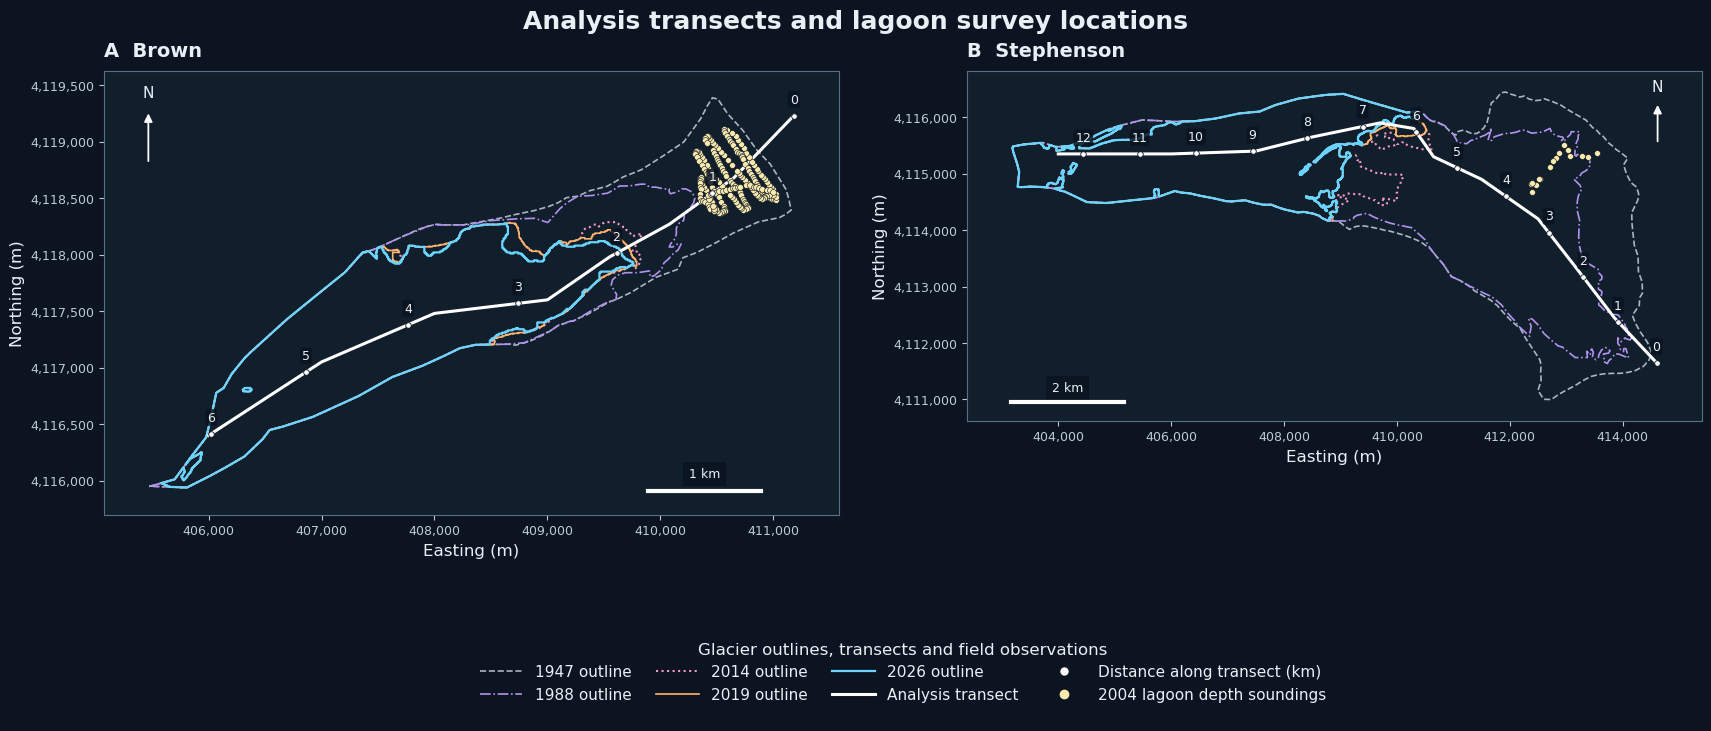

In [6]:
## Set up the geomorphological transects ##

terrain_full = terrain.loc[terrain.support.eq('2014 footprint')].copy()
geom_dir = processed_dir / 'geomorphology'
map_dir = processed_dir / 'interactive_map_data'
soundings = gpd.read_file(map_dir / 'lagoon_soundings_2004.geojson').to_crs(extents.crs)
velocity_layers = json.loads((map_dir / 'velocity_layers.json').read_text())['glaciers']
field_metadata = json.loads((field_dir / 'field_reconstruction_metadata.json').read_text())

settings = dict(step_m = 50, offsets_m = [-100, -50, 0, 50, 100],
    crest_prominence_m = 10, crest_spacing_m = 300, crest_match_m = 150,
    perturbation_wavelength_m = 1000, assumed_water_level_m = 0.0)

raster_paths = dict(surface = geom_dir / 'Heard_surface_DEM_2002_50m.tif',
    bed = geom_dir / 'Heard_bed_estimate_candidate_50m.tif',
    error = geom_dir / 'Heard_Millan_thickness_error_land_50m.tif')
bathy_path = field_dir / 'Brown_lagoon_2004_depth.tif'

# EPSG:32743 coordinates, ordered from seaward to inland.
transect_vertices = {
    'Brown': [(411180, 4119230), (410650, 4118680), (410080, 4118270),
        (409550, 4117980), (409000, 4117600), (408000, 4117480),
        (407000, 4117050), (406000, 4116400)],
    'Stephenson': [(414600, 4111650), (413850, 4112450), (413200, 4113300),
        (412500, 4114200), (411500, 4114900), (410650, 4115300),
        (410300, 4115800), (409700, 4115900), (408500, 4115650),
        (407500, 4115400), (406000, 4115350), (404000, 4115350)]}
transects = {name: LineString(xy) for name, xy in transect_vertices.items()}


def project_path(value):
    """Resolve a saved project-relative path on Windows or Linux."""
    return project_dir / value.replace('\\', '/')


def line_parts(geometry):
    """Extract non-empty line components from an intersection."""
    if geometry.is_empty:
        return []
    if geometry.geom_type == 'LineString':
        return [geometry]
    return [part for child in getattr(geometry, 'geoms', []) for part in line_parts(child)]


def transect_xy(line, distances, offsets):
    """Return coordinates at signed offsets normal to a seaward-to-inland line."""
    distances = np.asarray(distances)
    centre = np.array([line.interpolate(float(s)).coords[0] for s in distances])
    before = np.array([line.interpolate(max(0, float(s) - 25)).coords[0] for s in distances])
    after = np.array([line.interpolate(min(line.length, float(s) + 25)).coords[0] for s in distances])
    tangent = after - before
    tangent /= np.linalg.norm(tangent, axis = 1)[:, None]
    normal = np.column_stack([-tangent[:, 1], tangent[:, 0]])
    return centre[:, None, :] + normal[:, None, :] * np.asarray(offsets)[None, :, None]


def sample_raster(path, xy, polygon = None):
    """Sample native cells; return values and cell IDs without filling NoData."""
    shape = xy.shape[:-1]
    coordinates = xy.reshape(-1, 2)
    with rasterio.open(path) as src:
        if src.crs != extents.crs:
            raise ValueError(f'Unexpected CRS: {path}')
        values = np.ma.vstack(list(src.sample(coordinates, indexes = 1, masked = True)))
        values = values.astype(float).filled(np.nan).ravel()
        rr, cc = rasterio.transform.rowcol(src.transform, *coordinates.T)
        ids = np.asarray(rr, dtype = np.int64) * src.width + np.asarray(cc)
    if polygon is not None:
        values[[not polygon.covers(Point(p)) for p in coordinates]] = np.nan
    values[~np.isfinite(values)] = np.nan
    return values.reshape(shape), ids.reshape(shape)


def swath_median(values, ids, require_centre = True):
    """Summarise unique native cells at each station, retaining centreline gaps."""
    medians, counts = [], []
    for row, cells in zip(values, ids):
        valid = np.isfinite(row)
        unique = np.unique(cells[valid], return_index = True)[1]
        samples = row[valid][unique]
        supported = len(samples) and (not require_centre or np.isfinite(row[len(row) // 2]))
        medians.append(float(np.median(samples)) if supported else np.nan)
        counts.append(len(samples))
    return np.asarray(medians), np.asarray(counts)


def smooth_profile(values, window = 3):
    """Use a full-window median so smoothing cannot bridge missing stations."""
    return pd.Series(values).rolling(window, center = True, min_periods = window).median().to_numpy()


def crest_indices(values):
    """Screen local highs within continuous support; thresholds are descriptive."""
    valid = np.flatnonzero(np.isfinite(values))
    blocks = np.split(valid, np.flatnonzero(np.diff(valid) > 1) + 1)
    peaks = []
    for block in blocks:
        if len(block) >= 5:
            found, _ = find_peaks(values[block], prominence = settings['crest_prominence_m'],
                distance = max(1, int(settings['crest_spacing_m'] / settings['step_m'])))
            peaks.extend(block[found])
    return np.asarray(peaks, dtype = int)


required = list(raster_paths.values()) + [bathy_path]
for name in names:
    rgi = velocity.loc[velocity.name_1.eq(name), 'RGIId'].iloc[0]
    required.append(project_path(velocity_layers[rgi]['layers']['median_speed']))
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError('Missing local outputs:\n' + '\n'.join(missing))

gpd.GeoDataFrame({'name_1': names, 'direction': ['seaward to inland'] * 2,
    'geometry': [transects[name] for name in names]}, crs = extents.crs).to_file(
    synthesis_dir / 'geomorphology_transects.gpkg', layer = 'transects', driver = 'GPKG')

fig = plt.figure(figsize = (17, 7.2), layout = 'constrained')
grid = fig.add_gridspec(2, 2, height_ratios = [1, 0.18])
axes = [fig.add_subplot(grid[0, j]) for j in range(2)]
legend_ax = fig.add_subplot(grid[1, :])
legend_ax.axis('off')

fig.suptitle('Analysis transects and lagoon survey locations',
    fontsize = 18, fontweight = 'semibold')

outline_styles = {
    1947: dict(color = '#AAB4C3', linestyle = '--', linewidth = 1.2),
    1988: dict(color = '#B292EE', linestyle = '-.', linewidth = 1.2),
    2014: dict(color = '#F49AC2', linestyle = ':', linewidth = 1.5),
    2019: dict(color = '#FFB36B', linestyle = '-', linewidth = 1.2),
    2026: dict(color = '#69D5FF', linestyle = '-', linewidth = 1.6)}

for ax, name, letter in zip(axes, names, 'AB'):
    for year in years:
        part = extents.loc[extents.name_1.eq(name) & extents.year.eq(year)]
        part.boundary.plot(ax = ax, **outline_styles[year], zorder = 2)

    line = transects[name]
    ax.plot(*line.xy, color = 'white', linewidth = 2.2, zorder = 4)

    points = soundings.loc[soundings.name_1.eq(name)]
    points.plot(ax = ax, color = '#F8E9AE', markersize = 18,
        edgecolor = '#0B1420', linewidth = 0.4, zorder = 5)

    for distance in np.arange(0, line.length, 1000):
        point = line.interpolate(distance)
        ax.plot(point.x, point.y, 'o', color = 'white', markersize = 4,
            markeredgecolor = '#0B1420', markeredgewidth = 0.6, zorder = 6)
        ax.annotate(f'{distance / 1000:.0f}', xy = (point.x, point.y),
            xytext = (0, 7), textcoords = 'offset points',
            ha = 'center', va = 'bottom', fontsize = 9, zorder = 7,
            bbox = dict(boxstyle = 'round,pad=0.15',
                facecolor = '#0B1420', edgecolor = 'none', alpha = 0.85))

    ax.set_title(f'{letter}  {name}', loc = 'left', pad = 10)
    ax.set(xlabel = 'Easting (m)', ylabel = 'Northing (m)')
    ax.set_aspect('equal', adjustable = 'box')
    ax.set_anchor('N')
    ax.margins(0.07)
    ax.tick_params(labelsize = 9)
    formatter = FuncFormatter(lambda value, _: f'{value:,.0f}')
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

    xmin, xmax = ax.get_xlim()
    bar_m = 1000 if name == 'Brown' else 2000
    bar_fraction = 0.74 if name == 'Brown' else 0.06
    bar_x = xmin + bar_fraction * (xmax - xmin)
    ax.plot([bar_x, bar_x + bar_m], [0.055, 0.055],
        transform = ax.get_xaxis_transform(), color = 'white',
        linewidth = 3, scalex = False, scaley = False, zorder = 8)
    ax.text(bar_x + bar_m / 2, 0.085, f'{bar_m / 1000:.0f} km',
        transform = ax.get_xaxis_transform(), ha = 'center', fontsize = 9,
        bbox = dict(facecolor = '#0B1420', edgecolor = 'none', alpha = 0.85))

    north_x = 0.06 if name == 'Brown' else 0.94
    ax.annotate('', xy = (north_x, 0.91), xytext = (north_x, 0.79),
        xycoords = 'axes fraction',
        arrowprops = dict(arrowstyle = '-|>', color = 'white', lw = 1.3))
    ax.text(north_x, 0.94, 'N', transform = ax.transAxes,
        ha = 'center', fontsize = 11)

handles = [Line2D([0], [0], label = f'{year} outline',
    **outline_styles[year]) for year in years]
handles.extend([
    Line2D([0], [0], color = 'white', linewidth = 2.2,
        label = 'Analysis transect'),
    Line2D([0], [0], color = 'white', marker = 'o', linestyle = 'none',
        markersize = 5, label = 'Distance along transect (km)'),
    Line2D([0], [0], color = '#F8E9AE', marker = 'o', linestyle = 'none',
        markersize = 6, label = '2004 lagoon depth soundings')])
legend_ax.legend(handles = handles, loc = 'center', ncol = 4,
    fontsize = 11, handlelength = 2.8, columnspacing = 1.6,
    title = 'Glacier outlines, transects and field observations', title_fontsize = 12)

save_figure(fig, '04a_transect_locations')

**Figure. Analysis transects and lagoon survey locations at Brown and Stephenson glaciers.** Dated outlines show mapped glacier extents from 1947 to 2026. White lines mark the fixed analysis transects, with numbered markers showing distance in kilometres from each route’s seaward end. Yellow points show the locations of 2004 lagoon depth soundings, rather than lagoon boundaries. The panels use different map scales, indicated by their scale bars. Coordinates are in metres in WGS 84 / UTM zone 43S (EPSG:32743).

### Results and interpretation

#### What the transects connect

Brown’s transect links the surveyed lagoon, former glacier tongue and surviving inland ice along a relatively direct route. Stephenson’s longer route curves between its former southern tongue and surviving northern tongue. These routes allow glacier geometry and flow to be compared with the historical front positions along the same paths.

The sounding locations also show an important difference in field coverage. Brown has **211 soundings**, whereas Stephenson has **16**. These points document where lagoon depths were measured; they do not establish the full extent or shape of either basin.

#### What retreat along these routes means

For each dated outline, the later calculations locate the seaward end of the ice segment connected to the transect’s inland endpoint. Detached ice patches farther seaward are excluded. Changes in this position therefore measure retreat along the chosen route.

Route selection matters particularly at Stephenson, where the glacier has changed shape and the transect bends between former and surviving tongues. Lea et al. (2014) demonstrate that measured terminus change can depend on the selected method, glacier orientation, width and front geometry.

The resulting distances should therefore be described as **transect retreat**. They provide a consistent comparison along these fixed routes, but are not measurements of retreat averaged across the entire glacier front and may differ from published glacier-length estimates using other paths or methods.

### References for this section

Lea, J. M., Mair, D. W. F., & Rea, B. R. (2014). Evaluation of existing and new methods of tracking glacier terminus change. *Journal of Glaciology, 60*(220), 323–332. https://doi.org/10.3189/2014JoG13J061

### Compare bed geometry, ice flow and glacier width

The profiles compare four features along the fixed transects:

- **Surface and modelled bed elevation:** the shape of the 2002 surface and the estimated terrain beneath the ice.
- **Modelled bed slope:** where the bed rises or falls when travelling inland. Positive values indicate an inland rise; negative values indicate an inland fall.
- **Ice flow speed:** typical speeds from the filtered 2016–2022 velocity record.
- **Glacier width:** the width of the connected mapped ice footprint, measured perpendicular to the transect in 1947, 2014 and 2026.

Raster values are sampled every 50 m at five positions spanning a 200 m corridor. Each native raster cell is counted once per station, and stations without a valid centreline value remain gaps. This sampling interval does not create finer velocity observations: the velocity product has 120 m grid spacing and a coarser effective spatial resolution (Lei et al., 2022).

Modelled bed values are restricted to the 2019 glacier footprint and displayed using a three-station median. The surrounding band shows the magnitude of the reported thickness error. Dated vertical lines in the elevation panels locate the historical fronts along each transect.

Ice flow speed and front retreat measure different movements: velocity describes ice moving through the glacier, whereas retreat describes the glacier boundary shifting inland.

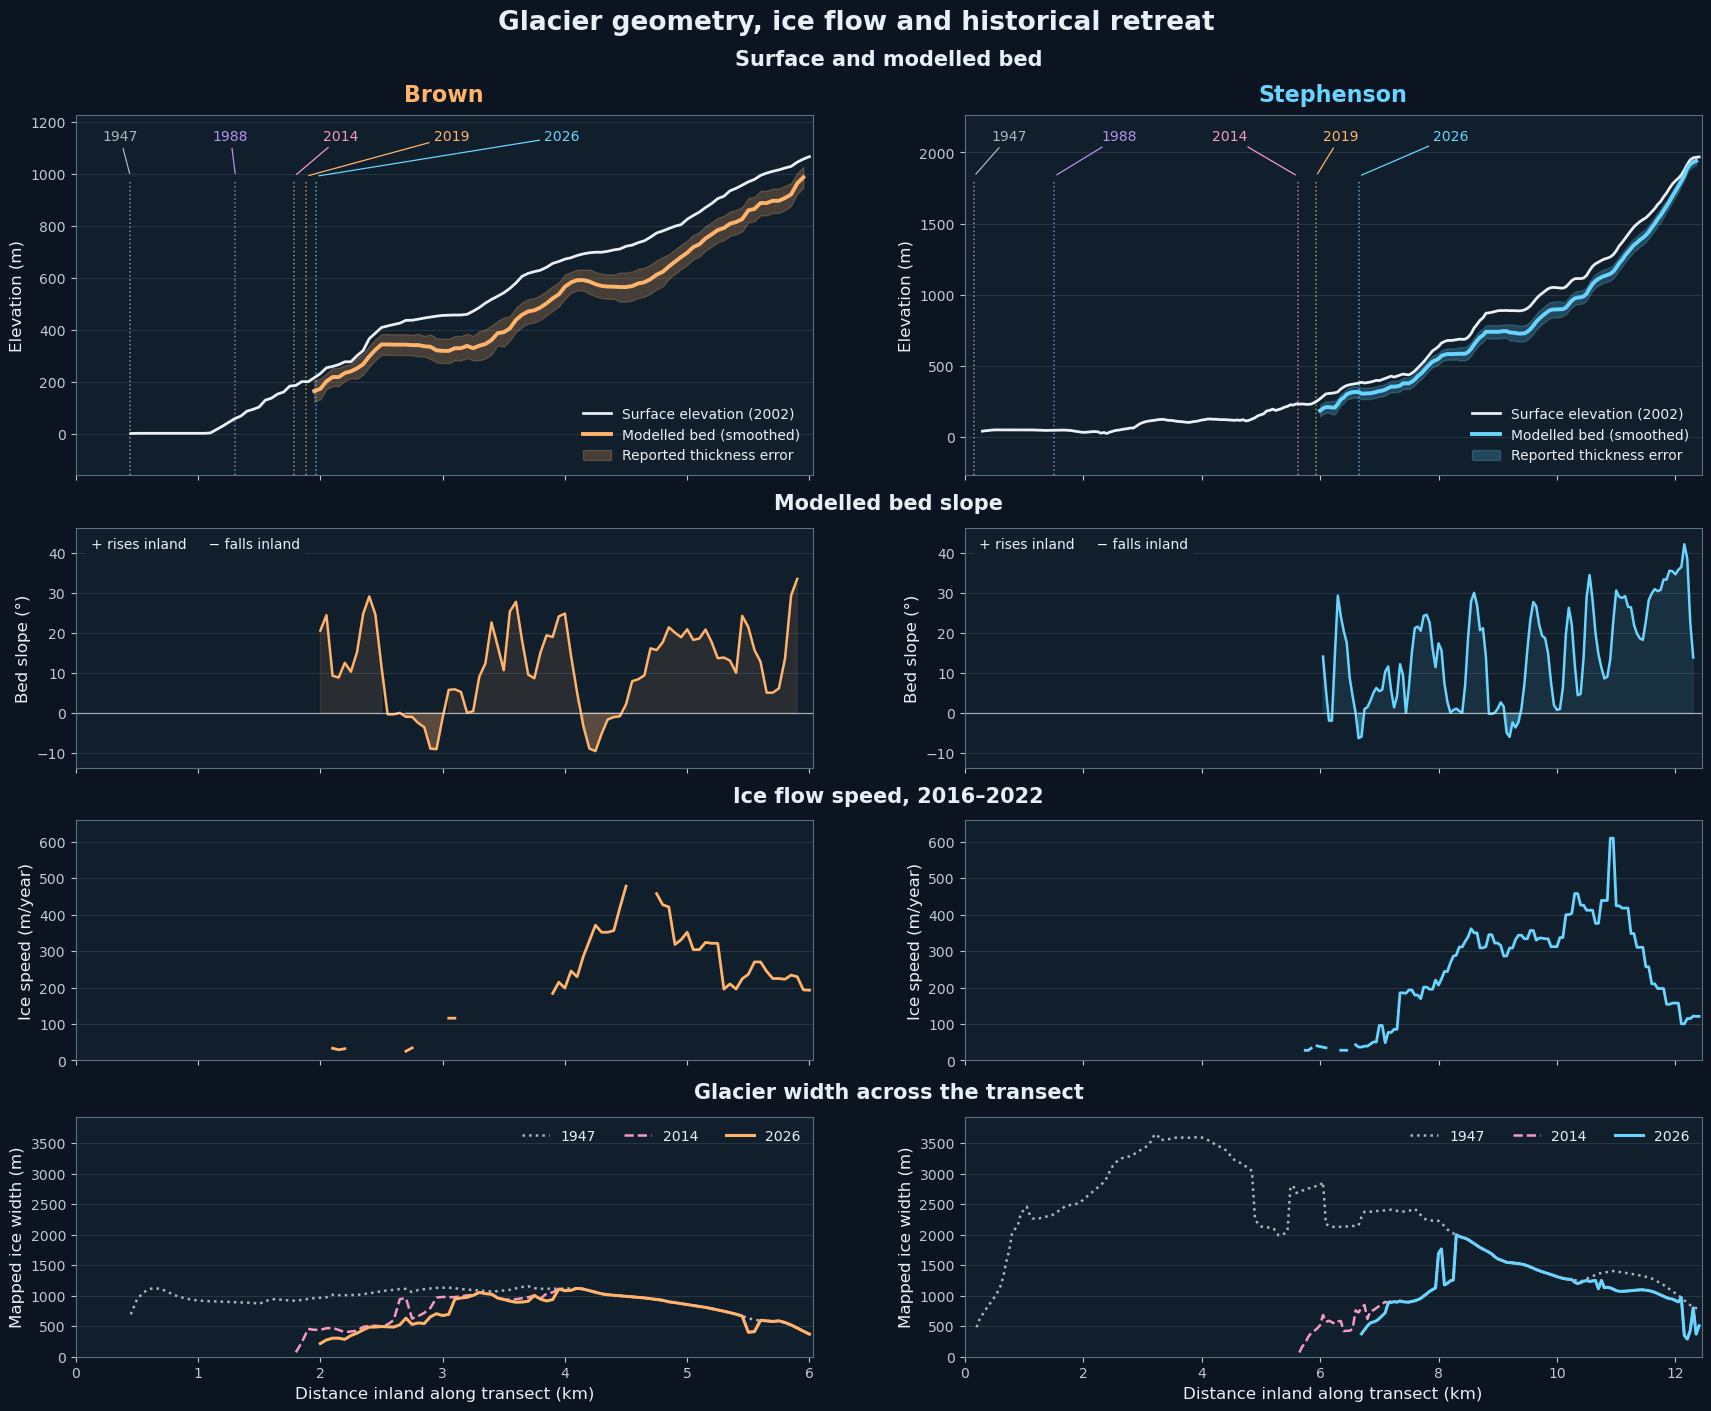

In [7]:
## Sample bed geometry, contemporary flow and mapped corridor width ##

def corridor_width(line, station, polygon):
    """Measure the connected polygon width through a station, not bedrock valley width."""
    xy = transect_xy(line, [station], [-4000, 0, 4000])[0]
    cross = LineString([xy[0], xy[2]])
    centre = Point(xy[1])
    pieces = line_parts(cross.intersection(polygon))
    pieces = line_parts(linemerge(pieces)) if len(pieces) > 1 else pieces
    selected = [p for p in pieces if p.distance(centre) < 0.01]
    if not selected:
        return np.nan
    piece = max(selected, key = lambda p: p.length)
    return piece.length if piece.length < cross.length - 1 else np.nan


profiles, profile_swaths = {}, {}
terminus_rows = []

for name in names:
    line = transects[name]
    stations = np.arange(0, line.length, settings['step_m'])
    xy = transect_xy(line, stations, settings['offsets_m'])
    p = pd.DataFrame({'name_1': name, 'distance_m': stations,
        'E': xy[:, 2, 0], 'N': xy[:, 2, 1]})

    for layer, path in raster_paths.items():
        footprint = get_outline(name, 2019) if layer in ['bed', 'error'] else None
        values, ids = sample_raster(path, xy, footprint)
        p[layer + '_m'], p[layer + '_cells'] = swath_median(values, ids)
        if layer == 'bed':
            profile_swaths[name] = values

    rgi = velocity.loc[velocity.name_1.eq(name), 'RGIId'].iloc[0]
    values, ids = sample_raster(project_path(velocity_layers[rgi]['layers']['median_speed']),
        xy, get_outline(name, 2014))
    p['speed_m_yr'], p['speed_cells'] = swath_median(values, ids)
    p['bed_smooth_m'] = smooth_profile(p.bed_m.to_numpy())
    p['bed_gradient_deg'] = np.degrees(np.arctan(np.gradient(p.bed_smooth_m, settings['step_m'])))
    p.loc[p.bed_smooth_m.isna(), 'bed_gradient_deg'] = np.nan

    for year in [1947, 2014, 2026]:
        p[f'width_{year}_m'] = [corridor_width(line, s, get_outline(name, year)) for s in stations]
    profiles[name] = p

    for year in years:
        pieces = line_parts(line.intersection(get_outline(name, year)))
        pieces = line_parts(linemerge(pieces)) if len(pieces) > 1 else pieces
        connected = [part for part in pieces if part.distance(Point(line.coords[-1])) < 0.01]
        front = min(line.project(Point(c)) for c in connected[0].coords) if len(connected) == 1 else np.nan
        terminus_rows.append(dict(name_1 = name, year = year, front_distance_m = front,
            intersected_segments = len(pieces), definition = 'start of inland-connected transect segment'))

profile_table = pd.concat(profiles.values(), ignore_index = True)
termini = pd.DataFrame(terminus_rows).sort_values(['name_1', 'year'])
rate_rows = []

for name, part in termini.groupby('name_1', sort = False):
    for before, after in zip(list(part.itertuples())[:-1], list(part.itertuples())[1:]):
        rate_rows.append(dict(name_1 = name, start_year = before.year, end_year = after.year,
            transect_retreat_m = after.front_distance_m - before.front_distance_m,
            transect_retreat_m_yr = (after.front_distance_m - before.front_distance_m) / (after.year - before.year)))

transect_retreat = pd.DataFrame(rate_rows)
profile_table.to_csv(synthesis_dir / 'geomorphology_profiles.csv', index = False)
termini.to_csv(synthesis_dir / 'transect_termini.csv', index = False)
transect_retreat.to_csv(synthesis_dir / 'transect_retreat_rates.csv', index = False)

fig = plt.figure(figsize = (17, 14), layout = 'constrained')
fig.suptitle('Glacier geometry, ice flow and historical retreat',
    fontsize = 19, fontweight = 'semibold')

grid = fig.add_gridspec(8, 2,
    height_ratios = [0.13, 1.5, 0.13, 1, 0.13, 1, 0.13, 1])

axes = np.empty((4, 2), dtype = object)
row_headings = ['Surface and modelled bed', 'Modelled bed slope',
    'Ice flow speed, 2016–2022', 'Glacier width across the transect']

for row, heading in enumerate(row_headings):
    heading_ax = fig.add_subplot(grid[2 * row, :])
    heading_ax.axis('off')
    heading_ax.text(0.5, 0.5, heading, transform = heading_ax.transAxes,
        ha = 'center', va = 'center', fontsize = 15, fontweight = 'semibold')

    for j in range(2):
        axes[row, j] = fig.add_subplot(grid[2 * row + 1, j],
            sharex = axes[0, j] if row else None)
        if row < 3:
            axes[row, j].tick_params(axis = 'x', labelbottom = False)

front_colours = {1947: '#AAB4C3', 1988: '#B292EE', 2014: '#F49AC2',
    2019: '#FFB36B', 2026: '#69D5FF'}

slope_min = min(0, profile_table.bed_gradient_deg.min())
slope_max = max(0, profile_table.bed_gradient_deg.max())
slope_padding = max(2, 0.08 * (slope_max - slope_min))
speed_max = profile_table.speed_m_yr.max() * 1.08
width_max = profile_table[
    ['width_1947_m', 'width_2014_m', 'width_2026_m']].max().max() * 1.08

for j, name in enumerate(names):
    p = profiles[name]
    x = p.distance_m.to_numpy() / 1000
    bed = p.bed_smooth_m.to_numpy()
    error = p.error_m.to_numpy()
    gradient = p.bed_gradient_deg.to_numpy()
    colour = colours[name]


    elevation_ax = axes[0, j]
    elevation_ax.plot(x, p.surface_m, color = '#E8EFF5', linewidth = 2,
        label = 'Surface elevation (2002)', zorder = 3)
    elevation_ax.plot(x, bed, color = colour, linewidth = 2.8,
        label = 'Modelled bed (smoothed)', zorder = 4)
    elevation_ax.fill_between(x, bed - error, bed + error,
        where = np.isfinite(bed) & np.isfinite(error), color = colour,
        alpha = 0.22, label = 'Reported thickness error', zorder = 2)
    elevation_ax.set_title(name, fontsize = 16, color = colour, pad = 10)
    elevation_ax.set_ylabel('Elevation (m)')
    elevation_ax.margins(y = 0.15)
    elevation_ax.legend(loc = 'lower right', fontsize = 10)

    fronts = termini.loc[termini.name_1.eq(name)
        & termini.front_distance_m.notna()].sort_values('front_distance_m')

    for row, label_x in zip(fronts.itertuples(), np.linspace(0.06, 0.66, len(fronts))):
        front_x = row.front_distance_m / 1000
        front_colour = front_colours[row.year]
        elevation_ax.axvline(front_x, ymax = 0.82, color = front_colour,
            linestyle = ':', linewidth = 1.1, alpha = 0.75)
        elevation_ax.annotate(str(row.year), xy = (front_x, 0.83),
            xycoords = elevation_ax.get_xaxis_transform(),
            xytext = (label_x, 0.96), textcoords = 'axes fraction',
            ha = 'center', va = 'top', fontsize = 10, color = front_colour,
            arrowprops = dict(arrowstyle = '-', color = front_colour, lw = 0.9),
            bbox = dict(facecolor = '#111E2C', edgecolor = 'none', pad = 1.5))

    slope_ax = axes[1, j]
    slope_ax.plot(x, gradient, color = colour, linewidth = 1.8)
    slope_ax.axhline(0, color = '#E8EFF5', linewidth = 0.9, alpha = 0.65)
    slope_ax.fill_between(x, 0, gradient, where = gradient >= 0,
        color = colour, alpha = 0.10)
    slope_ax.fill_between(x, 0, gradient, where = gradient < 0,
        color = colour, alpha = 0.30)
    slope_ax.set_ylabel('Bed slope (°)')
    slope_ax.set_ylim(slope_min - slope_padding, slope_max + slope_padding)
    slope_ax.text(0.02, 0.96, '+ rises inland     − falls inland',
        transform = slope_ax.transAxes, va = 'top', fontsize = 10,
        bbox = dict(facecolor = '#111E2C', edgecolor = 'none', alpha = 0.9))

    speed_ax = axes[2, j]
    speed_ax.plot(x, p.speed_m_yr, color = colour, linewidth = 2)
    speed_ax.set(ylabel = 'Ice speed (m/year)', ylim = (0, speed_max))

    width_ax = axes[3, j]
    width_styles = {
        1947: dict(color = '#AAB4C3', linestyle = ':', linewidth = 1.8),
        2014: dict(color = '#F49AC2', linestyle = '--', linewidth = 1.8),
        2026: dict(color = colour, linestyle = '-', linewidth = 2.2)}

    for year, style in width_styles.items():
        width_ax.plot(x, p[f'width_{year}_m'], label = str(year), **style)

    width_ax.set(ylabel = 'Mapped ice width (m)', ylim = (0, width_max),
        xlabel = 'Distance inland along transect (km)')
    width_ax.legend(loc = 'upper right', fontsize = 10, ncol = 3)

    for ax in axes[:, j]:
        ax.set_xlim(0, transects[name].length / 1000)
        ax.grid(axis = 'y', alpha = 0.15)
        ax.tick_params(labelsize = 10)

save_figure(fig, '04b_geometry_flow_profiles')

**Figure. Glacier geometry, ice flow and historical retreat along the Brown and Stephenson transects.** Brown occupies the left column and Stephenson the right. The **first row** shows the 2002 surface and modelled bed, smoothed using a three-station median. Shading illustrates ± the reported thickness-error magnitude around the bed curve; it is not a confidence interval and excludes DEM error and differences between input dates. Dated vertical lines locate the historical fronts. The **second row** shows modelled bed slope, with positive values rising inland and negative values falling inland. The **third row** shows filtered 2016–2022 ice speeds. The **fourth row** compares mapped glacier widths in 1947, 2014 and 2026. Bed slope, speed and width use matching vertical scales across glaciers; elevation panels use separate vertical scales. Transect lengths differ, and missing values remain gaps.

### Results and interpretation

#### The modelled bed contains possible geometric controls

Both surface profiles generally rise inland, while the modelled beds include local rises and dips. Brown has broad bed highs near **2.5 and 4.1 km**, followed by sections that fall inland. Stephenson has a more stepped inland rise with several shorter reversals in slope. These features provide locations for the closer examination in the next section.

The bed estimates cover ice within the 2019 outline, leaving the formerly occupied coastal terrain without equivalent modelled bed profiles. They therefore cannot establish the bed conditions beneath the entire historical glacier tongue.

Catania et al. (2018) show that bed shape and fjord geometry can influence retreat at Greenland tidewater glaciers. Their findings provide a reason to investigate geometry here, but these profiles alone do not demonstrate that a particular bed high stabilised either glacier.

The thickness product also uses ice motion and surface topography in its modelling (Millan et al., 2022). Relationships between modelled geometry and flow should therefore not be treated as wholly independent evidence of a bed control.

#### The glaciers have different front-retreat histories

Brown’s interval-average transect retreat remained approximately **18–21 m/year from 1947 to 2019**, then decreased to **11.90 m/year during 2019–2026**.

Stephenson retreated at **33.12 m/year during 1947–1988**, increasing to **158.07 m/year during 1988–2014**. Its rate then fell to **61.31 m/year during 2014–2019**, before increasing again to **103.48 m/year during 2019–2026**.

These are average front-displacement rates between mapped dates, rather than observations of steady annual retreat.

#### Faster front retreat can accompany less area loss

Stephenson’s recent front-retreat rate increased while its annual percentage area-loss rate fell from **1.84% to 0.40%**. The width profiles show that its former lower tongue was much broader than the surviving tongue. Retreat through a narrower glacier can remove less area for a given distance of front displacement, providing a plausible geometric contribution to this difference.

Brown shows the opposite combination: recent front retreat slowed while its annual percentage area-loss rate increased from approximately **0.42% to 0.61%**. A front position measures change along one route, whereas area loss includes changes around the whole mapped glacier boundary.

#### Flow varies along the routes, with important gaps at Brown

Both velocity profiles contain faster sections farther inland than the sampled lower reaches, followed by lower speeds near their inland endpoints. Speed therefore does not increase steadily along either route.

Brown’s lower profile contains extensive gaps where no velocity values passed the filtering and sampling requirements. These gaps cannot be interpreted as stationary ice and prevent a continuous comparison of flow across its lower terrain transitions.

The profiles also combine observations from different periods. The 2016–2022 speed record does not measure flow throughout every historical retreat interval, and sampling it every 50 m does not increase its spatial resolution (Lei et al., 2022). Finally, the width curves describe mapped ice geometry; they do not measure the width of the underlying bedrock valley.

### References for this section

Catania, G. A., Stearns, L. A., Sutherland, D. A., Fried, M. J., Bartholomaus, T. C., Morlighem, M., Shroyer, E., & Nash, J. (2018). Geometric controls on tidewater glacier retreat in central western Greenland. *Journal of Geophysical Research: Earth Surface, 123*(8), 2024–2038. [https://doi.org/10.1029/2017JF004499](https://doi.org/10.1029/2017JF004499)

Lei, Y., Gardner, A. S., & Agram, P. (2022). Processing methodology for the ITS_LIVE Sentinel-1 ice velocity products. *Earth System Science Data, 14*, 5111–5137. [https://doi.org/10.5194/essd-14-5111-2022](https://doi.org/10.5194/essd-14-5111-2022)

Millan, R., Mouginot, J., Rabatel, A., & Morlighem, M. (2022). Ice velocity and thickness of the world’s glaciers. *Nature Geoscience, 15*, 124–129. [https://doi.org/10.1038/s41561-021-00885-z](https://doi.org/10.1038/s41561-021-00885-z)

### Potential bed highs and sensitivity checks

This step identifies local rises in the modelled glacier bed and checks whether they remain visible when we change the sampling and smoothing choices. We call these features **potential bed highs** because their shape and existence remain uncertain.

The initial screening selects peaks that rise at least **10 m above their surroundings**, with a minimum separation of **300 m**. These are selection rules for finding features worth examining; they do not establish that a feature exceeds the modelling uncertainty.

Each selected high is examined using seven sensitivity checks:

- **Stronger smoothing:** increase the rolling median from three sampling stations to five.
- **Different sampling positions:** sample parallel profiles 100 m to either side of the original transect.
- **Different thickness assumptions:** apply four smooth, wave-shaped thickness adjustments, using the reported thickness-error magnitude as their amplitude. Each wave has a 1 km wavelength, with its peaks positioned differently along the profile.

A check retains the feature if a selected peak remains within **150 m** of its original position. Checks without enough valid model data around that location are left unassessed.

The resulting counts describe how consistently a feature appears under these particular choices. They are not probabilities that the feature exists.

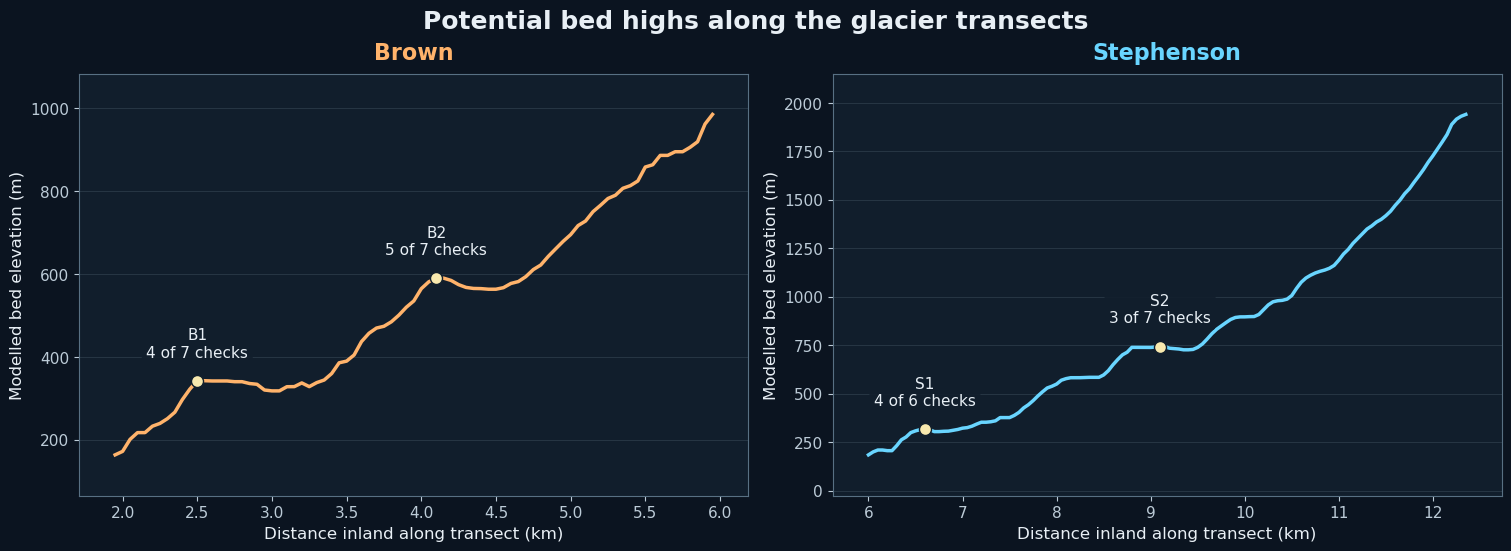

In [8]:
## Screen potential bed highs and test their persistence ##

candidate_rows = []

for name in names:
    p = profiles[name]
    x = p.distance_m.to_numpy()
    variants = {'wider_smoothing': smooth_profile(p.bed_m.to_numpy(), 5),
        'offset_minus_100m': smooth_profile(profile_swaths[name][:, 0]),
        'offset_plus_100m': smooth_profile(profile_swaths[name][:, -1])}

    # Deterministic shape tests, not probabilistic error realisations.
    for phase in np.arange(4) * np.pi / 2:
        delta = p.error_m.to_numpy() * np.sin(
            2 * np.pi * x / settings['perturbation_wavelength_m'] + phase)
        trial = np.minimum(p.surface_m.to_numpy(), p.bed_m.to_numpy() - delta)
        variants[f'error_phase_{phase:.2f}'] = smooth_profile(trial)

    base = p.bed_smooth_m.to_numpy()
    for number, index in enumerate(crest_indices(base), 1):
        row = dict(name_1 = name, candidate = f'{name[0]}{number}', distance_m = x[index],
            E = p.E.iloc[index], N = p.N.iloc[index], candidate_bed_m = base[index],
            reported_thickness_error_m = p.error_m.iloc[index], speed_m_yr = p.speed_m_yr.iloc[index])
        for label, trial in variants.items():
            nearby = np.abs(x - x[index]) <= settings['crest_match_m']
            supported = np.isfinite(trial[nearby]).all()
            peaks = crest_indices(trial)
            row[label] = (bool(np.any(np.abs(x[peaks] - x[index]) <= settings['crest_match_m']))
                if supported else None)
        tested = [row[label] for label in variants if row[label] is not None]
        row['supported_trials'] = len(tested)
        row['trials_with_nearby_high'] = sum(tested)
        candidate_rows.append(row)

candidates = pd.DataFrame(candidate_rows, columns = ['name_1', 'candidate', 'distance_m', 'E', 'N',
    'candidate_bed_m', 'reported_thickness_error_m', 'speed_m_yr', *variants,
    'supported_trials', 'trials_with_nearby_high'])
candidates.to_csv(synthesis_dir / 'candidate_bed_highs.csv', index = False)

fig, axes = plt.subplots(1, 2, figsize = (15, 5.4), layout = 'constrained')
fig.suptitle('Potential bed highs along the glacier transects',
    fontsize = 18, fontweight = 'semibold')

for ax, name in zip(axes, names):
    p = profiles[name]
    ax.plot(p.distance_m / 1000, p.bed_smooth_m,
        color = colours[name], linewidth = 2.5)

    selected = candidates.loc[candidates.name_1.eq(name)]
    for row in selected.itertuples():
        ax.scatter(row.distance_m / 1000, row.candidate_bed_m,
            s = 75, color = '#F8E9AE', edgecolor = '#111E2C',
            linewidth = 1, zorder = 4)
        label = (f'{row.candidate}\n'
            f'{row.trials_with_nearby_high} of {row.supported_trials} checks')
        ax.annotate(label, (row.distance_m / 1000, row.candidate_bed_m),
            xytext = (0, 15), textcoords = 'offset points',
            ha = 'center', va = 'bottom', fontsize = 11,
            bbox = dict(boxstyle = 'round,pad=0.3',
                facecolor = '#111E2C', edgecolor = 'none', alpha = 0.9))

    if selected.empty:
        ax.text(0.04, 0.92, 'No highs met the screening criteria',
            transform = ax.transAxes, va = 'top', fontsize = 11)

    ax.set_title(name, fontsize = 16, color = colours[name], pad = 10)
    ax.set(xlabel = 'Distance inland along transect (km)',
        ylabel = 'Modelled bed elevation (m)')
    ax.margins(x = 0.06, y = 0.12)
    ax.grid(axis = 'y', alpha = 0.15)
    ax.tick_params(labelsize = 11)

save_figure(fig, '04c_candidate_bed_highs')

*Figure. Potential bed highs along the Brown and Stephenson glacier transects. Coloured lines show the modelled bed after a three-station rolling median; pale yellow markers identify peaks meeting the screening criteria. Distance is measured inland from each transect’s seaward origin. Labels report the number of assessable sensitivity checks that retained a selected peak within 150 m of the original location. S1 has six assessable checks because one displaced profile lacks sufficient model data. The panels use different elevation scales.*

### Results and interpretation

Four potential bed highs were identified: **B1 at 2.50 km** and **B2 at 4.10 km** along Brown’s transect, and **S1 at 6.60 km** and **S2 at 9.10 km** along Stephenson’s.

Brown’s **B2 retained a nearby peak in five of seven checks**, the largest count among the four features. B1 retained a peak in four of seven checks, S1 in four of six, and S2 in three of seven. None remained selected under every assessable check.

The displaced profiles show why these features need cautious interpretation. Neither Brown high was selected in the profile displaced +100 m. Stephenson’s S2 was not selected in either displaced profile. Stronger smoothing removed S1 from the selected peaks, while insufficient data prevented assessment of its +100 m profile. The appearance of these highs therefore depends partly on where the transect passes and how the modelled bed is smoothed.

S1 lies near the mapped 2026 front and coincides with a sampled ice speed of **43.05 m/year** in the 2016–2022 velocity data. This makes it a useful location for closer inspection, but the different observation periods prevent treating that speed as a measurement of conditions at the 2026 front. Brown’s B1 has no retained velocity value, so its speed cannot be compared with the other highs.

Bed geometry offers a plausible reason for investigating these locations. Catania et al. (2018) showed that bed and fjord geometry can influence the pace of retreat in Greenland’s tidewater glaciers, although raised sections do not invariably stop retreat. That study provides physical context for this investigation; the features identified here have not been shown to stabilise either Heard Island glacier.

A peak along one transect also does not establish that a ridge extends across the glacier. The cross-sections below examine that possibility. Furthermore, glacier velocity was already used to estimate the thickness product underlying our modelled bed (Millan et al., 2022), so correspondence between bed shape and ice speed provides limited independent confirmation.

### References for this section

- Catania, G. A., Stearns, L. A., Sutherland, D. A., Fried, M. J., Bartholomaus, T. C., Morlighem, M., Shroyer, E., & Nash, J. (2018). Geometric controls on tidewater glacier retreat in central western Greenland. *Journal of Geophysical Research: Earth Surface, 123*(8), 2024–2038. https://doi.org/10.1029/2017JF004499

- Millan, R., Mouginot, J., Rabatel, A., & Morlighem, M. (2022). Ice velocity and thickness of the world’s glaciers. *Nature Geoscience, 15*, 124–129. https://doi.org/10.1038/s41561-021-00885-z

### Cross-sections near the recent front and potential bed highs

Each cross-section is a slice across the glacier and surrounding terrain, perpendicular to the main analysis transect. These cuts help us examine whether a high identified along the glacier also forms a rise across it.

Sections are taken **250 m inland of the mapped 2026 front**, at selected potential bed highs, and at an additional comparison location where needed. Sections are kept at least 300 m apart along the main transect. Brown’s B1 is therefore not shown separately because it lies too close to the near-front section.

The horizontal axis measures distance from the main transect: **0 m marks the transect**, and negative and positive values represent its opposite sides. The distance in each panel heading identifies where the section lies along the main transect.

The white line shows the **2002 surface elevation**, including neighbouring terrain. The dashed line shows the **modelled bed**, calculated using surface elevation and estimated ice thickness (Millan et al., 2022), wherever valid values occur inside the 2019 glacier outline. Gaps indicate unavailable bed estimates.

These sections use direct raster samples; the preceding bed-high screening used smoothed profiles. Their elevations need not match exactly. The surface and thickness inputs also represent different periods, so the separation between the lines is not a measurement of 2026 ice thickness.

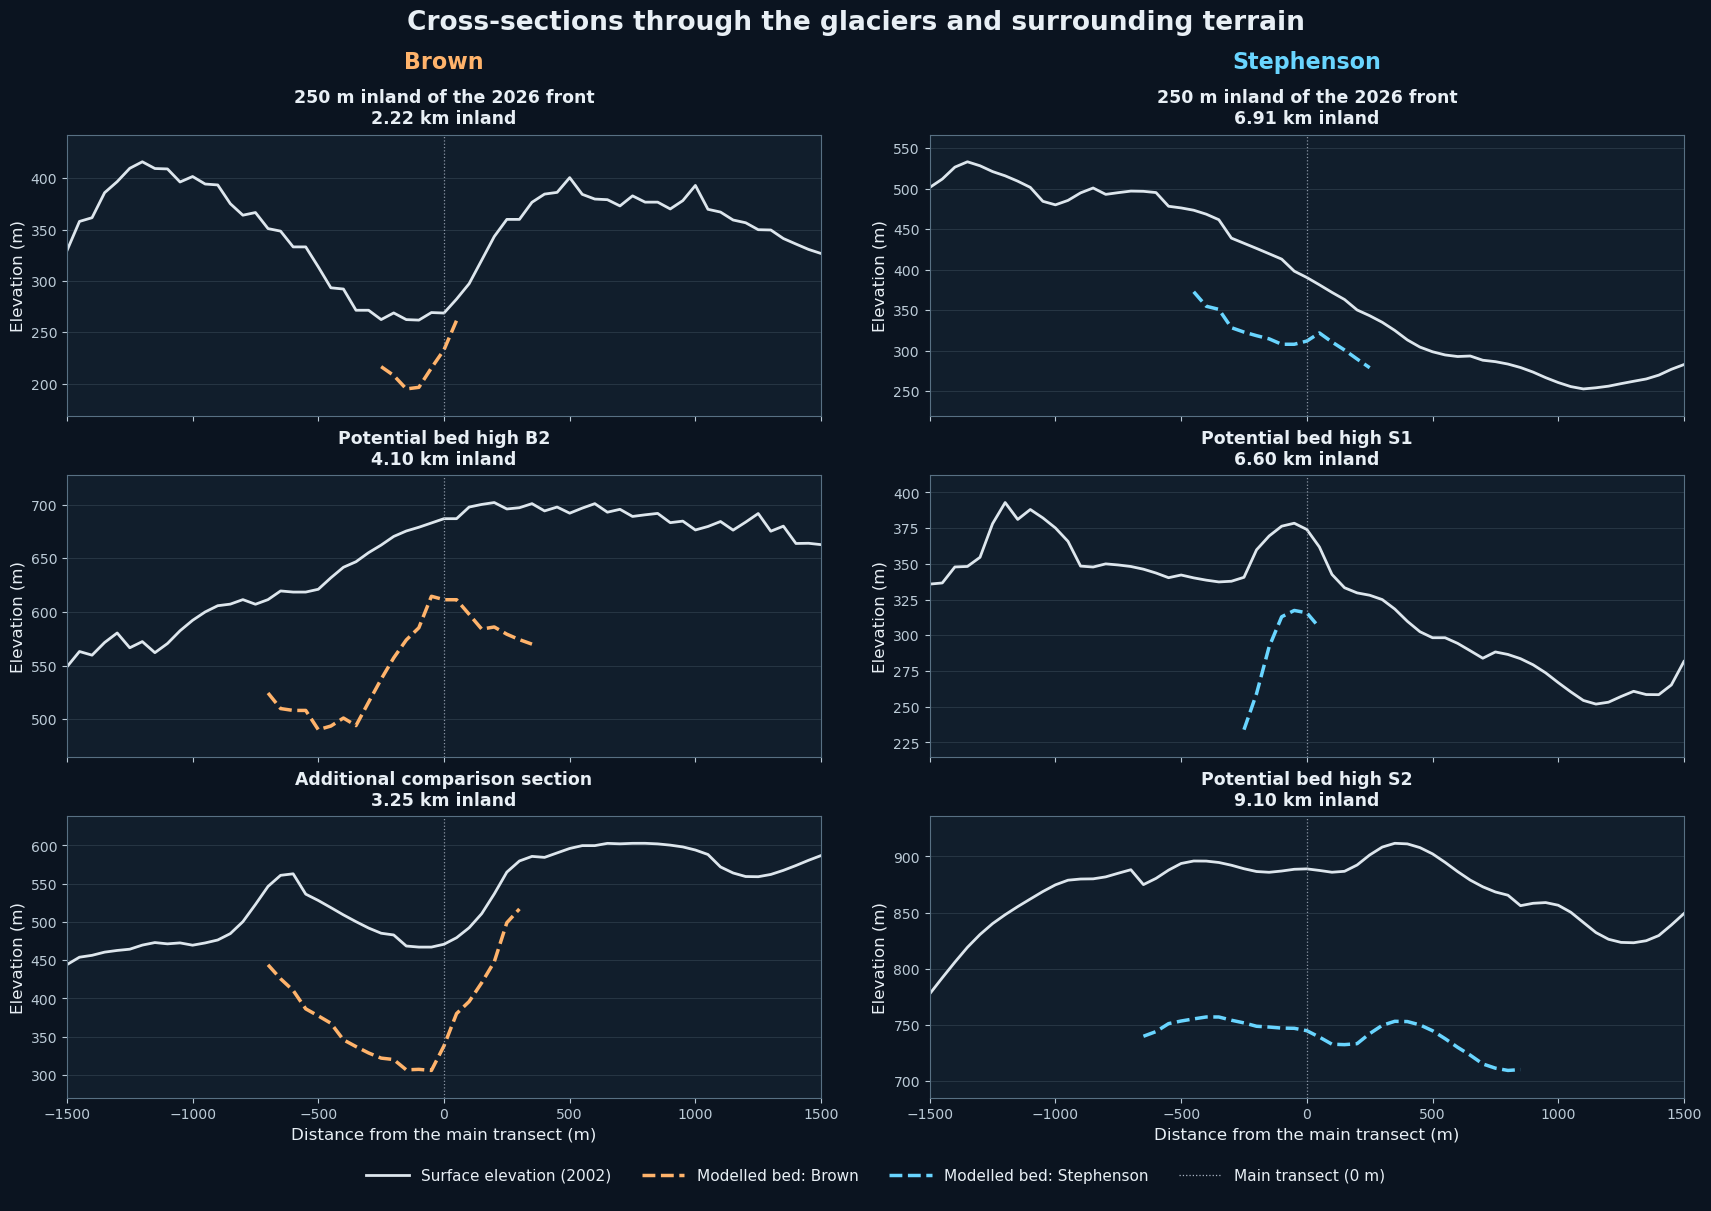

In [9]:
## Inspect cross-sections near the recent front and potential bed highs ##

glacier_sections = []
fig = plt.figure(figsize = (17, 12), layout = 'constrained')
fig.suptitle('Cross-sections through the glaciers and surrounding terrain',
    fontsize = 19, fontweight = 'semibold')
grid = fig.add_gridspec(5, 2, height_ratios = [0.13, 1, 1, 1, 0.18])
axes = np.empty((3, 2), dtype = object)

for column, name in enumerate(names):
    heading_ax = fig.add_subplot(grid[0, column])
    heading_ax.axis('off')
    heading_ax.text(0.5, 0.5, name, transform = heading_ax.transAxes,
        ha = 'center', va = 'center', fontsize = 16,
        fontweight = 'semibold', color = colours[name])
    for row_number in range(3):
        axes[row_number, column] = fig.add_subplot(grid[row_number + 1, column],
            sharex = axes[0, column] if row_number else None)

legend_ax = fig.add_subplot(grid[4, :])
legend_ax.axis('off')

for column, name in enumerate(names):
    line, p = transects[name], profiles[name]
    front = termini.loc[termini.name_1.eq(name) & termini.year.eq(2026), 'front_distance_m'].iloc[0]
    selected = [('Behind 2026 front', min(line.length - 100, front + 250))]
    ranked = candidates.loc[candidates.name_1.eq(name)].sort_values(
        'trials_with_nearby_high', ascending = False)
    options = [(row.candidate, row.distance_m) for row in ranked.itertuples()]
    supported_stations = p.loc[p.bed_m.notna(), 'distance_m']

    if len(supported_stations):
        options += [(f'Context {i + 1}', s)
            for i, s in enumerate(supported_stations.quantile([0.33, 0.67]))]
    for label, station in options:
        if len(selected) < 3 and all(abs(station - s) >= 300 for _, s in selected):
            selected.append((label, station))

    for row_number, ax in enumerate(axes[:, column]):
        if row_number >= len(selected):
            ax.set_visible(False)
            continue
        label, station = selected[row_number]
        offsets = np.arange(-1500, 1501, 50)
        xy = transect_xy(line, [station], offsets)[0]
        surface_values, _ = sample_raster(raster_paths['surface'], xy)
        bed_values, _ = sample_raster(raster_paths['bed'], xy, get_outline(name, 2019))
        glacier_sections.append(pd.DataFrame({'name_1': name, 'section': label, 'distance_m': station,
            'offset_m': offsets, 'E': xy[:, 0], 'N': xy[:, 1],
            'surface_m': surface_values, 'bed_m': bed_values}))
        ax.plot(offsets, surface_values, color = '#DDE6ED', linewidth = 2)
        ax.plot(offsets, bed_values, '--', color = colours[name], linewidth = 2.5)
        ax.axvline(0, color = '#AAB4C3', linestyle = ':',
            linewidth = 0.9, alpha = 0.8)

        if label == 'Behind 2026 front':
            panel_title = '250 m inland of the 2026 front'
        elif label.startswith('Context'):
            panel_title = 'Additional comparison section'
        else:
            panel_title = f'Potential bed high {label}'

        ax.set_title(f'{panel_title}\n{station / 1000:.2f} km inland',
            fontsize = 12.5, pad = 8)
        ax.set_ylabel('Elevation (m)')
        ax.set_xlim(-1500, 1500)
        ax.set_xticks(np.arange(-1500, 1501, 500))
        ax.margins(y = 0.12)
        ax.grid(axis = 'y', alpha = 0.15)
        ax.tick_params(labelsize = 10)
        if row_number == len(selected) - 1:
            ax.set_xlabel('Distance from the main transect (m)')
        else:
            ax.tick_params(axis = 'x', labelbottom = False)

legend_handles = [
    Line2D([0], [0], color = '#DDE6ED', linewidth = 2,
        label = 'Surface elevation (2002)'),
    Line2D([0], [0], color = colours['Brown'], linestyle = '--', linewidth = 2.5,
        label = 'Modelled bed: Brown'),
    Line2D([0], [0], color = colours['Stephenson'], linestyle = '--', linewidth = 2.5,
        label = 'Modelled bed: Stephenson'),
    Line2D([0], [0], color = '#AAB4C3', linestyle = ':', linewidth = 0.9,
        label = 'Main transect (0 m)')]
legend_ax.legend(handles = legend_handles, loc = 'center',
    ncol = 4, fontsize = 11, handlelength = 2.8, columnspacing = 2)
glacier_cross_sections = pd.concat(glacier_sections, ignore_index = True)
glacier_cross_sections.to_csv(synthesis_dir / 'glacier_cross_sections.csv', index = False)
save_figure(fig, '04d_glacier_cross_sections')

*Figure. Cross-sections through Brown and Stephenson glaciers and their surrounding terrain. White lines show the 2002 surface; coloured dashed lines show valid modelled-bed estimates inside the 2019 glacier outline. The dotted vertical line marks the main transect. Panel headings give each section’s distance inland from the transect’s seaward origin. All panels share the same horizontal scale but use different elevation scales, so apparent steepness should not be compared directly. The surface–bed separation is not a measurement of 2026 ice thickness.*

### Results and interpretation

#### Brown: a local rise at B2

Near Brown’s 2026 front, the 2002 surface forms a broad valley, while the available modelled-bed estimates trace a local trough close to the main transect.

Farther inland, **B2 forms a rise near the transect, with lower modelled elevations on both sides**. Combined with the crest identified along the glacier, this gives B2 a modelled rise in both sampling directions. It is therefore a useful location for investigating a possible influence of bed geometry on glacier behaviour.

The additional comparison section contains a pronounced trough and a marked rise towards positive offsets. Brown’s modelled bed consequently varies substantially between the sampled locations.

#### Stephenson: limited coverage at S1

At **S1**, the available modelled bed rises towards the main transect, but extends only a short distance onto its other side. There is too little lateral coverage to determine whether this feature forms a broader ridge across the glacier.

At **S2**, the sampled bed shows gentle undulations and a small dip near the main transect. This section provides no clear evidence of a continuous barrier across the glacier.

#### Why the hell did I spent 90 minutes on this?

The cross-sections make the terrain hypothesis more specific: **Brown’s B2 is a local rise worth investigating, while Stephenson’s S1 remains difficult to assess because of missing lateral data**. Neither has been established as a sill extending across the valley or as a location where the glacier front stabilised.

Studies of Greenland’s tidewater glaciers show that bed geometry can influence retreat, including differences in retreat across a single glacier front (Catania et al., 2018). Those observations provide a physical reason to examine these features, although the glacier settings differ.

Here, the profiles identify locations where a terrain–retreat relationship could be tested. Confirming that relationship would require independent bed measurements and a more detailed record of front movement around the features.

### References for this section

- Catania, G. A., Stearns, L. A., Sutherland, D. A., Fried, M. J., Bartholomaus, T. C., Morlighem, M., Shroyer, E., & Nash, J. (2018). Geometric controls on tidewater glacier retreat in central western Greenland. *Journal of Geophysical Research: Earth Surface, 123*(8), 2024–2038. https://doi.org/10.1029/2017JF004499

- Millan, R., Mouginot, J., Rabatel, A., & Morlighem, M. (2022). Ice velocity and thickness of the world’s glaciers. *Nature Geoscience, 15*, 124–129. https://doi.org/10.1038/s41561-021-00885-z

### Potential summer solar exposure

A glacier’s slope and the direction it faces affect how sunlight strikes its surface. Here, we calculate an **orientation index** by comparing each cell with a horizontal surface at the same latitude.

| Index | Meaning under the calculation |
| --- | --- |
| Below 1.00 | Lower potential direct solar exposure than a horizontal surface |
| 1.00 | Exposure equal to a horizontal surface |
| Above 1.00 | Higher potential direct solar exposure than a horizontal surface |

For example, **1.05 represents 5% greater geometric exposure** than the horizontal comparison. It does not mean 5% more melting.

The calculation follows the sun through daylight on four representative days, one each in November, December, January and February. Slope and direction are derived from the 2002 DEM and summarised onto a 120 m grid within the 2014 glacier outlines. Nearly flat cells are assigned an index of one; cells with strongly mixed surface directions are excluded.

The maps show the index across each glacier. The pink contour and “Below 600 m” label identify the lower-elevation area used for the second comparison. **Valid coverage** reports the percentage of cells with an index in each comparison area.

This calculation isolates surface orientation. It excludes shadows cast by surrounding terrain, atmospheric attenuation, cloud, surface reflectivity and debris effects.

The exposure index combines DEM-derived surface slope and aspect with calculated solar directions at latitude 53.1°S. Solar declination—the seasonal angle of the Sun relative to the equator—is estimated using a Cooper-type approximation, with a 23.44° coefficient (Cooper, 1969). At each sampled time, the dot product of the surface-normal and solar-direction vectors gives the cosine of the incidence angle: a surface facing the Sun receives a larger projection than one tilted away (Iqbal, 1983). Only times when the Sun is above the horizon are included, and negative surface projections are set to zero. These projections are summed and divided by the corresponding sum for a horizontal surface. Sampling four representative November–February dates at hourly intervals is a project-specific approximation. The resulting index describes potential exposure from surface orientation; it does not include cloud, atmospheric attenuation, diffuse radiation or shadows cast by surrounding terrain.

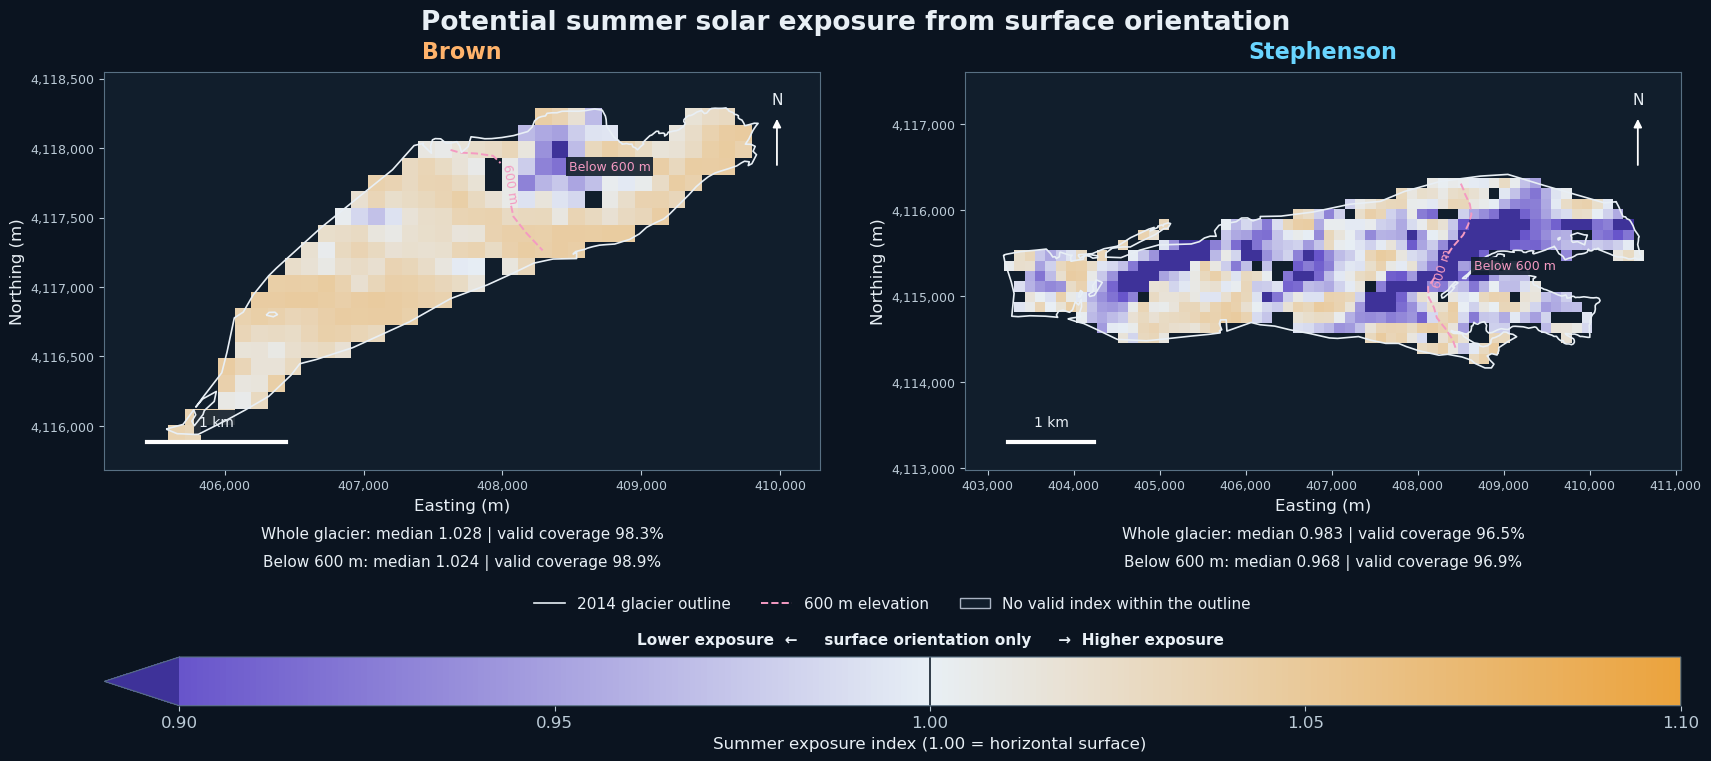

In [10]:
## Map potential summer exposure from surface orientation ##

def summer_incidence(slope_deg, aspect_deg, latitude_deg = -53.1):
    """Direct-beam incidence relative to a horizontal surface; no cloud or horizon shading."""
    slope = np.radians(slope_deg)
    aspect = np.radians(aspect_deg)
    east = np.sin(slope) * np.sin(aspect)
    north = np.sin(slope) * np.cos(aspect)
    up = np.cos(slope)
    latitude = np.radians(latitude_deg)
    received = np.zeros_like(slope, dtype = float)
    horizontal = 0.0

    for day in [319, 349, 15, 46]:
        declination = np.radians(23.44) * np.sin(2 * np.pi * (284 + day) / 365)
        for hour_angle in np.radians(np.arange(-172.5, 180, 15)):
            sun_e = -np.cos(declination) * np.sin(hour_angle)
            sun_n = (np.cos(latitude) * np.sin(declination)
                - np.sin(latitude) * np.cos(declination) * np.cos(hour_angle))
            sun_u = (np.sin(latitude) * np.sin(declination)
                + np.cos(latitude) * np.cos(declination) * np.cos(hour_angle))
            if sun_u > 0:
                received += np.maximum(0, east * sun_e + north * sun_n + up * sun_u)
                horizontal += sun_u
    return received / horizontal


exposure_rows = []

for name in names:
    rgi = velocity.loc[velocity.name_1.eq(name), 'RGIId'].iloc[0]
    layers = velocity_layers[rgi]['layers']
    arrays = {}

    for key in ['surface_slope_120m', 'surface_aspect_120m',
            'surface_aspect_strength_120m', 'dem_120m']:
        with rasterio.open(project_path(layers[key])) as src:
            arrays[key] = src.read(1, masked = True).astype(float).filled(np.nan)
            grid = (src.crs, src.transform, src.shape)
            if key == 'surface_slope_120m':
                reference_grid, output_profile = grid, src.profile.copy()
            elif grid != reference_grid:
                raise ValueError(f'Exposure grids differ for {name}.')

    slope = arrays['surface_slope_120m']
    aspect = arrays['surface_aspect_120m'].copy()
    flat = np.isfinite(slope) & (slope <= 1)
    aspect[flat] = 0
    inside = geometry_mask([get_outline(name, 2014)], out_shape = slope.shape,
        transform = reference_grid[1], invert = True)
    valid = inside & np.isfinite(slope) & np.isfinite(aspect) & (
        flat | (arrays['surface_aspect_strength_120m'] >= 0.5))
    incidence = np.where(valid, summer_incidence(slope, aspect), np.nan)
    incidence[flat & valid] = 1.0

    for label, footprint in [('2014 footprint', inside),
            ('2014 footprint below 600 m', inside & (arrays['dem_120m'] < 600))]:
        keep = footprint & valid
        exposure_rows.append(dict(name_1 = name, support = label, supported_cells = int(keep.sum()),
            support_percent = 100 * keep.sum() / footprint.sum() if footprint.any() else np.nan,
            median_slope_deg = float(np.median(slope[keep])) if keep.any() else np.nan,
            median_summer_incidence = float(np.median(incidence[keep])) if keep.any() else np.nan))

    output_profile.update(dtype = 'float32', count = 1, nodata = -9999, compress = 'deflate')
    with rasterio.open(synthesis_dir / f'{name}_summer_incidence_index.tif', 'w', **output_profile) as dst:
        dst.write(np.where(np.isfinite(incidence), incidence, -9999).astype('float32'), 1)

exposure = pd.DataFrame(exposure_rows)
exposure.to_csv(synthesis_dir / 'surface_exposure.csv', index = False)


fig = plt.figure(figsize = (17, 7.5), layout = 'constrained')
fig.suptitle('Potential summer solar exposure from surface orientation',
    fontsize = 19, fontweight = 'semibold')
grid = fig.add_gridspec(4, 2, height_ratios = [1, 0.14, 0.10, 0.12])
axes = [fig.add_subplot(grid[0, column]) for column in range(2)]
legend_ax = fig.add_subplot(grid[2, :])
legend_ax.axis('off')
colourbar_ax = fig.add_subplot(grid[3, :])

exposure_cmap = LinearSegmentedColormap.from_list('summer_exposure',
    ['#6855CB', '#E8EFF5', '#EBA33D'])
exposure_cmap.set_bad('#111E2C')
exposure_cmap.set_under('#3E3299')
exposure_cmap.set_over('#BD7100')
exposure_norm = TwoSlopeNorm(vmin = 0.90, vcenter = 1.00, vmax = 1.10)
plot_min, plot_max = np.inf, -np.inf

for column, (ax, name) in enumerate(zip(axes, names)):
    with rasterio.open(synthesis_dir / f'{name}_summer_incidence_index.tif') as src:
        index = src.read(1, masked = True).astype(float).filled(np.nan)
        transform = src.transform
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

    rgi = velocity.loc[velocity.name_1.eq(name), 'RGIId'].iloc[0]
    with rasterio.open(project_path(velocity_layers[rgi]['layers']['dem_120m'])) as src:
        elevation = src.read(1, masked = True).astype(float).filled(np.nan)

    image = ax.imshow(np.ma.masked_invalid(index), extent = extent,
        origin = 'upper', cmap = exposure_cmap, norm = exposure_norm,
        interpolation = 'nearest', zorder = 1)
    finite = index[np.isfinite(index)]
    if finite.size:
        plot_min = min(plot_min, finite.min())
        plot_max = max(plot_max, finite.max())

    outline = get_outline(name, 2014)
    inside = geometry_mask([outline], out_shape = index.shape,
        transform = transform, invert = True)
    contour_elevation = np.ma.masked_where(~inside | ~np.isfinite(elevation), elevation)
    eastings = transform.c + (np.arange(index.shape[1]) + 0.5) * transform.a
    northings = transform.f + (np.arange(index.shape[0]) + 0.5) * transform.e
    contour = ax.contour(eastings, northings, contour_elevation,
        levels = [600], colors = ['#F49AC2'], linewidths = 1.4,
        linestyles = '--', zorder = 3)
    ax.clabel(contour, fmt = {600: '600 m'}, fontsize = 9, inline = True)

    lower_cells = np.argwhere(inside & np.isfinite(elevation) & (elevation < 600))
    if len(lower_cells):
        nearest = np.argmin(((lower_cells - lower_cells.mean(axis = 0)) ** 2).sum(axis = 1))
        lower_row, lower_column = lower_cells[nearest]
        ax.text(eastings[lower_column], northings[lower_row], 'Below 600 m',
            ha = 'center', va = 'center', fontsize = 9, color = '#F49AC2', zorder = 5,
            bbox = dict(facecolor = '#111E2C', edgecolor = 'none', alpha = 0.9, pad = 2))

    extents.loc[extents.name_1.eq(name) & extents.year.eq(2014)].boundary.plot(
        ax = ax, color = '#E8EFF5', linewidth = 1.2, zorder = 4)

    xmin, ymin, xmax, ymax = outline.bounds
    padding = max(240, 0.06 * max(xmax - xmin, ymax - ymin))
    width, height = xmax - xmin + 2 * padding, ymax - ymin + 2 * padding
    width, height = max(width, 1.8 * height), max(height, width / 1.8)
    centre_x, centre_y = (xmin + xmax) / 2, (ymin + ymax) / 2
    ax.set_xlim(centre_x - width / 2, centre_x + width / 2)
    ax.set_ylim(centre_y - height / 2, centre_y + height / 2)
    ax.set_aspect('equal', adjustable = 'box')
    ax.set_title(name, fontsize = 16, color = colours[name], pad = 10)
    ax.set(xlabel = 'Easting (m)', ylabel = 'Northing (m)')
    ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:,.0f}'))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:,.0f}'))
    ax.tick_params(labelsize = 9)

    ax.annotate('', xy = (0.94, 0.89), xytext = (0.94, 0.76),
        xycoords = 'axes fraction',
        arrowprops = dict(arrowstyle = '-|>', color = 'white', lw = 1.3))
    ax.text(0.94, 0.92, 'N', transform = ax.transAxes,
        ha = 'center', fontsize = 11)

    bar_m = 1000
    bar_x = ax.get_xlim()[0] + 0.06 * width
    ax.plot([bar_x, bar_x + bar_m], [0.07, 0.07],
        transform = ax.get_xaxis_transform(), color = 'white',
        linewidth = 3, scalex = False, scaley = False, zorder = 5)
    ax.text(bar_x + bar_m / 2, 0.11, '1 km',
        transform = ax.get_xaxis_transform(), ha = 'center', fontsize = 10,
        bbox = dict(facecolor = '#111E2C', edgecolor = 'none', alpha = 0.9))

    summary_ax = fig.add_subplot(grid[1, column])
    summary_ax.axis('off')
    whole = exposure.loc[exposure.name_1.eq(name)
        & exposure.support.eq('2014 footprint')].iloc[0]
    lower = exposure.loc[exposure.name_1.eq(name)
        & exposure.support.eq('2014 footprint below 600 m')].iloc[0]
    summary_ax.text(0.5, 0.72,
        f'Whole glacier: median {whole.median_summer_incidence:.3f} | '
        f'valid coverage {whole.support_percent:.1f}%',
        ha = 'center', va = 'center', fontsize = 11)
    summary_ax.text(0.5, 0.22,
        f'Below 600 m: median {lower.median_summer_incidence:.3f} | '
        f'valid coverage {lower.support_percent:.1f}%',
        ha = 'center', va = 'center', fontsize = 11)

legend_handles = [
    Line2D([0], [0], color = '#E8EFF5', linewidth = 1.2, label = '2014 glacier outline'),
    Line2D([0], [0], color = '#F49AC2', linestyle = '--', linewidth = 1.4,
        label = '600 m elevation'),
    Patch(facecolor = '#111E2C', edgecolor = '#AAB4C3',
        label = 'No valid index within the outline')]
legend_ax.legend(handles = legend_handles, loc = 'center', ncol = 3, fontsize = 11)

extend = ('both' if plot_min < 0.90 and plot_max > 1.10
    else 'min' if plot_min < 0.90 else 'max' if plot_max > 1.10 else 'neither')
colourbar = fig.colorbar(image, cax = colourbar_ax, orientation = 'horizontal',
    ticks = [0.90, 0.95, 1.00, 1.05, 1.10], extend = extend)
colourbar.set_label('Summer exposure index (1.00 = horizontal surface)', fontsize = 12)
colourbar.ax.axvline(1, color = '#111E2C', linewidth = 1.2)
colourbar.ax.set_title('Lower exposure  ←     surface orientation only     →  Higher exposure',
    fontsize = 11, pad = 9)

save_figure(fig, '04e_surface_exposure')

*Figure. Potential summer solar exposure across the 2014 Brown and Stephenson glacier footprints, calculated from surface orientation on a 120 m grid. Purple indicates an index below the horizontal-surface value of 1.00; gold indicates an index above it. The pink contour marks 600 m elevation, with labels identifying the lower-elevation side. Dark gaps inside the white outlines have no valid index. Both maps share one colour scale but use different zoom levels. Values outside 0.90–1.10 are grouped into the end colours; triangular colour-bar ends indicate their presence. The maps describe geometric exposure, not observed sunlight or melt.*

### Results and interpretation

#### Brown has a slightly higher orientation index

The median index across Brown’s 2014 footprint is **1.028**, compared with **0.983** at Stephenson. Under the calculation, these correspond to approximately **2.8% greater** and **1.7% lower** geometric exposure than a horizontal surface.

The same ordering occurs below 600 m: Brown’s median is **1.024**, while Stephenson’s is **0.968**. The difference therefore remains when the comparison focuses on the lower-elevation glacier areas.

Valid coverage exceeds **96%** in all four comparisons, so these medians represent most cells in the selected areas.

#### This does not explain the retreat contrast

Surface orientation gives Brown a small geometric advantage for summer solar exposure. However, Stephenson lost substantially more of its mapped area between 1947 and 2026: **68.49%**, compared with Brown’s **40.44%**.

The orientation index therefore does not reproduce the observed retreat ranking. This comparison provides little support for surface orientation alone explaining the glaciers’ contrasting retreat histories.

#### Shadows and surface conditions remain unresolved

Olson and Rupper (2019) showed that shadows cast by surrounding terrain can substantially alter direct solar radiation on valley glaciers, including at lower elevations. Their study concerned high-mountain Asia; its numerical effects cannot be assumed to apply to Heard Island.

Our calculation includes surface orientation but omits those cast shadows. It also excludes cloud and differences in how snow, ice and debris absorb sunlight. Consequently, Brown’s higher index does not establish that it received more solar energy or experienced greater solar-driven melt.

### References for this section

- Cooper, P. I. (1969). The absorption of radiation in solar stills. *Solar Energy, 12*(3), 333–346. https://doi.org/10.1016/0038-092X(69)90047-4

- Iqbal, M. (1983). *An introduction to solar radiation*. Academic Press. https://doi.org/10.1016/B978-0-12-373750-2.X5001-0

- Olson, M., & Rupper, S. (2019). Impacts of topographic shading on direct solar radiation for valley glaciers in complex topography. *The Cryosphere, 13*, 29–40. https://doi.org/10.5194/tc-13-29-2019

## 6. Brown Lagoon: basin geometry and changing terminus conditions

The lagoon soundings provide measured depths independently of the modelled glacier bed. We examine the surveyed part of the basin, then compare its position with historical glacier outlines.

### Putting the survey heights into context

GPS heights are measured above an **ellipsoid**. Heights described as “above sea level” use a different vertical reference. Converting between them normally requires the local separation between the ellipsoid and geoid, a surface associated with mean sea level (Milbert & Smith, n.d.).

For consistency with the archived field processing, this notebook subtracts **40 m** from the shoreline GPS heights:

\[
z_{\mathrm{approx}} = h_{\mathrm{ellipsoid}} - 40\ \mathrm{m}.
\]

This retains the archive’s approximate conversion rather than calculating a new geoid correction. The interpreted radar elevations already incorporate that subtraction.

The shoreline track records surveyed GPS positions; it is not an established record of the lagoon water surface. Its heights therefore provide elevation context without determining water level.

The 2004 lagoon soundings measure **depth below the survey water surface**. Those depths remain unchanged. To display them as approximate bed elevations alongside the glacier bed, we initially assume a lagoon water level of **0 m above approximate sea level**. Later comparisons show how different assumed levels shift the lagoon profile.

In [11]:
## Inspect shoreline GPS heights and retain the lagoon water-level assumption ##

# Find the original survey workbook using the provenance saved by notebook 06.
shore_sources = [key for key in field_metadata['source_sha256']
    if key.endswith('kinematic_surveys.xlsx')]
shore_path = project_path(shore_sources[0]) if shore_sources else None

if shore_path is not None and shore_path.exists():
    # Read the lagoon survey and give its coordinate and height columns short names.
    shore_heights = pd.read_excel(shore_path, sheet_name = 'lagoon')
    shore_heights.columns = shore_heights.columns.str.strip()
    shore_heights = shore_heights.rename(columns = {'UTM Easting': 'E', 'UTM Northing': 'N',
        'Height above ellipsoid': 'ellipsoid_height_m'})

    # Remove rows without usable coordinates or heights before calculating statistics.
    for column in ['E', 'N', 'ellipsoid_height_m']:
        shore_heights[column] = pd.to_numeric(shore_heights[column], errors = 'coerce')
    shore_heights = shore_heights.dropna(subset = ['E', 'N', 'ellipsoid_height_m']).copy()

    # Apply the archive's approximate height conversion to these GPS heights only.
    # The interpreted radar elevations already include this 40 m subtraction.
    shore_heights['approx_asl_m'] = shore_heights.ellipsoid_height_m - 40

    # Keep the individual observations and full summary for the appendix.
    shore_heights.to_csv(synthesis_dir / 'shoreline_gps_height_context.csv', index = False)
    shore_summary = shore_heights[['ellipsoid_height_m', 'approx_asl_m']].describe()
    shore_summary.to_csv(synthesis_dir / 'shoreline_gps_height_summary.csv',
        index_label = 'statistic')

    # Show a compact height summary without treating the track as a water-level record.
    shore_asl = shore_summary['approx_asl_m']
    print(f"Shoreline GPS positions: {int(shore_asl['count']):,}")
    print(f"Median approximate elevation: {shore_asl['50%']:.2f} m")
    print(f"Central half of heights: {shore_asl['25%']:.2f} to {shore_asl['75%']:.2f} m")
    print(f"Full height range: {shore_asl['min']:.2f} to {shore_asl['max']:.2f} m")
else:
    print('Original shoreline workbook unavailable; GPS height summary not regenerated.')

# Retain the chosen lagoon level; do not estimate it from shoreline GPS heights.
print(f"Assumed lagoon water level: {settings['assumed_water_level_m']:.1f} m "
    'above approximate sea level.')
print('No water level fitted from the GPS track; radar elevations receive no extra correction.')

Shoreline GPS positions: 581
Median approximate elevation: 0.64 m
Central half of heights: 0.61 to 1.00 m
Full height range: 0.12 to 9.10 m
Assumed lagoon water level: 0.0 m above approximate sea level.
No water level fitted from the GPS track; radar elevations receive no extra correction.


### Results and interpretation

Subtracting the documented 40 m offset gives 581 shoreline-track heights with a median of 0.64 m above approximate sea level. The central half ranges from 0.61 to 1.00 m, while the full range extends from 0.12 to 9.10 m.

Most track heights are consistent with a near-sea-level coastal setting. However, the distribution cannot establish the lagoon water level: the survey follows shoreline context rather than a confirmed water-surface record, and the higher values may include raised ground or other survey effects.

The exploratory profile therefore retains an explicitly assumed water level of 0 m. The 2 and 5 m alternatives illustrate sensitivity to that assumption. No water level is fitted from the track, and the archived radar elevations receive no additional 40 m correction.

### Brown Lagoon: basin depths and historical glacier coverage

The 2004 soundings measure water depth at surveyed locations. Notebook 06 interpolated between those observations to produce a depth map of part of Brown Lagoon. Blank areas remain outside the retained reconstruction.

#### How the depth map was constructed

The interpolation connects neighbouring soundings into triangles and estimates depth linearly within each triangle, using SciPy’s `LinearNDInterpolator` (SciPy community, n.d.). Our reconstruction excludes triangles with edges longer than **150 m** and cells more than **100 m** from a sounding. These limits are project choices intended to restrict interpolation across poorly surveyed areas. The **10 m grid spacing** describes the output raster, rather than the resolution of the original measurements.

We sample this existing depth map along the main transect and across three perpendicular sections, labelled **L1–L3**. Missing depth values remain gaps. The ends of a plotted profile mark the available raster coverage; they are not assumed to be shorelines.

#### Comparing the basin with historical ice

We calculate how much of the reconstructed basin lies inside each dated glacier outline. This establishes whether the surveyed area was occupied by mapped ice at those dates. Using the 2004 depth map for this comparison does not reconstruct historical lagoon depths.

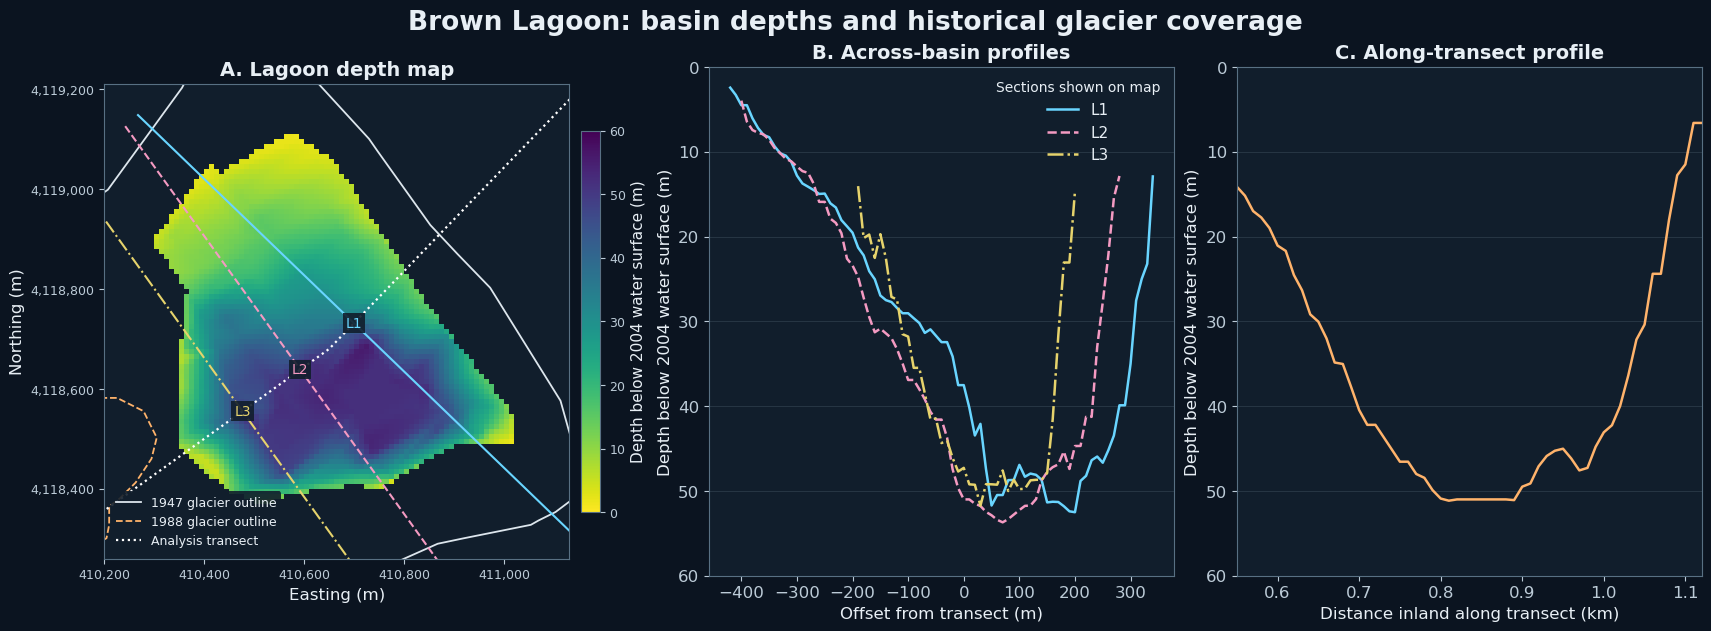

In [16]:
## Measure the survey-covered lagoon basin and its overlap with historical ice ##

with rasterio.open(bathy_path) as src:
    depth = src.read(1, masked = True).astype(float).filled(np.nan)
    bathy_transform, bathy_bounds, bathy_crs = src.transform, src.bounds, src.crs
    pixel_area = abs(src.transform.a * src.transform.e - src.transform.b * src.transform.d)

supported = np.isfinite(depth) & (depth >= 0)
basin_summary = pd.DataFrame([dict(depth_threshold_m = threshold,
    supported_area_at_least_depth_km2 = np.count_nonzero(
        supported & (depth >= threshold)) * pixel_area / 1e6)
    for threshold in [0, 10, 20, 30, 40, 50]])

overlap_rows = []
for year in years:
    footprint = gpd.GeoSeries([get_outline('Brown', year)],
        crs = extents.crs).to_crs(bathy_crs).iloc[0]
    inside = geometry_mask([footprint], out_shape = depth.shape,
        transform = bathy_transform, invert = True)
    overlap_rows.append(dict(year = year,
        supported_basin_within_outline_km2 = (inside & supported).sum() * pixel_area / 1e6,
        supported_depth_ge_30m_within_outline_km2 = (
            inside & supported & (depth >= 30)).sum() * pixel_area / 1e6))

basin_overlap = pd.DataFrame(overlap_rows)
basin_summary.to_csv(synthesis_dir / 'Brown_supported_basin_depth_areas.csv', index = False)
basin_overlap.to_csv(synthesis_dir / 'Brown_basin_historical_overlap.csv', index = False)

line = transects['Brown']
lagoon_stations = np.arange(0, line.length, 10)
lagoon_xy = transect_xy(line, lagoon_stations, [0])[:, 0]
lagoon_depth, _ = sample_raster(bathy_path, lagoon_xy)
lagoon_profile = pd.DataFrame({'distance_m': lagoon_stations, 'E': lagoon_xy[:, 0],
    'N': lagoon_xy[:, 1], 'depth_m': lagoon_depth})
lagoon_profile['approx_bed_elevation_m'] = settings['assumed_water_level_m'] - lagoon_depth
lagoon_profile.to_csv(synthesis_dir / 'Brown_lagoon_long_profile.csv', index = False)

valid_stations = lagoon_stations[np.isfinite(lagoon_depth)]
if not len(valid_stations):
    raise ValueError('Brown transect misses bathymetric support; adjust its lagoon vertices.')

section_stations = np.quantile(valid_stations, [0.25, 0.5, 0.75])
cross_sections = []
for number, station in enumerate(section_stations, 1):
    offsets = np.arange(-600, 601, 10)
    xy = transect_xy(line, [station], offsets)[0]
    values, _ = sample_raster(bathy_path, xy)
    cross_sections.append(pd.DataFrame({'section': f'L{number}', 'distance_m': station,
        'offset_m': offsets, 'E': xy[:, 0], 'N': xy[:, 1], 'depth_m': values}))

lagoon_cross_sections = pd.concat(cross_sections, ignore_index = True)
lagoon_cross_sections.to_csv(synthesis_dir / 'Brown_lagoon_cross_sections.csv', index = False)

# Keep the depth map and both profile views together under one figure title.
fig, axes = plt.subplots(1, 3, figsize = (17, 6.2), layout = 'constrained')
fig.suptitle('Brown Lagoon: basin depths and historical glacier coverage',
    fontsize = 19, fontweight = 'semibold')

# Blank cells remain blank: the raster covers only the retained survey interpolation.
image = axes[0].imshow(np.ma.masked_invalid(depth), origin = 'upper', cmap = 'viridis_r',
    extent = [bathy_bounds.left, bathy_bounds.right, bathy_bounds.bottom, bathy_bounds.top],
    vmin = 0, vmax = 60, interpolation = 'nearest')

# Draw dated ice boundaries for context, rather than treating them as lagoon shorelines.
for year, colour, style in [(1947, '#DDE6ED', '-'), (1988, '#FFB36B', '--')]:
    extents.loc[extents.name_1.eq('Brown') & extents.year.eq(year)].boundary.plot(
        ax = axes[0], color = colour, linestyle = style, linewidth = 1.3)
axes[0].plot(*line.xy, ':', color = 'white', linewidth = 1.6)

# Match each cross-section between the map and profile panel using colour and line style.
section_styles = {'L1': ('#69D5FF', '-'), 'L2': ('#F49AC2', '--'),
    'L3': ('#E6D36C', '-.')}
for label, part in lagoon_cross_sections.groupby('section'):
    colour, style = section_styles[label]
    axes[0].plot(part.E, part.N, color = colour, linestyle = style, linewidth = 1.5)
    centre = part.loc[part.offset_m.eq(0)].iloc[0]
    axes[0].text(centre.E, centre.N, label, fontsize = 10, color = colour,
        ha = 'center', va = 'center', zorder = 5,
        bbox = dict(facecolor = '#111E2C', edgecolor = 'none', alpha = 0.9, pad = 2))
    axes[1].plot(part.offset_m, part.depth_m, color = colour, linestyle = style,
        linewidth = 1.8, label = label)

# Limit the map to the surveyed neighbourhood and label the projected coordinates.
axes[0].set(xlim = (bathy_bounds.left - 100, bathy_bounds.right + 100),
    ylim = (bathy_bounds.bottom - 100, bathy_bounds.top + 100),
    title = 'A. Lagoon depth map', xlabel = 'Easting (m)', ylabel = 'Northing (m)',
    aspect = 'equal')
for axis in [axes[0].xaxis, axes[0].yaxis]:
    axis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:,.0f}'))
axes[0].tick_params(labelsize = 9)

map_handles = [Line2D([0], [0], color = '#DDE6ED', linewidth = 1.3,
    label = '1947 glacier outline'),
    Line2D([0], [0], color = '#FFB36B', linestyle = '--', linewidth = 1.3,
        label = '1988 glacier outline'),
    Line2D([0], [0], color = 'white', linestyle = ':', linewidth = 1.6,
        label = 'Analysis transect')]
axes[0].legend(handles = map_handles, loc = 'lower left', fontsize = 9,
    frameon = True, facecolor = '#111E2C', edgecolor = 'none', framealpha = 0.9)

colourbar = fig.colorbar(image, ax = axes[0], shrink = 0.75, pad = 0.025,
    ticks = np.arange(0, 61, 10))
colourbar.set_label('Depth below 2004 water surface (m)', fontsize = 11)
colourbar.ax.tick_params(labelsize = 9)

# Plot depth increasing downward; zero offset is where each cut crosses the transect.
axes[1].set(title = 'B. Across-basin profiles', xlabel = 'Offset from transect (m)',
    ylabel = 'Depth below 2004 water surface (m)', ylim = (60, 0))
axes[1].legend(title = 'Sections shown on map', fontsize = 11, title_fontsize = 10)

# The distance axis keeps the seaward origin used by the other transect figures.
axes[2].plot(lagoon_stations / 1000, lagoon_depth, color = colours['Brown'], linewidth = 1.8)
axes[2].set(title = 'C. Along-transect profile', xlabel = 'Distance inland along transect (km)',
    ylabel = 'Depth below 2004 water surface (m)',
    xlim = (valid_stations.min() / 1000, valid_stations.max() / 1000), ylim = (60, 0))
for ax in axes[1:]:
    ax.grid(axis = 'y')

# The existing CSV exports retain the numerical tables for the appendix.
save_figure(fig, '05a_Brown_basin_geometry')

*Figure. Brown Lagoon basin geometry reconstructed from the 2004 depth soundings. **(A)** Interpolated depths, the main analysis transect, cross-sections L1–L3 and portions of the 1947 and 1988 glacier outlines. Blank areas have no retained depth estimate. **(B)** Depth profiles across the basin, with colours and line styles matching the mapped sections; zero offset marks the main transect. **(C)** Depth along the main transect, measured inland from its seaward origin. Depth increases downward in both profile panels. All depths are relative to the 2004 survey water surface. Profile endpoints and raster boundaries do not establish lagoon shorelines.*

### Results and interpretation

#### A deep basin within the surveyed area

The reconstructed basin contains a deep central area with shallower flanks. The along-transect profile reaches approximately **50 m depth** before becoming shallower inland. The three cross-sections also intersect deep water, with deepest portions around **49–54 m** and different flank gradients.

The reconstruction covers **0.3301 km²**. Of that area, **0.1519 km²—about 46%—is at least 30 m deep**, while **0.0474 km²—about 14%—is at least 50 m deep**. Deep water therefore occupies a substantial part of the reconstructed area. These proportions describe the retained interpolation, rather than the entire lagoon.

#### Historical ice occupied this basin footprint

The entire reconstructed basin footprint lies inside the **1947 glacier outline**, with no overlap with the **1988, 2014, 2019 or 2026 outlines**. The mapped ice therefore withdrew from this surveyed area between the 1947 and 1988 inventories.

This is consistent with Tielidze et al. (2025), who describe Brown’s early retreat into a developing proglacial lake between 1947 and 1988, followed by land termination. Our overlap calculation provides spatial evidence for withdrawal from the surveyed basin; it does not independently date the formation of the complete lagoon or the end of all glacier–water contact.

#### What the basin geometry establishes

The soundings demonstrate a deep water-filled depression in an area formerly occupied by mapped glacier ice. However, the available reconstruction does not establish the complete basin boundary or the elevation of an outlet sill. Those relationships are needed to characterise its full overdeepened geometry and assess any potential stabilising control.

### References for this section

- Allison, I., & Thost, D. E. (2010). *Heard Island glacier fluctuations and climatic change – 2003/04 fieldwork* (Version 1) [Data set]. Australian Antarctic Data Centre. https://doi.org/10.4225/15/574BBEA0D74B7
- SciPy community. (n.d.). *LinearNDInterpolator*. SciPy documentation. https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.LinearNDInterpolator.html
- Tielidze, L. G., Mackintosh, A. N., & Yang, W. (2025). Glacier inventories reveal an acceleration of Heard Island glacier loss over recent decades. *The Cryosphere, 19*, 2677–2694. https://doi.org/10.5194/tc-19-2677-2025

### From the lagoon basin to the inland glacier bed

This figure places the surveyed lagoon basin and inland glacier terrain along the same transect. An enlarged lagoon inset shows differences that are difficult to see beside the much higher inland elevations.

#### Converting lagoon depth to bed elevation

The lagoon soundings measure positive depth below the 2004 survey water surface. To display the basin on an approximate elevation axis, we calculate:

\[
z_{\mathrm{bed}} = W - d,
\]

where \(W\) is the assumed water-surface elevation and \(d\) is the measured or interpolated depth. We compare assumed water levels of **0, 2 and 5 m**. Changing \(W\) shifts the entire lagoon profile vertically without changing its shape. These levels are illustrative scenarios, not observations or uncertainty bounds.

#### Keeping the evidence distinct

The surface curve comes from the **2002 DEM**. The modelled bed combines that surface with estimated ice thickness and is restricted to the **2019 glacier footprint**. It is not a measurement of the 2026 bed or ice thickness.

Crosses show sampled elevations from the interpreted **2000 radar-bed sections** retained after the archive geometry checks in notebook 06. Samples within **100 m** of the transect are projected onto it for display; their lateral distances remain in the exported table.

The profiles retain their original gaps. Nearby radar sections provide local context but do not establish a continuous bed between the lagoon and glacier.

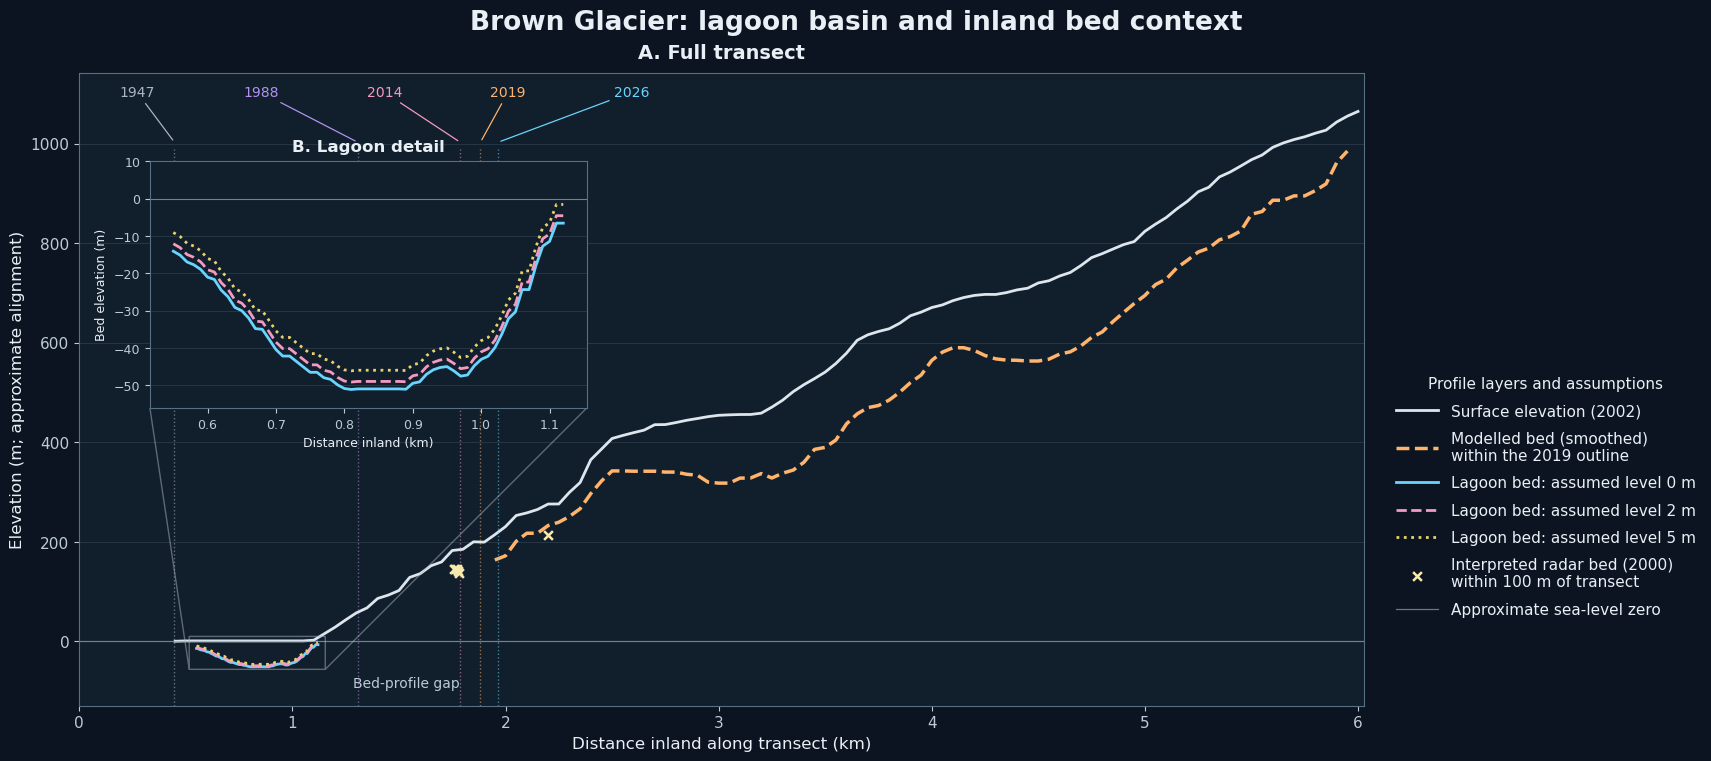

In [17]:
## Compare the lagoon and glacier bed under alternative water levels ##

p = profiles['Brown']

# Retain the selected water level and the two illustrative alternatives, without duplicates.
water_levels = list(dict.fromkeys([settings['assumed_water_level_m'], 2.0, 5.0]))
water_styles = [('#69D5FF', '-'), ('#F49AC2', '--'), ('#E6D36C', ':')]

# Use only the archived radar sections accepted for the primary comparisons in notebook 06.
radar_projection = pd.read_csv(field_dir / 'Brown_interpreted_bed_samples.csv')
radar_projection = radar_projection.loc[
    radar_projection.use_primary_metrics.astype(str).str.lower().eq('true')].copy()

# Project each radar sample onto the transect and retain its actual sideways distance.
radar_projection['distance_m'] = [transects['Brown'].project(Point(e, n))
    for e, n in zip(radar_projection.E, radar_projection.N)]
radar_projection['offset_from_transect_m'] = [transects['Brown'].distance(Point(e, n))
    for e, n in zip(radar_projection.E, radar_projection.N)]
radar_projection.to_csv(synthesis_dir / 'Brown_radar_transect_context.csv', index = False)
nearby = radar_projection.loc[radar_projection.offset_from_transect_m <= 100]

# Keep the complete profile large and reserve room on the right for the legend.
fig, ax = plt.subplots(figsize = (17, 7.5), layout = 'constrained')
fig.suptitle('Brown Glacier: lagoon basin and inland bed context',
    fontsize = 19, fontweight = 'semibold')
ax.set_title('A. Full transect', fontsize = 14, pad = 10)
ax.plot(p.distance_m / 1000, p.surface_m, color = '#DDE6ED', linewidth = 2,
    label = 'Surface elevation (2002)')
ax.plot(p.distance_m / 1000, p.bed_smooth_m, '--', color = colours['Brown'],
    linewidth = 2.5, label = 'Modelled bed (smoothed)\nwithin the 2019 outline')

# Convert positive water depth to bed elevation: assumed water level minus depth.
# NaNs remain in each line, preserving gaps in the original depth coverage.
for water_level, (colour, style) in zip(water_levels, water_styles):
    ax.plot(lagoon_profile.distance_m / 1000, water_level - lagoon_profile.depth_m,
        color = colour, linestyle = style, linewidth = 2,
        label = f'Lagoon bed: assumed level {water_level:g} m')

# These are samples of interpreted radar sections near the transect, not points on it.
if len(nearby):
    ax.scatter(nearby.distance_m / 1000, nearby.bed_asl_m, s = 40, marker = 'x',
        linewidths = 1.8, color = '#F8E9AE', zorder = 5,
        label = 'Interpreted radar bed (2000)\nwithin 100 m of transect')

# Spread the date labels across the upper-left edge to separate the recent fronts.
front_colours = {1947: '#AAB4C3', 1988: '#B292EE', 2014: '#F49AC2',
    2019: '#FFB36B', 2026: '#69D5FF'}
fronts = termini.loc[termini.name_1.eq('Brown')
    & np.isfinite(termini.front_distance_m)].sort_values('front_distance_m')

for row, label_x in zip(fronts.itertuples(), np.linspace(0.045, 0.43, len(fronts))):
    front_x = row.front_distance_m / 1000
    colour = front_colours[row.year]
    ax.axvline(front_x, ymax = 0.88, color = colour, linestyle = ':',
        alpha = 0.55, linewidth = 1)
    ax.annotate(str(row.year), xy = (front_x, 0.89),
        xycoords = ax.get_xaxis_transform(), xytext = (label_x, 0.98),
        textcoords = 'axes fraction', ha = 'center', va = 'top',
        fontsize = 10, color = colour,
        arrowprops = dict(arrowstyle = '-', color = colour, lw = 0.9),
        bbox = dict(facecolor = '#111E2C', edgecolor = 'none', pad = 1.5))

# Zero is an approximate elevation reference, rather than an observed lagoon level.
ax.axhline(0, color = '#8EA4B6', linewidth = 0.9, alpha = 0.7,
    label = 'Approximate sea-level zero')
ax.set(xlabel = 'Distance inland along transect (km)',
    ylabel = 'Elevation (m; approximate alignment)',
    xlim = (0, transects['Brown'].length / 1000))
ax.grid(axis = 'y', alpha = 0.15)
ax.tick_params(labelsize = 11)
ax.margins(y = 0.07)

# Enlarge the lagoon vertically and horizontally so the scenario offsets are visible.
lagoon_valid = np.isfinite(lagoon_profile.distance_m) & np.isfinite(lagoon_profile.depth_m)
lagoon_x = lagoon_profile.loc[lagoon_valid, 'distance_m'].to_numpy() / 1000
lagoon_depth_values = lagoon_profile.loc[lagoon_valid, 'depth_m'].to_numpy()
zoom_padding = max(0.025, 0.06 * np.ptp(lagoon_x))

zoom = ax.inset_axes([0.055, 0.47, 0.34, 0.39], zorder = 10)
for water_level, (colour, style) in zip(water_levels, water_styles):
    zoom.plot(lagoon_profile.distance_m / 1000, water_level - lagoon_profile.depth_m,
        color = colour, linestyle = style, linewidth = 2)

zoom.axhline(0, color = '#8EA4B6', linewidth = 0.8, alpha = 0.7)
zoom.set(xlim = (lagoon_x.min() - zoom_padding, lagoon_x.max() + zoom_padding),
    ylim = (min(water_levels) - lagoon_depth_values.max() - 5,
        max(water_levels) + 5))
zoom.set_title('B. Lagoon detail', fontsize = 12, pad = 7)
zoom.set_xlabel('Distance inland (km)', fontsize = 9)
zoom.set_ylabel('Bed elevation (m)', fontsize = 9)
zoom.tick_params(labelsize = 9)
zoom.grid(axis = 'y', alpha = 0.15)
ax.indicate_inset_zoom(zoom, edgecolor = '#AAB4C3', alpha = 0.5)

# Mark the interval between the lagoon coverage and the first modelled-bed sample.
model_x = p.loc[np.isfinite(p.bed_smooth_m), 'distance_m'].to_numpy() / 1000
if len(model_x) and model_x.min() > lagoon_x.max():
    gap_x = (lagoon_x.max() + model_x.min()) / 2
    ax.text(gap_x, 0.025, 'Bed-profile gap', transform = ax.get_xaxis_transform(),
        ha = 'center', va = 'bottom', fontsize = 10, color = '#BCCBD7')

# Place the larger legend outside the right edge, centred at one-third of plot height.
ax.legend(loc = 'center left', bbox_to_anchor = (1.02, 0.33), fontsize = 11,
    title = 'Profile layers and assumptions', title_fontsize = 11,
    handlelength = 2.8, labelspacing = 0.8, borderaxespad = 0)

save_figure(fig, '05b_Brown_basin_to_glacier')

Figure. Brown Lagoon and inland glacier terrain along the analysis transect. (A) The full profile combines 2002 surface elevations, the smoothed modelled bed within the 2019 glacier outline, and lagoon-bed elevations calculated using assumed water levels of 0, 2 and 5 m. Vertical markers locate the dated glacier fronts. Crosses represent sampled elevations from interpreted 2000 radar-bed sections within 100 m of the transect, projected onto it for context. They are not independent point soundings or exact measurements on the transect. (B) Enlarged lagoon profiles show the vertical separation between scenarios. The horizontal zero line is an approximate elevation reference. Gaps remain between datasets; the figure does not reconstruct a continuous connecting bed.

### Results and interpretation

#### Water-level assumptions shift the lagoon profile

The three assumed water levels move the lagoon-bed profile vertically by up to **5 m**, while leaving its shape unchanged. Under all three scenarios, its deep central portion remains below approximate sea-level zero, while the modelled inland bed rises to much higher elevations.

These particular offsets therefore leave the broad basin-to-inland contrast intact. They illustrate the effect of an assumed water level without establishing the true level or bounding the uncertainty in the datasets’ vertical alignment.

#### The connecting terrain remains unresolved

A gap separates the lagoon depth profile from the modelled bed within the 2019 glacier footprint. Nearby interpreted radar sections add local bed-elevation information, but their limited extent and lateral offsets do not establish a connecting sill or continuous bed.

The separate archived-section comparisons in notebook 06 also show uneven agreement with the model. Bed-elevation RMSE is approximately **62.1 m at BG30**, **25.5 m at BG45** and **10.5 m at BG50**, with each comparison covering only **two or three distinct model cells**. These are local comparisons, rather than validation of the full glacier bed or uncertainty bounds for this plotted profile.

#### Changing terminus conditions provide a plausible explanation

The historical outlines place Brown’s withdrawal from the surveyed basin between 1947 and 1988, followed by further retreat inland. Tielidze et al. (2025) similarly describe an early lake-associated retreat phase and subsequent land termination.

This offers a plausible change in the processes acting at the glacier front. Contact with water permits both mechanical calving and melting below the water surface; withdrawal onto land removes those direct losses from the front where water contact ceases (Truffer & Motyka, 2016). The thickness estimates underlying our modelled bed provide terrain context for this interpretation, rather than direct observations of those processes (Millan et al., 2022).

Our evidence does not identify seawater intrusion as the initiating cause or quantify historical calving and water-driven melting. Testing that explanation requires the basin–outlet geometry, consistently referenced water levels, water temperature and salinity, and observations of glacier–water contact.

### References for this section

- Allison, I., & Thost, D. E. (2010). *Heard Island glacier fluctuations and climatic change – 2003/04 fieldwork* (Version 1) [Data set]. Australian Antarctic Data Centre. https://doi.org/10.4225/15/574BBEA0D74B7
- Milbert, D. G., & Smith, D. A. (n.d.). *Converting GPS height into NAVD88 elevation with the GEOID96 geoid height model*. National Geodetic Survey, NOAA. https://www.ngs.noaa.gov/PUBS_LIB/gislis96.html
- Millan, R., Mouginot, J., Rabatel, A., & Morlighem, M. (2022). Ice velocity and thickness of the world’s glaciers. *Nature Geoscience, 15*, 124–129. https://doi.org/10.1038/s41561-021-00885-z
- Tielidze, L. G., Mackintosh, A. N., & Yang, W. (2025). Glacier inventories reveal an acceleration of Heard Island glacier loss over recent decades. *The Cryosphere, 19*, 2677–2694. https://doi.org/10.5194/tc-19-2677-2025
- Truffer, M., & Motyka, R. J. (2016). Where glaciers meet water: Subaqueous melt and its relevance to glaciers in various settings. *Reviews of Geophysics, 54*(1), 220–239. https://doi.org/10.1002/2015RG000494

## 7. Bring the evidence together

The comparison below brings together historical area loss, recent front retreat, lower-glacier flow and summer surface exposure. These measurements describe different aspects of glacier change and should be interpreted together.

Annual percentage area loss uses the glacier area at the beginning of each interval. Front retreat measures displacement along the selected transect. The velocity measurements describe 2016–2022 conditions within the 2014 glacier outlines.

A compact table is displayed here. The complete numerical comparison is saved as `focus_evidence_summary.csv` for the appendix, alongside the detailed outputs from each analysis.

In [18]:
## Assemble the final evidence table ##

summary = comparison[[
    "name_1", "median_speed_m_yr", "coverage_percent",
    "lower_third_speed_m_yr", "lower_third_coverage_percent",
    "thickness_median_m", "mean_reported_thickness_error_m"
]].set_index("name_1").reindex(names)

summary = summary.rename(columns = {
    "thickness_median_m": "modelled_thickness_median_m"})

summary["area_loss_1947_2026_percent"] = (
    100 * (1 - area.loc[2026] / area.loc[1947]))

summary["annual_loss_2019_2026_percent"] = (
    retreat.loc[retreat.start_year.eq(2019)]
    .set_index("name_1").annual_loss_percent)

summary["annual_loss_2014_2019_percent"] = (
    retreat.loc[retreat.start_year.eq(2014)]
    .set_index("name_1").annual_loss_percent)

summary["lower_2014_footprint_surface_slope_deg"] = (
    terrain_full.loc[terrain_full.elevation_band.eq("lower")]
    .set_index("name_1").slope_median_deg)

summary['recent_transect_retreat_m_yr'] = transect_retreat.loc[
    transect_retreat.start_year.eq(2019)].set_index('name_1').transect_retreat_m_yr

summary['summer_incidence_2014_footprint'] = exposure.loc[
    exposure.support.eq('2014 footprint')].set_index('name_1').median_summer_incidence

summary['screened_candidate_bed_highs'] = candidates.groupby('name_1').size().reindex(
    summary.index, fill_value = 0)

summary.to_csv(synthesis_dir / 'focus_evidence_summary.csv')

metadata = dict(
    study_glaciers = names,
    outline_years = years,
    primary_comparison = (
        "Descriptive comparison of Brown and Stephenson; "
        "no glacier-population inference"),
    low_elevation_thresholds_m = thresholds,
    low_elevation_cell_run = not low_area_history.empty,
    limitations = [
        "Unequal intervals; annual percentage uses interval-start area",
        "1947 historical outlines include pre-year source records",
        "No advance and unchanged ice above 1000 m are imposed for recent outlines",
        "2002 elevations are fixed; threshold areas are not historical hypsometry or AAR",
        "2014 velocity footprint differs from 2019 model reporting footprint",
        "Pair-level velocity errors are not confidence intervals of the final median",
        "Mapped Snow/Ice does not identify underlying lithology",
        "Radar checks are local; BG35 excluded from primary metrics",
        "2004 lagoon depths use the water surface, not a shared bed-elevation datum"])

(synthesis_dir / "synthesis_metadata.json").write_text(
    json.dumps(metadata, indent = 2), encoding = "utf-8")

# Show a compact comparison; the full numerical table is already exported above.
# Include velocity coverage alongside speed so the unequal sampling remains visible.
display_rows = [
    ('area_loss_1947_2026_percent', 'Area loss, 1947–2026 (%)', 2),
    ('annual_loss_2019_2026_percent', 'Annual area loss, 2019–2026 (%/year)', 2),
    ('recent_transect_retreat_m_yr', 'Front retreat, 2019–2026 (m/year)', 2),
    ('lower_third_speed_m_yr', 'Lower-third median ice speed (m/year)', 2),
    ('lower_third_coverage_percent', 'Lower-third velocity coverage (%)', 2),
    ('summer_incidence_2014_footprint', 'Summer exposure index', 3)]

# Format only this display copy.
# Retain full precision and the existing column names in the exported summary.
evidence_display = pd.DataFrame({label: [
    f'{summary.loc[name, key]:.{decimals}f}' for name in names]
    for key, label, decimals in display_rows}, index = names).T

evidence_display.index.name = 'Comparison'
evidence_display.columns.name = 'Glacier'
display(evidence_display)

Glacier,Brown,Stephenson
Comparison,,
"Area loss, 1947–2026 (%)",40.44,68.49
"Annual area loss, 2019–2026 (%/year)",0.61,0.40
"Front retreat, 2019–2026 (m/year)",11.90,103.48
Lower-third median ice speed (m/year),39.57,266.52
Lower-third velocity coverage (%),38.46,85.41
Summer exposure index,1.028,0.983


**Table caption.** Selected evidence comparing Brown and Stephenson glaciers. Annual percentage area loss uses interval-start area, while front retreat measures displacement along the selected transect. Ice speed describes 2016–2022 observations within the 2014 outlines. The lower third is the lowest of three equal elevation-range bands within each glacier footprint, rather than one third of its area. A summer exposure index of 1 represents a horizontal surface; the index describes surface orientation relative to the sun, rather than measured energy or melt.

In [20]:
## Save analysis scope and technical references ##

# Retain the settings, geometry and interpretation limits with the exported results.
analysis_metadata = dict(
    settings = settings,
    transect_vertices_utm43s = transect_vertices,
    transect_scope = 'Brown lower trunk; Stephenson northern surviving tongue and former southern tongue',
    transect_front = 'Seaward end of the line segment connected to the inland endpoint; detached segments excluded',
    bed_scope = 'Modelled bed within the 2019 outline; missing profile values retained',
    width_scope = 'Connected mapped ice-polygon width, not surveyed bedrock valley width',
    candidate_scope = 'Potential bed highs screened descriptively; persistence counts are not probabilities',
    solar_inputs = '2002 DEM surface slope and aspect, aligned to the 120 m grid; aspect averaged using sine and cosine',
    solar_scope = 'Four representative November–February days; no atmosphere, horizon shading, albedo or melt model',
    water_level_scope = 'Assumed reference; 0, 2 and 5 m examples are scenarios, not confidence bounds',
    chronology = '2002 surface, Millan modelled thickness, 2000 radar, 2004 bathymetry and 2016–2022 velocity',
    dependence = 'Millan thickness uses velocity; model-bed/flow agreement is not independent validation',
    bathy_scope = 'Survey-covered 2004 reconstruction; historical-outline overlap does not reconstruct historical depth')

# Collect method sources here for the later book bibliography.
# These describe algorithms and principles; our settings remain project choices.
analysis_metadata['technical_references'] = {
    'surface_slope_aspect':
        'https://gdal.org/en/stable/programs/gdaldem.html',
    'circular_aspect_averaging':
        'https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.circmean.html',
    'sentinel_1_velocity_processing':
        'https://doi.org/10.5194/essd-14-5111-2022',
    'ice_thickness_model':
        'https://doi.org/10.1038/s41561-021-00885-z',
    'terminus_measurement_methods':
        'https://doi.org/10.3189/2014JoG13J061',
    'bed_high_screening':
        'https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html',
    'lagoon_interpolation':
        'https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.LinearNDInterpolator.html',
    'spatial_block_validation':
        'https://doi.org/10.1111/ecog.02881',
    'solar_declination':
        'https://doi.org/10.1016/0038-092X(69)90047-4',
    'solar_incidence_geometry':
        'https://doi.org/10.1016/B978-0-12-373750-2.X5001-0',
    'solar_vector_projection':
        'https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.irradiance.aoi_projection.html',
    'height_reference_conversion':
        'https://www.ngs.noaa.gov/PUBS_LIB/gislis96.html',
    'glacier_water_contact_processes':
        'https://doi.org/10.1002/2015RG000494'}

# Update the existing metadata file without changing the numerical result tables.
(synthesis_dir / 'geomorphology_analysis_metadata.json').write_text(
    json.dumps(analysis_metadata, indent = 2), encoding = 'utf-8')

3767

### Results and interpretation

#### Historical loss and recent change

Stephenson lost **68.49%** of its mapped area between 1947 and 2026, compared with **40.44%** at Brown. Both glaciers experienced their greatest annualised area loss during 1988–2014.

Their recent changes depend on the measurement used. At Brown, annual percentage area loss increased from **0.42% during 2014–2019 to 0.61% during 2019–2026**, while front retreat slowed from **19.09 to 11.90 m/year**. Stephenson showed the opposite pattern: annual percentage area loss decreased from **1.84% to 0.40%**, while front retreat accelerated from **61.31 to 103.48 m/year**.

Stephenson also continued to lose more absolute area during 2019–2026: approximately **0.033 km²/year**, compared with **0.020 km²/year** at Brown. Its reduced percentage area-loss rate therefore does not indicate a slowdown in every measure of retreat.

#### Changing glacier geometry and water contact

Stephenson has lost much of its formerly broad, low-elevation tongue. As retreat changes the width and position of the remaining front, a given distance of retreat can remove a different amount of glacier area. This helps explain why front displacement and area loss need not change together.

At Brown, the surveyed lagoon basin occupies terrain within the 1947 glacier outline but outside every mapped outline from 1988 onwards. This agrees with the early lake development and subsequent land-terminating retreat described by Tielidze et al. (2025). The survey overlap establishes when this particular basin area had been vacated between mapped dates; it does not establish the formation date of the entire lagoon or the end of all glacier–water contact.

Water contact can permit calving and melting below the water surface, potentially changing glacier retreat behaviour (Truffer & Motyka, 2016). The present analysis documents the basin geometry and retreat history, but does not measure the contribution of either process at Brown or Stephenson.

#### Flow and modelled bed geometry

Median ice speed in the lowest elevation band was **39.57 m/year at Brown** and **266.52 m/year at Stephenson**. However, valid velocity measurements covered only **38.46%** of Brown’s lower band, compared with **85.41%** at Stephenson. The contrast describes the observed cells; Brown’s sparse coverage limits its representation of the whole lower glacier. These measurements also precede the 2026 outlines.

Median modelled thickness differed by approximately **11 m**. Reported thickness errors and the spatially variable disagreement with historical radar give little basis for treating that difference as a strong explanation of contrasting retreat. The mean pixel errors are not confidence intervals for the glacier-wide medians.

The modelled bed highs identify possible local controls for further investigation. Sensitivity tests and cross-sections do not establish valley-spanning barriers or confirmed pinning points. Furthermore, velocity contributes to the Millan thickness estimates, so agreement between modelled bed geometry and ice flow is not independent validation (Millan et al., 2022).

#### Geology and surface exposure

The geological mapping describes exposed deposits and mapped snow or ice, but does not establish the material beneath the remaining glaciers. It therefore cannot demonstrate that contrasting bedrock or sediment erodibility caused their different retreat histories.

Brown’s median summer exposure index was slightly higher than Stephenson’s (**1.028 versus 0.983**), despite Stephenson’s greater historical loss. This modest geometric contrast does not explain the observed difference. Clouds, terrain shadows, surface reflectivity and snow conditions were excluded; shading can substantially modify direct solar radiation in glacier terrain (Olson & Rupper, 2019).

#### What the combined evidence supports

The observations support glacier geometry and changing terminus setting as plausible influences on how retreat has progressed. They do not isolate the contributions of calving, underwater melting, buried geology or individual bed features.

The strongest findings are the contrasting retreat histories, loss of Stephenson’s broad lower tongue, and Brown’s measured lagoon basin. Modelled bed features and contemporary flow provide additional context and testable hypotheses.

### References for this section

- Lei, Y., Gardner, A. S., & Agram, P. (2022). Processing methodology for the ITS_LIVE Sentinel-1 ice velocity products. *Earth System Science Data, 14*, 5111–5137. https://doi.org/10.5194/essd-14-5111-2022

- Millan, R., Mouginot, J., Rabatel, A., & Morlighem, M. (2022). Ice velocity and thickness of the world’s glaciers. *Nature Geoscience, 15*, 124–129. https://doi.org/10.1038/s41561-021-00885-z

- Olson, M., & Rupper, S. (2019). Impacts of topographic shading on direct solar radiation for valley glaciers in complex topography. *The Cryosphere, 13*, 29–40. https://doi.org/10.5194/tc-13-29-2019

- Tielidze, L. G., Mackintosh, A. N., & Yang, W. (2025). Glacier inventories reveal an acceleration of Heard Island glacier loss over recent decades. *The Cryosphere, 19*, 2677–2694. https://doi.org/10.5194/tc-19-2677-2025

- Truffer, M., & Motyka, R. J. (2016). Where glaciers meet water: Subaqueous melt and its relevance to glaciers in various settings. *Reviews of Geophysics, 54*(1), 220–239. https://doi.org/10.1002/2015RG000494

## 8. Bring the retreat story into one figure

This figure connects three parts of the comparison: the terrain vacated by retreat, the surface and modelled bed along each transect, and the changing rates of area loss and front retreat.

Brown and Stephenson occupy separate columns. Shared scales allow comparison of elevation and retreat rates, while each map has its own scale bar. Numbered transect locations connect the maps to distance along the profiles.

Brown’s lagoon depth is shown separately below the survey water surface. This preserves the measured depth information without requiring an assumed water level to align it with the inland elevation profile.

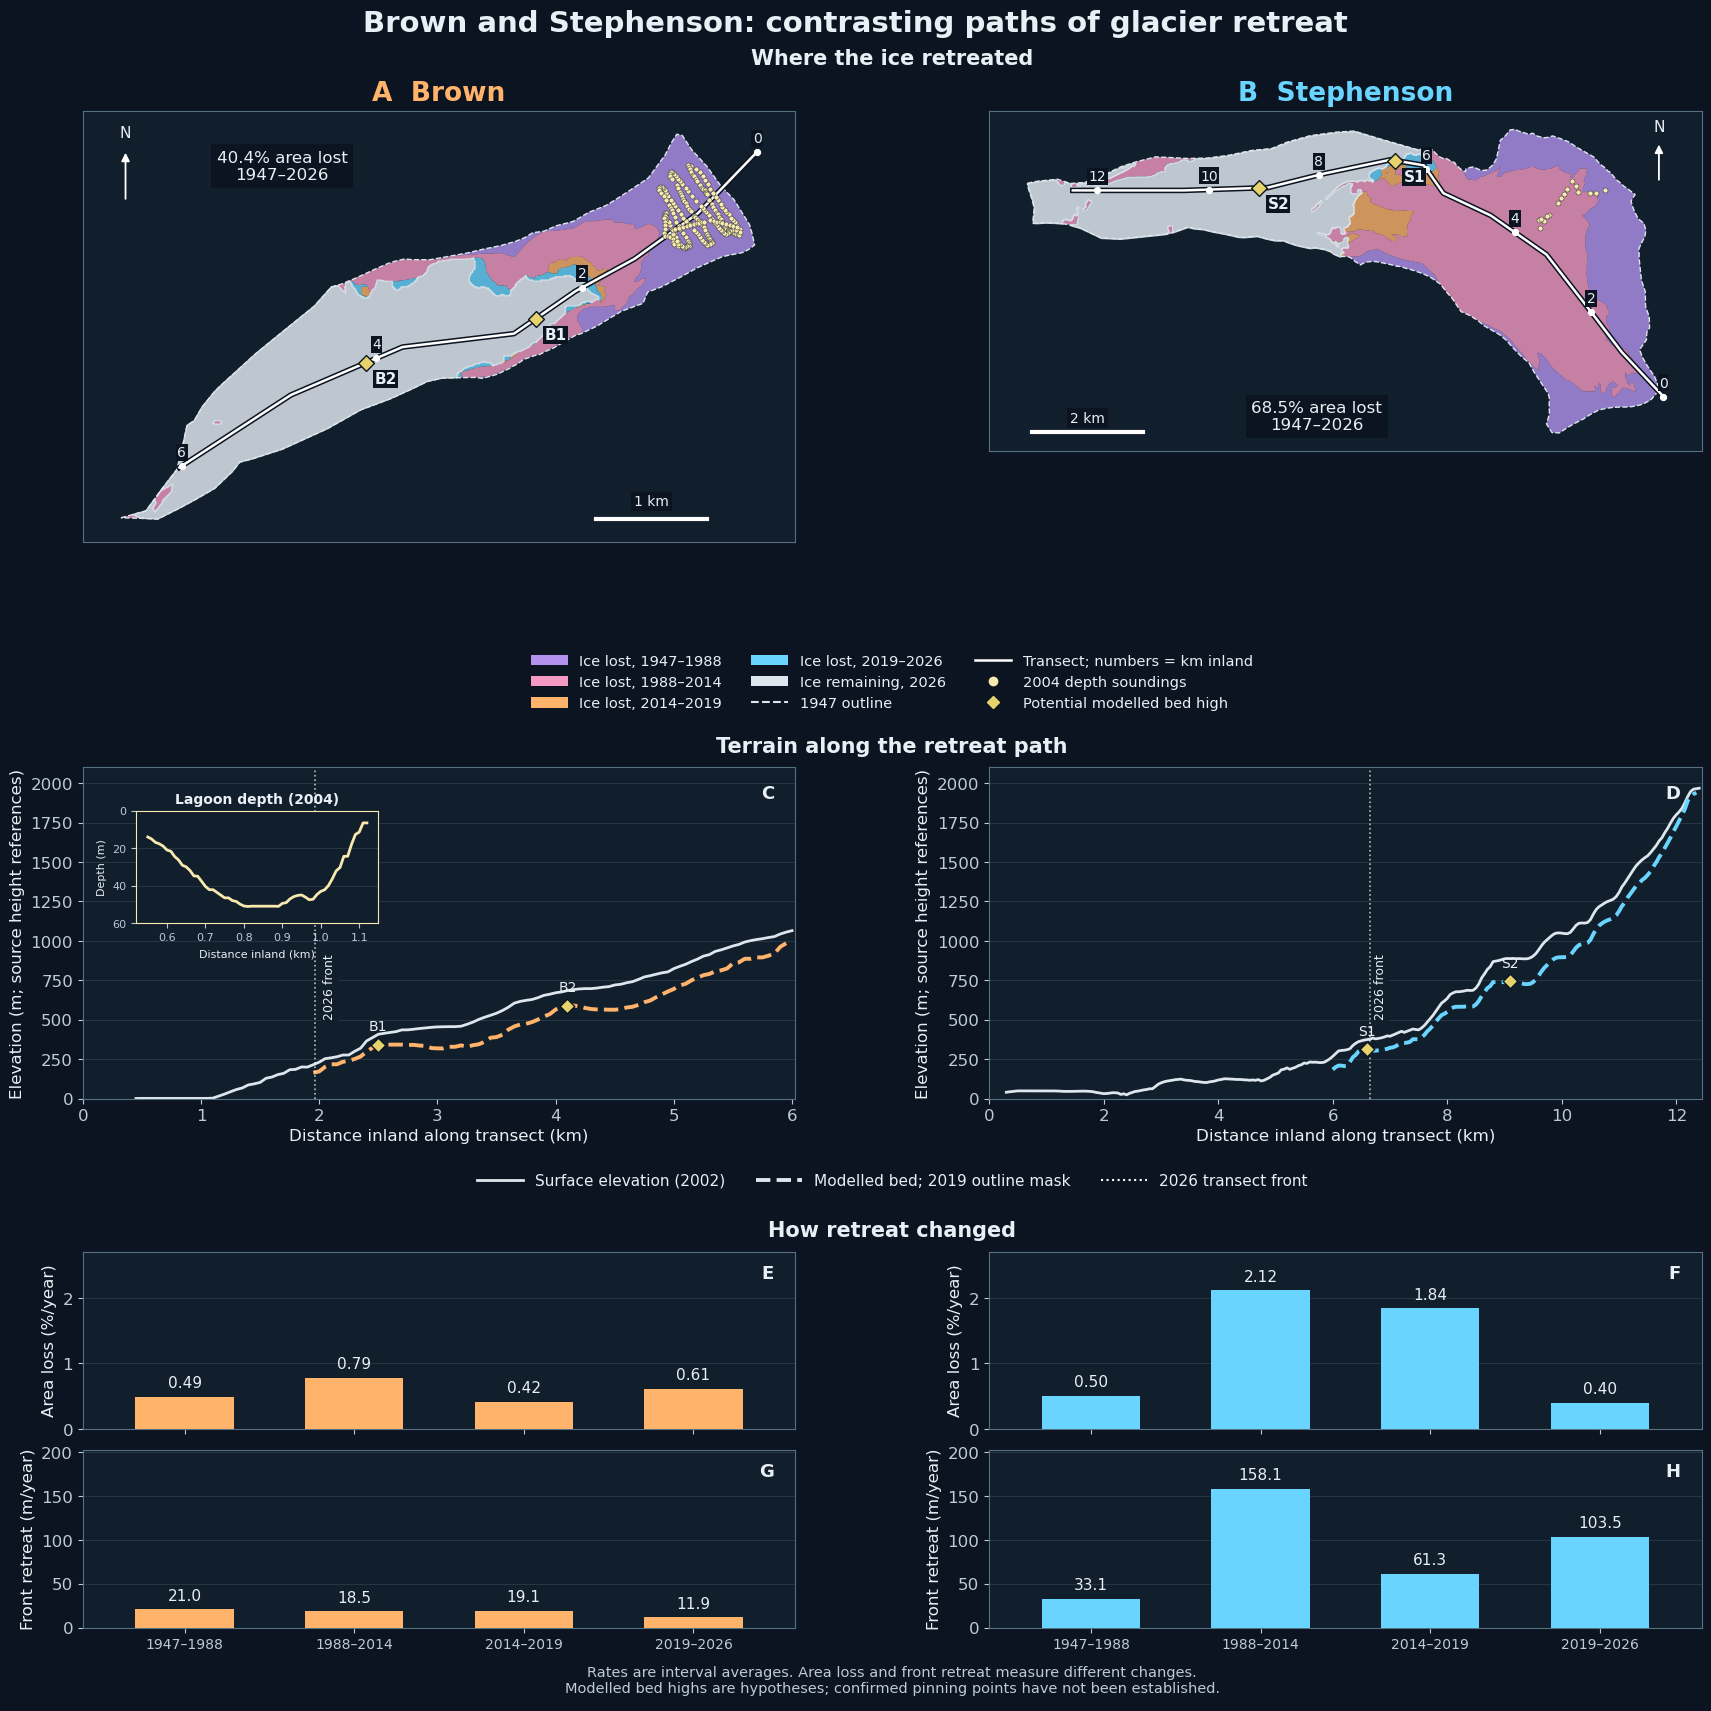

In [22]:
## Build the master synthesis figure ##

# Reuse the completed analyses; this cell changes presentation only.
master_periods = list(zip(years[:-1], years[1:]))
master_labels = [f'{start}–{end}' for start, end in master_periods]
master_stage_colours = ['#B292EE', '#F49AC2', '#FFB36B', '#69D5FF']
master_gold = '#F8E9AE'
master_white = '#DDE6ED'

# Reserve separate rows for shared headings and legends.
fig = plt.figure(figsize = (17, 17), layout = 'constrained')
grid = fig.add_gridspec(10, 2,
    height_ratios = [0.22, 4.4, 0.72, 0.22, 2.8, 0.48, 0.22, 1.5, 1.5, 0.35])
fig.suptitle('Brown and Stephenson: contrasting paths of glacier retreat',
    fontsize = 21, fontweight = 'semibold')

for row, heading in [(0, 'Where the ice retreated'),
        (3, 'Terrain along the retreat path'), (6, 'How retreat changed')]:
    heading_ax = fig.add_subplot(grid[row, :])
    heading_ax.axis('off')
    heading_ax.text(0.5, 0.5, heading, ha = 'center', va = 'center',
        fontsize = 15, fontweight = 'semibold')

map_axes = [fig.add_subplot(grid[1, j]) for j in range(2)]
profile_axes = [fig.add_subplot(grid[4, j]) for j in range(2)]
area_axes = [fig.add_subplot(grid[7, j]) for j in range(2)]
front_axes = [fig.add_subplot(grid[8, j]) for j in range(2)]

# Keep the same elevation and rate scales across the two glaciers.
master_elevations = np.concatenate([
    profiles[name][['surface_m', 'bed_smooth_m']].to_numpy().ravel()
    for name in names])
master_elevations = master_elevations[np.isfinite(master_elevations)]
master_ylim = (min(0, 100 * np.floor(master_elevations.min() / 100)),
    100 * np.ceil(master_elevations.max() / 100) + 100)
master_area_max = retreat.annual_loss_percent.max() * 1.28
master_front_max = transect_retreat.transect_retreat_m_yr.max() * 1.28

for j, name in enumerate(names):
    ax = map_axes[j]

    # Shade the existing mapped loss zones and remaining 2026 footprint.
    for label, colour in zip(master_labels, master_stage_colours):
        part = zones.loc[zones.name_1.eq(name) & zones.zone.eq(label)]
        if len(part) and not part.geometry.is_empty.all():
            part.plot(ax = ax, color = colour, alpha = 0.8,
                edgecolor = 'none', zorder = 1)
    extents.loc[extents.name_1.eq(name) & extents.year.eq(2026)].plot(
        ax = ax, facecolor = master_white, edgecolor = master_white,
        alpha = 0.85, linewidth = 1, zorder = 2)
    extents.loc[extents.name_1.eq(name) & extents.year.eq(1947)].boundary.plot(
        ax = ax, color = master_white, linestyle = '--', linewidth = 1, zorder = 3)

    # Transect numbers link map locations to inland distance in the profiles.
    line = transects[name]
    ax.plot(*line.xy, color = '#0B1420', linewidth = 4, zorder = 4)
    ax.plot(*line.xy, color = 'white', linewidth = 1.8, zorder = 5)
    for distance in np.arange(0, line.length, 2000):
        point = line.interpolate(distance)
        ax.scatter(point.x, point.y, color = 'white', s = 18, zorder = 6)
        ax.annotate(f'{distance / 1000:.0f}', (point.x, point.y),
            xytext = (0, 7), textcoords = 'offset points', ha = 'center',
            fontsize = 10, zorder = 8,
            bbox = dict(facecolor = '#0B1420', edgecolor = 'none', pad = 1))

    # Circles identify field observations; diamonds identify screened model features.
    soundings.loc[soundings.name_1.eq(name)].plot(ax = ax, color = master_gold,
        markersize = 13, edgecolor = '#0B1420', linewidth = 0.3, zorder = 7)
    highs = candidates.loc[candidates.name_1.eq(name)]
    for high in highs.itertuples():
        ax.scatter(high.E, high.N, marker = 'D', s = 65, color = '#E6D36C',
            edgecolor = '#0B1420', linewidth = 1, zorder = 9)
        ax.annotate(high.candidate, (high.E, high.N), xytext = (6, -15),
            textcoords = 'offset points', fontsize = 11, fontweight = 'semibold',
            zorder = 10, bbox = dict(facecolor = '#0B1420', edgecolor = 'none', pad = 1))

    ax.set_title(f'{"AB"[j]}  {name}', color = colours[name], fontsize = 19, pad = 8)
    ax.set_aspect('equal', adjustable = 'box')
    ax.set_anchor('N')
    ax.margins(0.06)
    ax.set(xticks = [], yticks = [])

    # State cumulative loss directly rather than leaving readers to infer it.
    label_x, label_y = (0.28, 0.91) if name == 'Brown' else (0.46, 0.15)
    ax.text(label_x, label_y,
        f'{summary.loc[name, "area_loss_1947_2026_percent"]:.1f}% area lost\n1947–2026',
        transform = ax.transAxes, ha = 'center', va = 'top', fontsize = 12,
        bbox = dict(facecolor = '#0B1420', edgecolor = 'none', pad = 4))

    # Maps use different zooms, so each retains a scale bar and north arrow.
    xmin, xmax = ax.get_xlim()
    bar_m = 1000 if name == 'Brown' else 2000
    bar_x = xmin + (0.72 if name == 'Brown' else 0.06) * (xmax - xmin)
    ax.plot([bar_x, bar_x + bar_m], [0.055, 0.055],
        transform = ax.get_xaxis_transform(), color = 'white', linewidth = 3,
        scalex = False, scaley = False, zorder = 11)
    ax.text(bar_x + bar_m / 2, 0.085, f'{bar_m / 1000:g} km',
        transform = ax.get_xaxis_transform(), ha = 'center', fontsize = 10,
        bbox = dict(facecolor = '#0B1420', edgecolor = 'none', pad = 2))
    north_x = 0.06 if name == 'Brown' else 0.94
    ax.annotate('', xy = (north_x, 0.91), xytext = (north_x, 0.79),
        xycoords = 'axes fraction',
        arrowprops = dict(arrowstyle = '-|>', color = 'white', lw = 1.3))
    ax.text(north_x, 0.94, 'N', transform = ax.transAxes, ha = 'center', fontsize = 11)

    # Preserve missing model samples as gaps.
    ax = profile_axes[j]
    p = profiles[name]
    ax.plot(p.distance_m / 1000, p.surface_m, color = master_white, linewidth = 2)
    ax.plot(p.distance_m / 1000, p.bed_smooth_m, '--',
        color = colours[name], linewidth = 2.8)
    for high in highs.itertuples():
        ax.scatter(high.distance_m / 1000, high.candidate_bed_m, marker = 'D',
            s = 55, color = '#E6D36C', edgecolor = '#0B1420', zorder = 5)
        ax.annotate(high.candidate, (high.distance_m / 1000, high.candidate_bed_m),
            xytext = (0, 10), textcoords = 'offset points', ha = 'center', fontsize = 10)

    # Mark the latest front here; the maps show the historical loss zones.
    latest_front = termini.loc[termini.name_1.eq(name) & termini.year.eq(2026),
        'front_distance_m'].iloc[0] / 1000
    if np.isfinite(latest_front):
        ax.axvline(latest_front, color = 'white', linestyle = ':', linewidth = 1.2, alpha = 0.7)
        ax.text(latest_front + 0.07, 0.24, '2026 front', rotation = 90,
            transform = ax.get_xaxis_transform(), va = 'bottom', fontsize = 9,
            bbox = dict(facecolor = '#111E2C', edgecolor = 'none', pad = 1.5))
    ax.text(0.97, 0.95, 'CD'[j], transform = ax.transAxes,
        ha = 'right', va = 'top', fontsize = 13, fontweight = 'semibold')
    ax.set(xlim = (0, line.length / 1000), ylim = master_ylim,
        xlabel = 'Distance inland along transect (km)',
        ylabel = 'Elevation (m; source height references)')
    ax.grid(axis = 'y', alpha = 0.15)

    # Compare the two retreat metrics separately, using matching scales.
    part = retreat.loc[retreat.name_1.eq(name)].set_index(['start_year', 'end_year'])
    area_values = part.reindex(master_periods).annual_loss_percent.to_numpy()
    part = transect_retreat.loc[transect_retreat.name_1.eq(name)].set_index(['start_year', 'end_year'])
    front_values = part.reindex(master_periods).transect_retreat_m_yr.to_numpy()
    for rate_ax, values, upper, label, decimals in [
            (area_axes[j], area_values, master_area_max, 'Area loss (%/year)', 2),
            (front_axes[j], front_values, master_front_max, 'Front retreat (m/year)', 1)]:
        rate_ax.bar(np.arange(4), values, width = 0.58, color = colours[name], zorder = 3)
        for k, value in enumerate(values):
            if np.isfinite(value):
                rate_ax.text(k, value + upper * 0.035, f'{value:.{decimals}f}',
                    ha = 'center', va = 'bottom', fontsize = 11)
        rate_ax.set(ylim = (0, upper), xlim = (-0.6, 3.6), ylabel = label)
        rate_ax.set_xticks(np.arange(4))
        rate_ax.grid(axis = 'y', alpha = 0.15)
    area_axes[j].set_xticklabels([])
    front_axes[j].set_xticklabels(master_labels, fontsize = 10)
    area_axes[j].text(0.97, 0.93, 'EF'[j], transform = area_axes[j].transAxes,
        ha = 'right', va = 'top', fontsize = 13, fontweight = 'semibold')
    front_axes[j].text(0.97, 0.93, 'GH'[j], transform = front_axes[j].transAxes,
        ha = 'right', va = 'top', fontsize = 13, fontweight = 'semibold')

# Show Brown's reconstructed depth below the survey water surface.
# This inset requires no assumed water level or geoid conversion.
zoom = profile_axes[0].inset_axes([0.075, 0.53, 0.34, 0.34], zorder = 10)
valid_lagoon = lagoon_profile.loc[np.isfinite(lagoon_profile.depth_m)]
zoom.plot(lagoon_profile.distance_m / 1000, lagoon_profile.depth_m,
    color = master_gold, linewidth = 2)
zoom.set(xlim = (valid_lagoon.distance_m.min() / 1000 - 0.03,
    valid_lagoon.distance_m.max() / 1000 + 0.03),
    ylim = (60, 0), xlabel = 'Distance inland (km)', ylabel = 'Depth (m)')
zoom.set_title('Lagoon depth (2004)', fontsize = 10, pad = 5)
zoom.tick_params(labelsize = 8)
zoom.xaxis.label.set_size(8)
zoom.yaxis.label.set_size(8)
zoom.grid(axis = 'y', alpha = 0.15)
for spine in zoom.spines.values():
    spine.set_edgecolor(master_gold)

# Keep legends in their reserved rows, clear of the plotted evidence.
legend_ax = fig.add_subplot(grid[2, :])
legend_ax.axis('off')
handles = [Patch(facecolor = colour, label = f'Ice lost, {label}')
    for label, colour in zip(master_labels, master_stage_colours)]
handles.extend([
    Patch(facecolor = master_white, label = 'Ice remaining, 2026'),
    Line2D([0], [0], color = master_white, linestyle = '--', label = '1947 outline'),
    Line2D([0], [0], color = 'white', linewidth = 1.8, label = 'Transect; numbers = km inland'),
    Line2D([0], [0], marker = 'o', color = master_gold, linestyle = 'none',
        label = '2004 depth soundings'),
    Line2D([0], [0], marker = 'D', color = '#E6D36C', linestyle = 'none',
        label = 'Potential modelled bed high')])
legend_ax.legend(handles = handles, loc = 'center', ncol = 3,
    fontsize = 10.5, columnspacing = 2, handlelength = 2.5)

legend_ax = fig.add_subplot(grid[5, :])
legend_ax.axis('off')
legend_ax.legend(handles = [
    Line2D([0], [0], color = master_white, linewidth = 2, label = 'Surface elevation (2002)'),
    Line2D([0], [0], color = master_white, linestyle = '--', linewidth = 2.8,
        label = 'Modelled bed; 2019 outline mask'),
    Line2D([0], [0], color = 'white', linestyle = ':', label = '2026 transect front')],
    loc = 'center', ncol = 3, fontsize = 11, handlelength = 3)

footer_ax = fig.add_subplot(grid[9, :])
footer_ax.axis('off')
footer_ax.text(0.5, 0.5,
    'Rates are interval averages. Area loss and front retreat measure different changes.\n'
    'Modelled bed highs are hypotheses; confirmed pinning points have not been established.',
    ha = 'center', va = 'center', fontsize = 10.5, color = '#BCCBD7')

# Save a scalable copy for the book and presentation alongside the usual PNG.
fig.savefig(figure_dir / '06_master_synthesis.svg', bbox_inches = 'tight')
save_figure(fig, '06_master_synthesis')

**Figure caption.** Contrasting retreat histories and terrain settings at Brown and Stephenson glaciers. **A–B:** coloured zones show mapped ice loss between successive outlines; pale shading shows the remaining 2026 footprint, and the dashed boundary marks the 1947 outline. Transect numbers indicate kilometres inland from the seaward origin. Circles locate 2004 lagoon depth soundings; diamonds identify potential highs in the modelled bed. Maps use EPSG:32743 and individual scale bars. **C–D:** surface elevation from the 2002 DEM and smoothed modelled bed, restricted to the 2019 glacier outlines. The dotted vertical line marks the 2026 front along each transect. Missing bed samples remain as gaps. Brown’s inset shows reconstructed lagoon depth below the 2004 survey water surface, independently of the inland elevation scale. **E–F:** annual percentage area loss, calculated using interval-start area. **G–H:** annualised front retreat along the selected transect. Bars represent averages over the labelled intervals, whose durations differ. Recent outlines impose no advance and retain the 2014 ice footprint above 1,000 m.

### Reading the combined evidence

Stephenson’s retreat removed much of its broad lower tongue, producing a larger cumulative area loss than at Brown. Brown’s surveyed lagoon basin lies within terrain vacated between the 1947 and 1988 outlines. These contrasting settings provide a spatial context for the retreat histories, consistent with the importance of glacier morphology discussed by Tielidze et al. (2025).

The recent changes differ between metrics. From 2014–2019 to 2019–2026, Stephenson’s annual percentage area loss fell from **1.84% to 0.40%**, while front retreat increased from **61.31 to 103.48 m/year**. Brown’s percentage area loss increased from **0.42% to 0.61%**, while front retreat slowed from **19.09 to 11.90 m/year**. A retreating front therefore does not remove a constant amount of glacier area.

The transects connect these changes to terrain along selected retreat paths. They represent one-dimensional measurements through glaciers whose width and front shape also change. Terminus measurements depend on glacier geometry and the measurement route, as demonstrated by Lea et al. (2014).

The modelled bed adds potential explanations to investigate. Its local highs are not established pinning points, and the surface, thickness model and mapped fronts describe different dates. The combined evidence supports an observational narrative in which evolving geometry and terminus setting influence the progression of retreat; their individual causal contributions remain unresolved.

### References for this section

- Allison, I., & Thost, D. E. (2010). *Heard Island glacier fluctuations and climatic change – 2003/04 Fieldwork* (Version 1) [Data set]. Australian Antarctic Data Centre. https://doi.org/10.4225/15/574BBEA0D74B7

- Lea, J. M., Mair, D. W. F., & Rea, B. R. (2014). Evaluation of existing and new methods of tracking glacier terminus change. *Journal of Glaciology, 60*(220), 323–332. https://doi.org/10.3189/2014JoG13J061

- Millan, R., Mouginot, J., Rabatel, A., & Morlighem, M. (2022). Ice velocity and thickness of the world’s glaciers. *Nature Geoscience, 15*, 124–129. https://doi.org/10.1038/s41561-021-00885-z

- Tielidze, L. G., Mackintosh, A. N., & Yang, W. (2025). Glacier inventories reveal an acceleration of Heard Island glacier loss over recent decades. *The Cryosphere, 19*, 2677–2694. https://doi.org/10.5194/tc-19-2677-2025

## 9. Discussion

### 9.1. Answering the research question

This comparison supports **geomorphology as a plausible contributor to the contrasting retreat histories of Brown and Stephenson glaciers**. The clearest evidence concerns the geometry of their lower tongues, the terrain vacated by retreat, and their different histories of lagoon development. A direct influence of underlying geology remains unresolved due to an absence of sub-glacial sampling, so the map does not establish the material beneath the remaining ice.

Stephenson lost 68.49% of its mapped area between 1947 and 2026, compared with 40.44% at Brown. The interpretation developed here is that these glaciers have retreated through different landscape settings and have reached different stages of lower-tongue loss. This is a descriptive explanation of the observed contrast. Climate forcing has not been removed statistically, and no separate causal contribution has been estimated for geology, glacier geometry or water contact.

### 9.2. Glacier geometry changes what retreat looks like

#### The importance of the former lower tongue

Stephenson formerly occupied a broad area of low terrain, much of which has subsequently been vacated. Tielidze et al. (2025) describe its historical geometry as a long, low-angle tongue supplied by a comparatively small, steep accumulation area. Our outline and elevation comparisons are consistent with substantial loss of that lower tongue.

Glacier area distributed across different elevations can affect sensitivity to climatic change, as demonstrated by McGrath et al. (2017) in Alaska and northwest Canada. This provides a physical basis for examining low-elevation glacier area here. Our 300, 600 and 900 m thresholds are descriptive cut-offs, however; they do not identify the equilibrium line or separate accumulation and ablation zones. Elevations come from the same 2002 DEM for every outline date, so the comparison measures changing footprints over mapped elevations rather than historical changes in glacier height.

The contrast also extends beyond average slope. Median surface slopes in the lowest elevation bands of the 2014 footprints were similar: 14.90° at Brown and 14.51° at Stephenson. The stronger distinction concerns the historical extent and shape of the lower tongues, which a single slope statistic cannot adequately describe.

#### Area loss and front retreat can diverge

As a front retreats through a changing glacier width, the area removed by a given distance of retreat also changes. Transect displacement and glacier-wide area loss therefore capture complementary aspects of change. Measurements along one route also depend on front shape and route selection, consistent with the methodological assessment of Lea et al. (2014).

The recent results illustrate this clearly. Between 2014–2019 and 2019–2026, Stephenson’s annual percentage area loss fell from 1.84% to 0.40%, while front retreat increased from 61.31 to 103.48 m/year. Brown’s percentage area loss increased from 0.42% to 0.61%, while front retreat slowed from 19.09 to 11.90 m/year. Stephenson still lost more absolute area during the latest interval. Its lower recent percentage loss therefore cannot be interpreted as a general stabilisation of the glacier.

Area measurements also leave thinning unmeasured, so these rates cannot establish the rate of ice-volume or mass loss.

### 9.3. Lagoons can change the processes acting at a glacier front

#### A measured basin and a changing terminus setting

Brown’s 2004 bathymetry documents a substantial water-filled basin in its former glacier footprint. The reconstruction covers approximately 0.3301 km², including 0.1519 km² with depths of at least 30 m. These values describe the survey-covered area reconstructed from the archived field observations (Allison & Thost, 2010).

The entire reconstructed basin lies inside the 1947 outline and outside every outline from 1988 onwards. This agrees with the early lake development and later land-terminating retreat discussed by Tielidze et al. (2025). It establishes when this particular surveyed area had been vacated between mapped dates, while the formation history of the whole lagoon and the timing of complete glacier–water detachment require additional evidence.

Water contact provides pathways for frontal ice loss through calving and subaqueous melting. Their importance depends on water conditions, glacier geometry and the supply of ice to the front (Truffer & Motyka, 2016). These processes are plausible components of the retreat narrative, but the present analysis does not measure their rates. Stephenson’s much sparser sounding coverage also prevents a balanced comparison of complete basin depths or volumes.

#### A deep basin and a pinning point are different features

A glacial **overdeepening** is an excavated bed depression with an uphill exit towards its outlet. Such depressions can form in rock or sediment and affect glacier drainage and flow (Cook & Swift, 2012). Basin depth alone does not establish its origin, full outlet geometry or buried material.

A downstream ridge, sill or constriction may influence front stability, while retreat into a deep basin can sustain water contact. Catania et al. (2018) demonstrate the importance of bed and fjord geometry for tidewater retreat in Greenland. That study provides a mechanism to investigate at Heard Island, while the different water settings and available measurements limit direct transfer of its findings.

Brown’s bathymetry establishes a deep lagoon basin; confirming its complete overdeepened geometry requires an outlet survey.

### 9.4. What the moraine mapping can tell us

#### Sediment properties matter more than the map label alone

Moraines occur widely in the mapped retreat zones. A moraine is a landform composed of glacial debris, however, and its classification does not specify sediment strength or the substrate beneath nearby ice. Fox et al. (2021) mapped sediment ridges associated with present or former glaciers as moraines and distinguished them from other unconsolidated deposits.

Deformable sediment beneath a glacier can affect basal motion and sediment transport. Its behaviour depends on material properties and effective pressure, which reflects the relationship between ice loading and water pressure within the sediment (Boulton & Hindmarsh, 1987). Moraine occurrence therefore provides a reason to investigate sediment conditions, without establishing that the glacier occupies an easily eroded bed or that a deep basin must form there.

Moraine occurrence also records past glacial deposition, so its overlap with retreat zones is expected in a formerly glaciated landscape.

#### Melting buried ice can enlarge a lake

There is a particularly relevant local mechanism: Kiernan and McConnell (2002) documented accelerated melting of older ice-cored moraines contributing to melt-lake expansion at Stephenson. Loss of buried ice can change the surrounding landform and enlarge water-filled areas. This is a distinct process from excavation of a basin by glacier erosion.

Consequently, some lake expansion can reflect change in the moraine landscape as well as retreat of the glacier front. Our outlines and bathymetry do not separate these contributions, and the geological map does not identify which mapped deposits contain buried ice.

#### Buried geology remains unresolved

The map’s Snow/Ice class and unmapped areas leave important gaps in substrate information. The Drygalski Formation also contains varied volcaniclastic and coherent volcanic rocks (Fox et al., 2021); it cannot be treated as a uniform layer of loose glacial sediment.

The available evidence does not establish contrasting bed strength beneath Brown and Stephenson or identify lithology as the cause of their different retreat histories.

### 9.5. Modelled terrain and ice flow provide hypotheses to test

#### Potential bed controls

The modelled bed identifies local highs that could influence ice flow or front retreat. Their persistence varies between the smoothing, offset and thickness-perturbation checks, and the cross-sections do not establish continuous barriers across the valleys. The sensitivity counts describe repeatability under the chosen checks; they are not probabilities that a pinning point exists.

The bed combines the 2002 surface DEM with modelled thickness and is restricted to the 2019 outlines. Historical radar comparisons show spatially variable agreement over only a few model cells. These checks provide local evidence about model performance, with limited scope for validating complete valley geometry.

Millan et al. (2022) use glacier velocity to constrain thickness. The resulting relationship between our modelled bed and ice flow therefore includes shared information. Apparent agreement cannot serve as an independent test of a bed control.

#### Flow and retreat describe different time periods and processes

Median ice speed in the lowest elevation band was 39.57 m/year at Brown and 266.52 m/year at Stephenson. This indicates a marked contrast among the observed cells. Brown’s lower-band coverage was only 38.46%, compared with 85.41% at Stephenson, so its median is less representative of the complete lower glacier.

These observations describe 2016–2022 flow within the 2014 outlines. Ice speed measures transport through the glacier, whereas front change also depends on ice loss at its margin. Their relationship requires consideration of ice supply and frontal loss together (Truffer & Motyka, 2016). The velocity comparison cannot establish the processes responsible for decades of cumulative retreat or describe conditions at the 2026 fronts directly.

The 120 m velocity grid also does not imply independent observations at that resolution. Sentinel-1 processing uses correlation windows that can produce coarser effective resolution (Lei et al., 2022). Sampling these data every 50 m along a transect provides plotting locations rather than additional independent measurements.

### 9.6. Surface orientation leaves other climatic influences open

Brown’s whole-footprint summer exposure index was slightly higher than Stephenson’s: 1.028 compared with 0.983. This orientation-based contrast does not account for Stephenson’s greater historical loss by itself.

The index uses surface slope and aspect with representative summer solar geometry; it excludes clouds, surrounding-terrain shadows, albedo and snow conditions. Olson and Rupper (2019) show that terrain shading can materially alter direct radiation received by glacier surfaces.

Tielidze et al. (2025) discuss orographic influences on Heard Island’s east–west retreat asymmetry. Even within the eastern sector, differences in snow accumulation, wind exposure and local energy balance remain possible. These influences were not quantified here, so broadly shared regional climate does not establish identical forcing at Brown and Stephenson.

### 9.7. Strength of the interpretation and priorities for testing

The main contribution is the combination of mapped retreat, footprint geometry, field bathymetry and contemporary flow in one spatial comparison. It shows how a changing landscape can help interpret glacier histories that appear contradictory when summarised using a single retreat metric.

The comparison remains limited to two glaciers. Unequal inventory intervals average over potentially shorter episodes of change, and outline uncertainty has not been propagated into formal tests of the recent rate differences. Recent mapping also imposes no advance and retains the 2014 ice footprint above 1,000 m. Apparent stability in that upper area is therefore imposed by the mapping procedure.

The most useful tests would target the proposed mechanisms:

1. **Survey bed and outlet geometry:** determine whether screened highs extend across the glacier and map the lagoon outlet relative to its deepest basin.
2. **Measure glacier–water interaction:** combine repeated front observations with water level, temperature and salinity measurements to assess calving and subaqueous melt.
3. **Characterise sediment and buried ice:** investigate the material represented by the moraine classes and distinguish sediment erosion from melting of ice-cored deposits.
4. **Obtain overlapping observations:** repeat surface-elevation, velocity and mass-balance measurements over common dates and glacier footprints.

### 9.8. Conclusion

Geomorphology provides a coherent, physically plausible interpretation of the contrasting retreat histories. Stephenson lost much of its broad lower tongue, while Brown’s surveyed lagoon records an earlier stage of retreat through a water-filled basin. Their recent area-loss and front-retreat rates also show that different measures of change can diverge as glacier geometry evolves.

Underlying geology and individual bed highs remain explanations to test. The evidence supports an observational narrative in which inherited terrain, changing glacier shape and evolving water contact influence retreat progression. Establishing their causal importance requires measurements of the bed, sediment properties, local climate and processes operating at the glacier fronts.

### References for this section

- Allison, I., & Thost, D. E. (2010). *Heard Island glacier fluctuations and climatic change – 2003/04 Fieldwork* (Version 1) [Data set]. Australian Antarctic Data Centre. [https://doi.org/10.4225/15/574BBEA0D74B7](https://doi.org/10.4225/15/574BBEA0D74B7)

- Boulton, G. S., & Hindmarsh, R. C. A. (1987). Sediment deformation beneath glaciers: Rheology and geological consequences. *Journal of Geophysical Research: Solid Earth, 92*(B9), 9059–9082. [https://doi.org/10.1029/JB092iB09p09059](https://doi.org/10.1029/JB092iB09p09059)

- Catania, G. A., Stearns, L. A., Sutherland, D. A., Fried, M. J., Bartholomaus, T. C., Morlighem, M., Shroyer, E., & Nash, J. (2018). Geometric controls on tidewater glacier retreat in central western Greenland. *Journal of Geophysical Research: Earth Surface, 123*(8), 2024–2038. [https://doi.org/10.1029/2017JF004499](https://doi.org/10.1029/2017JF004499)

- Cook, S. J., & Swift, D. A. (2012). Subglacial basins: Their origin and importance in glacial systems and landscapes. *Earth-Science Reviews, 115*(4), 332–372. [https://doi.org/10.1016/j.earscirev.2012.09.009](https://doi.org/10.1016/j.earscirev.2012.09.009)

- Fox, J. M., McPhie, J., Carey, R. J., Jourdan, F., & Miggins, D. P. (2021). Construction of an intraplate island volcano: The volcanic history of Heard Island. *Bulletin of Volcanology, 83*, Article 37. [https://doi.org/10.1007/s00445-021-01452-5](https://doi.org/10.1007/s00445-021-01452-5)

- Kiernan, K., & McConnell, A. (2002). Glacier retreat and melt-lake expansion at Stephenson Glacier, Heard Island World Heritage Area. *Polar Record, 38*(207), 297–308. [https://doi.org/10.1017/S0032247400017988](https://doi.org/10.1017/S0032247400017988)

- Lea, J. M., Mair, D. W. F., & Rea, B. R. (2014). Evaluation of existing and new methods of tracking glacier terminus change. *Journal of Glaciology, 60*(220), 323–332. [https://doi.org/10.3189/2014JoG13J061](https://doi.org/10.3189/2014JoG13J061)

- Lei, Y., Gardner, A. S., & Agram, P. (2022). Processing methodology for the ITS_LIVE Sentinel-1 ice velocity products. *Earth System Science Data, 14*, 5111–5137. [https://doi.org/10.5194/essd-14-5111-2022](https://doi.org/10.5194/essd-14-5111-2022)

- McGrath, D., Sass, L., O’Neel, S., Arendt, A., & Kienholz, C. (2017). Hypsometric control on glacier mass balance sensitivity in Alaska and northwest Canada. *Earth’s Future, 5*(3), 324–336. [https://doi.org/10.1002/2016EF000479](https://doi.org/10.1002/2016EF000479)

- Millan, R., Mouginot, J., Rabatel, A., & Morlighem, M. (2022). Ice velocity and thickness of the world’s glaciers. *Nature Geoscience, 15*, 124–129. [https://doi.org/10.1038/s41561-021-00885-z](https://doi.org/10.1038/s41561-021-00885-z)

- Olson, M., & Rupper, S. (2019). Impacts of topographic shading on direct solar radiation for valley glaciers in complex topography. *The Cryosphere, 13*, 29–40. [https://doi.org/10.5194/tc-13-29-2019](https://doi.org/10.5194/tc-13-29-2019)

- Tielidze, L. G., Mackintosh, A. N., & Yang, W. (2025). Glacier inventories reveal an acceleration of Heard Island glacier loss over recent decades. *The Cryosphere, 19*, 2677–2694. [https://doi.org/10.5194/tc-19-2677-2025](https://doi.org/10.5194/tc-19-2677-2025)

- Truffer, M., & Motyka, R. J. (2016). Where glaciers meet water: Subaqueous melt and its relevance to glaciers in various settings. *Reviews of Geophysics, 54*(1), 220–239. [https://doi.org/10.1002/2015RG000494](https://doi.org/10.1002/2015RG000494)